# AlchemyCrew - Project 2

## Business Model Evolution in Agent-Operated Insurance

**Bayes Business School**  
**Module:** BBM110 General Research Project - MSc Business Analytics  
**Academic Year:** 2025/26  

**Group Members:**  
- Lara Gunseli Safak
- Jin-Jie Lin
- Huiyi Yuan
- Siraphat Limprapaipong
- Masheer Mansur Rahman

**Supervisor:** Dr Rui Zhu  
**Project Sponsor:** Sabine VanderLinden, Alchemy Crew Ventures  

---

## Table of Contents

1. Setup and Libraries
2. Data Loading and Preparation
3. Data Inspection and Cleaning
4. Currency Conversion
5. Variable Construction
6. Exploratory Data Analysis
7. Correlation Analysis
8. One-Year-Lagged Panel
9. Modelling Framework and Model Preparation
10. Regularised Linear Models
11. Random Forest
12. Leave-One-Carrier-Out Internal Validation
13. OLS Association Models
14. Score-Weighting Sensitivity Analysis
15. Two-Year-Lag Robustness Check
16. Archetype Classification and Longitudinal Clustering
17. Archetype-Conditioned Financial Trajectories
18. Overall Limitations
19. Conclusions and Project Implications

Appendix A. Supplementary 2025 Peer-Relative K-Means Profiles


# 1. Setup and Libraries

This section imports all packages used for data preparation, visualisation, statistical modelling, validation and clustering. A fixed random seed is used to ensure reproducibility.


In [2]:
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Statistical modelling
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

# Machine learning and validation
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    GridSearchCV,
    LeaveOneGroupOut,
)
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    silhouette_score,
    adjusted_rand_score,
)
from sklearn.cluster import KMeans

# General settings
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)

RANDOM_STATE = 42
ANALYSIS_YEARS = [2022, 2023, 2024, 2025]


# 2. Data Loading and Preparation

## 2.1 Loading the Final Dataset

The analysis uses the final FinalAnalysis_AlchemyCrew.xlsx workbook. It contains 30 European P&C insurers observed from 2022 to 2025. This gives 120 company-year observations.

The workbook has two sheets. Sheet1 contains the main company-year dataset which includes company information, AI adoption scores and financial outcomes.  Sheet2 has the detailed business-model dimensions and operating-stage scores.

The two sheets are loaded separately. 


In [3]:
df = pd.read_excel("FinalAnalysis_AlchemyCrew.xlsx", sheet_name="Sheet1")

print("Main panel shape:", df.shape)
df.head()

Main panel shape: (120, 18)


,Company,Year,Tier,Main Market,Reporting Currency,X1 Business Model,X2 Operating Model,P&C GWP (million),P&C Insurance Revenue (million),P&C Operating Result (million),Combined Ratio,Claims / Loss Ratio,Expense Ratio,P&C Employee Count,P&C GWP per Employee (million),P&C GWP Growth,Group Total Assets (million),Group Equity (million)
0,Allianz,2022,Tier A,Germany / Munich,EUR,0.00,0.0,68222.0,63963.0,6827.0,0.933,0.684,0.249,117098.7,0.583,0.132,935897.0,58735.0
1,Allianz,2023,Tier A,Germany / Munich,EUR,0.25,0.1,73998.0,68757.0,6909.0,0.938,0.693,0.246,116688.5,0.634,0.085,983174.0,63580.0
2,Allianz,2024,Tier A,Germany / Munich,EUR,0.50,0.2,80230.0,74619.0,7898.0,0.934,0.693,0.242,117904.9,0.680,0.084,1044578.0,64076.0
3,Allianz,2025,Tier A,Germany / Munich,EUR,0.75,0.4,84077.0,78164.0,8992.0,0.922,0.683,0.239,118645.9,0.709,0.048,1024276.0,66349.0
4,AXA,2022,Tier A,France / Paris,EUR,0.25,0.1,50633.0,50798.0,2931.0,0.976,0.732,0.244,72079.5,0.702,0.026,697000.0,46072.0


In [4]:
score_panel = pd.read_excel("FinalAnalysis_AlchemyCrew.xlsx", sheet_name="Sheet2")

print("Score panel shape:", score_panel.shape)
score_panel.head()

Score panel shape: (120, 16)


,Company,Year,Tier,Main Market,X1 Business Model,X2 Operating Model,Combined Ratio,Intelligence Scalability,Value-Proposition Shift,Innovation Velocity,Tech-Stack Completeness,Distribution,Underwriting,Claims,Policy Servicing,Product Development
0,Allianz,2022,Tier A,Germany / Munich,0.00,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Allianz,2023,Tier A,Germany / Munich,0.25,0.1,0.175,0.5,0.0,0.0,0.5,0.0,0.0,0.5,0.0,0.0
2,Allianz,2024,Tier A,Germany / Munich,0.50,0.2,0.350,1.0,0.0,0.5,0.5,0.0,0.5,0.5,0.0,0.0
3,Allianz,2025,Tier A,Germany / Munich,0.75,0.4,0.575,1.0,0.5,0.5,1.0,0.0,0.5,1.0,0.5,0.0
4,AXA,2022,Tier A,France / Paris,0.25,0.1,0.175,0.5,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0


## 2.2 Combining the Main Panel and AI Components

The financial information and the detailed AI components are stored in separate sheets. To create one dataset for the analysis, the four business-model dimensions and five operating stages are selected from Sheet2 and added to the main panel.

The sheets are matched using Company and Year so the correct AI components are added to each company-year observation.


In [5]:
# list of the four business-model dimensions recorded in Sheet2
business_dimensions = [
    "Intelligence Scalability",
    "Value-Proposition Shift",
    "Innovation Velocity",
    "Tech-Stack Completeness",
]

# List of the five operating stages recorded in Sheet2
operating_stages = [
    "Distribution",
    "Underwriting",
    "Claims",
    "Policy Servicing",
    "Product Development",
]

# putting all nine AI component names into one list
component_columns = business_dimensions + operating_stages

#Selecting the company, year and AI components needed from Sheet2
score_components = score_panel[
    ["Company", "Year"] + component_columns
].copy()

# removing existing component columns if this cell is run more than once
df = df.drop(
    columns=component_columns,
    errors="ignore",
)

# matching the two sheets by company and year
#validation check confirms that each company-year appears only once
df = df.merge(
    score_components,
    on=["Company", "Year"],
    how="left",
    validate="one_to_one",
)

print("Dataset shape after combining the sheets:", df.shape)

# showing the first rows to check that the components were added rightly
df[
    ["Company", "Year"] + component_columns
].head()

Dataset shape after combining the sheets: (120, 27)


,Company,Year,Intelligence Scalability,Value-Proposition Shift,Innovation Velocity,Tech-Stack Completeness,Distribution,Underwriting,Claims,Policy Servicing,Product Development
0,Allianz,2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Allianz,2023,0.5,0.0,0.0,0.5,0.0,0.0,0.5,0.0,0.0
2,Allianz,2024,1.0,0.0,0.5,0.5,0.0,0.5,0.5,0.0,0.0
3,Allianz,2025,1.0,0.5,0.5,1.0,0.0,0.5,1.0,0.5,0.0
4,AXA,2022,0.5,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0


# 3. Data Inspection and Cleaning

## 3.1 Checking the Panel Structure

Before preparing the variables, the structure of the dataset is checked. The analysis expects 30 companies with one observation for each year from 2022 to 2025.


In [6]:
# checking duplicates rows for the same company and year
duplicate_rows = df.duplicated(
    subset=["Company", "Year"]
).sum()

#  how many different years are available for each company
years_per_company = (
    df.groupby("Company")["Year"]
    .nunique()
)

# Identifing companies that do not have all four years
incomplete_companies = years_per_company[
    years_per_company != len(ANALYSIS_YEARS)
]

#converting the years into a simple list for clearer output
available_years = sorted(
    df["Year"].dropna().astype(int).unique().tolist()
)

# shows the main panel checks
print("Companies:", df["Company"].nunique())
print("Years:", available_years)
print("Duplicate company-year rows:", duplicate_rows)
print("Companies without all four years:", len(incomplete_companies))

Companies: 30
Years: [2022, 2023, 2024, 2025]
Duplicate company-year rows: 0
Companies without all four years: 0


In [7]:
# checking the column types
df.dtypes

Company                                str
Year                                 int64
Tier                                   str
Main Market                            str
Reporting Currency                     str
X1 Business Model                  float64
X2 Operating Model                 float64
P&C GWP (million)                  float64
P&C Insurance Revenue (million)    float64
P&C Operating Result (million)     float64
Combined Ratio                     float64
Claims / Loss Ratio                float64
Expense Ratio                      float64
P&C Employee Count                 float64
P&C GWP per Employee (million)     float64
P&C GWP Growth                     float64
Group Total Assets (million)       float64
Group Equity (million)             float64
Intelligence Scalability           float64
Value-Proposition Shift            float64
Innovation Velocity                float64
Tech-Stack Completeness            float64
Distribution                       float64
Underwritin

## 3.2 Checking Missing Values


In [8]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
Group Total Assets (million)    2
Group Equity (million)          1
dtype: int64


In [9]:
print(df[component_columns].isna().sum())

Intelligence Scalability    0
Value-Proposition Shift     0
Innovation Velocity         0
Tech-Stack Completeness     0
Distribution                0
Underwriting                0
Claims                      0
Policy Servicing            0
Product Development         0
dtype: int64


## 3.3 Descriptive Statistics


In [10]:
#summarasing the numeric variables and display the results to three decimal places
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Year,120.0,2023.500,1.123,2022.000,2022.750,2023.500,2024.250,2025.000
X1 Business Model,120.0,0.343,0.243,0.000,0.125,0.375,0.500,0.875
X2 Operating Model,120.0,0.170,0.162,0.000,0.000,0.100,0.200,0.800
P&C GWP (million),120.0,17311.538,20687.660,917.597,4208.225,7550.100,21896.377,87718.000
P&C Insurance Revenue (million),120.0,17020.797,19957.631,896.992,4137.016,7048.800,21537.000,85251.000
P&C Operating Result (million),120.0,1930.208,2694.305,-28.667,341.125,672.400,2510.500,14048.000
Combined Ratio,120.0,0.898,0.071,0.643,0.866,0.922,0.940,1.041
Claims / Loss Ratio,120.0,0.630,0.095,0.352,0.592,0.655,0.692,0.812
Expense Ratio,120.0,0.258,0.075,0.106,0.233,0.275,0.299,0.496
P&C Employee Count,120.0,17450.350,25190.286,427.000,3934.150,7038.850,16197.000,118645.900


## 3.4 Checking for Outliers

The five highest and lowest observations are displayed for selected financial variables. This allows unusual values to be reviewed without automatically removing them.


In [11]:
outlier_variables = ["Combined Ratio", "Claims / Loss Ratio", "Expense Ratio",
                     "P&C GWP Growth", "P&C GWP per Employee (million)"]

for variable in outlier_variables:
    print("\n" + "=" * 60)
    print(variable)
    print("\nHighest five:")
    print(df.nlargest(5, variable)[["Company", "Year", variable]].to_string(index=False))
    print("\nLowest five:")
    print(df.nsmallest(5, variable)[["Company", "Year", variable]].to_string(index=False))


Combined Ratio

Highest five:
                       Company  Year  Combined Ratio
     Línea Directa Aseguradora  2023           1.041
                      Groupama  2022           1.004
                 Triglav Group  2022           0.996
                 Triglav Group  2023           0.994
R+V Allgemeine Versicherung AG  2024           0.991

Lowest five:
Company  Year  Combined Ratio
 Coface  2023           0.643
 Coface  2024           0.655
 Coface  2022           0.676
Beazley  2023           0.710
 Coface  2025           0.731

Claims / Loss Ratio

Highest five:
                  Company  Year  Claims / Loss Ratio
Línea Directa Aseguradora  2023                0.812
     Protector Forsikring  2022                0.783
     Protector Forsikring  2023                0.777
     Protector Forsikring  2024                0.775
Línea Directa Aseguradora  2022                0.757

Lowest five:
Company  Year  Claims / Loss Ratio
 Coface  2024                0.352
 Coface  2023      

## 3.5 Reporting Currencies

This section identifies the reporting currencies represented in the pane.


In [12]:
print(df.drop_duplicates("Company")["Reporting Currency"].value_counts())

Reporting Currency
EUR    17
USD     3
GBP     2
CHF     2
NOK     2
DKK     2
PLN     1
SEK     1
Name: count, dtype: int64


# 4. Currency Conversion

The insurers report their financial results in different currencies. Monetary values are therefore converted to euros before companies are compared.

Annual-average exchange rates are used for flow variables because they represent activity across the year. These include GWP, insurance revenue and operating result. Year-end exchange rates are used for assets and equity because they are measured at a specific reporting date.

The exchange rates show how many units of each foreign currency equal one euro. Local-currency values are therefore divided by the relevant exchange rate:

$$\text{value in euros}=\frac{\text{value in local currency}}{\text{foreign-currency units per euro}}$$

Financial ratios, growth rates and employee counts do not require currency conversion.

## 4.1 Verified Exchange-Rate Tables


In [13]:
# ECB reference rates: foreign-currency units per €1

exchange_rates_average = {
    "EUR": {2022: 1.0000, 2023: 1.0000, 2024: 1.0000, 2025: 1.0000},
    "USD": {2022: 1.0530, 2023: 1.0813, 2024: 1.0824, 2025: 1.1300},
    "GBP": {2022: 0.85276, 2023: 0.86979, 2024: 0.84662, 2025: 0.85679},
    "CHF": {2022: 1.0047, 2023: 0.9718, 2024: 0.9526, 2025: 0.9370},
    "DKK": {2022: 7.4396, 2023: 7.4509, 2024: 7.4590, 2025: 7.4634},
    "NOK": {2022: 10.1027, 2023: 11.4248, 2024: 11.6285, 2025: 11.7173},
    "SEK": {2022: 10.6296, 2023: 11.4788, 2024: 11.4325, 2025: 11.0663},
    "PLN": {2022: 4.6861, 2023: 4.5420, 2024: 4.3057, 2025: 4.2397},
}

exchange_rates_year_end = {
    "EUR": {2022: 1.0000, 2023: 1.0000, 2024: 1.0000, 2025: 1.0000},
    "USD": {2022: 1.0666, 2023: 1.1050, 2024: 1.0389, 2025: 1.1750},
    "GBP": {2022: 0.88693, 2023: 0.86905, 2024: 0.82918, 2025: 0.87260},
    "CHF": {2022: 0.9847, 2023: 0.9260, 2024: 0.9412, 2025: 0.9314},
    "DKK": {2022: 7.4365, 2023: 7.4529, 2024: 7.4578, 2025: 7.4689},
    "NOK": {2022: 10.5138, 2023: 11.2405, 2024: 11.7950, 2025: 11.8430},
    "SEK": {2022: 11.1218, 2023: 11.0960, 2024: 11.4590, 2025: 10.8215},
    "PLN": {2022: 4.6808, 2023: 4.3395, 2024: 4.2750, 2025: 4.2210},
}

## 4.2 Applying the Conversion

Each company-year observation is matched with the relevant exchange rate using its reporting currency and year. New euro-denominated columns are then created while the original reported values are retained.


In [14]:
# adding the relevant annual-average rate to each company-year observation
df["Average Exchange Rate"] = [
    exchange_rates_average[currency][year]
    for currency, year in zip(
        df["Reporting Currency"],
        df["Year"],
    )
]

# adding the relevant year-end rate to each company-year observation
df["Year-End Exchange Rate"] = [
    exchange_rates_year_end[currency][year]
    for currency, year in zip(
        df["Reporting Currency"],
        df["Year"],
    )
]

In [15]:
# Flow variables are converted using annual-average exchange rates
flow_variables = {
    "P&C GWP (million)": "P&C GWP EUR (million)",
    "P&C Insurance Revenue (million)": "P&C Insurance Revenue EUR (million)",
    "P&C Operating Result (million)": "P&C Operating Result EUR (million)",
}

# Assets and equity are converted using year-end exchange rates
stock_variables = {
    "Group Total Assets (million)": "Group Total Assets EUR (million)",
    "Group Equity (million)": "Group Equity EUR (million)",
}

# Converting the flow variables to euros
for original_column, euro_column in flow_variables.items():
    df[euro_column] = (
        df[original_column]
        / df["Average Exchange Rate"]
    )

# converting the stock variables to euros
for original_column, euro_column in stock_variables.items():
    df[euro_column] = (
        df[original_column]
        / df["Year-End Exchange Rate"]
    )

In [16]:
# shows a small sample of non-euro observations
df.loc[
    df["Reporting Currency"] != "EUR",
    [
        "Company",
        "Year",
        "Reporting Currency",
        "P&C GWP (million)",
        "P&C GWP EUR (million)",
    ],
].head()

,Company,Year,Reporting Currency,P&C GWP (million),P&C GWP EUR (million)
8,Zurich Insurance Group,2022,USD,41435.0,39349.477683
9,Zurich Insurance Group,2023,USD,44401.0,41062.609822
10,Zurich Insurance Group,2024,USD,46624.0,43074.648928
11,Zurich Insurance Group,2025,USD,50422.0,44621.238938
16,Aviva,2022,GBP,9749.0,11432.290445


# 5. Variable Construction

The variables used in the exploratory analysis and modelling are prepared in this section. It creates euro-based productivity measures, log-transformed financial variables, operating margin, regional groups and shorter analysis names.


## 5.1 Checking Skewness and Creating Log Variables

Before applying the log transformation, the distributions of the company-size and productivity variables are checked for right-skewness. Natural logarithms are then created to reduce the influence of very large insurers. Ratios and AI adoption scores remain in their original form.


In [17]:
# Recalculating GWP per employee using euro-denominated GWP
df["GWP per Employee EUR (million)"] = (
    df["P&C GWP EUR (million)"] / df["P&C Employee Count"]
)

log_source_columns = {
    "log_GWP": "P&C GWP EUR (million)",
    "log_Revenue": "P&C Insurance Revenue EUR (million)",
    "log_Assets": "Group Total Assets EUR (million)",
    "log_Equity": "Group Equity EUR (million)",
    "log_Employees": "P&C Employee Count",
    "log_GWP_per_Employee": "GWP per Employee EUR (million)",
}

# Checking skewness before applying the log transformation
skew_table = pd.DataFrame({
    "Skewness": [df[column].skew() for column in log_source_columns.values()],
    "Minimum": [df[column].min() for column in log_source_columns.values()],
    "Maximum": [df[column].max() for column in log_source_columns.values()],
}, index=log_source_columns.values())

skew_table.round(2)

,Skewness,Minimum,Maximum
P&C GWP EUR (million),2.55,702.56,84077.00
P&C Insurance Revenue EUR (million),2.42,655.18,78164.00
Group Total Assets EUR (million),2.55,1002.43,1044578.00
Group Equity EUR (million),2.37,300.33,66349.00
P&C Employee Count,2.65,427.00,118645.90
GWP per Employee EUR (million),1.80,0.15,2.76


In [18]:
# Creating natural-log versions of the financial variables
for new_column, source_column in log_source_columns.items():
    non_missing = df[source_column].dropna()

    assert (non_missing > 0).all(), (
        f"{source_column} contains a zero or negative value and cannot be logged"
    )

    df[new_column] = np.log(df[source_column])

## 5.2 Derived Financial Variable


In [19]:
df["Operating Margin"] = (df["P&C Operating Result EUR (million)"]
                          / df["P&C Insurance Revenue EUR (million)"])

## 5.3 Regional Grouping

Companies are grouped into broad European regions for the regional comparisons in the exploratory analysis.


In [20]:
# Grouping companies into broad European regions
def find_region(market):
    market = str(market)

    if any(country in market for country in ["Germany", "Switzerland", "Austria"]):
        return "DACH"
    if "France" in market:
        return "France"
    if any(country in market for country in ["Italy", "Spain", "Portugal"]):
        return "Southern Europe"
    if any(country in market for country in ["United Kingdom", "Ireland", "London"]):
        return "UK & Ireland"
    if any(country in market for country in ["Netherlands", "Belgium", "Luxembourg"]):
        return "Benelux"
    if any(country in market for country in ["Sweden", "Norway", "Denmark", "Finland"]):
        return "Nordics"
    if any(country in market for country in ["Poland", "Slovenia", "Czech", "Hungary", "Romania"]):
        return "CEE"

    return "Other"


df["Region"] = df["Main Market"].apply(find_region)

## 5.4 Treatment of Zero AI Scores

A score of zero is the lowest AI adoption category. It represents either no qualifying public evidence or only limited evidence that did not meet the threshold for a positive score. Zero is therefore retained as a valid value rather than treated as missing.


In [21]:
df["Zero Both Scores"] = (df["X1 Business Model"] == 0) & (df["X2 Operating Model"] == 0)

print("Company-years scoring zero on both constructs:")
print(df.groupby("Year")["Zero Both Scores"].sum())
print("\nTotal:", df["Zero Both Scores"].sum(), "out of", len(df))

Company-years scoring zero on both constructs:
Year
2022    15
2023     5
2024     1
2025     0
Name: Zero Both Scores, dtype: int64

Total: 21 out of 120


## 5.5 Final Analysis Variables

Creates shorter analysis names for X1, X2 and the six financial outcomes used throughout the remaining notebook.


In [22]:
df["X1"] = df["X1 Business Model"]
df["X2"] = df["X2 Operating Model"]
df["CombinedRatio"] = df["Combined Ratio"]
df["ClaimsRatio"] = df["Claims / Loss Ratio"]
df["ExpenseRatio"] = df["Expense Ratio"]
df["OperatingMargin"] = df["Operating Margin"]
df["GWPGrowth"] = df["P&C GWP Growth"]

outcomes = ["CombinedRatio", "ClaimsRatio", "ExpenseRatio",
            "OperatingMargin", "log_GWP_per_Employee", "GWPGrowth"]

print("Panel ready. Shape:", df.shape)
df[["Company", "Year", "Tier", "Region", "X1", "X2"] + outcomes].head(8).round(3)

Panel ready. Shape: (120, 51)


,Company,Year,Tier,Region,X1,X2,CombinedRatio,ClaimsRatio,ExpenseRatio,OperatingMargin,log_GWP_per_Employee,GWPGrowth
0,Allianz,2022,Tier A,DACH,0.000,0.0,0.933,0.684,0.249,0.107,-0.540,0.132
1,Allianz,2023,Tier A,DACH,0.250,0.1,0.938,0.693,0.246,0.100,-0.455,0.085
2,Allianz,2024,Tier A,DACH,0.500,0.2,0.934,0.693,0.242,0.106,-0.385,0.084
3,Allianz,2025,Tier A,DACH,0.750,0.4,0.922,0.683,0.239,0.115,-0.344,0.048
4,AXA,2022,Tier A,France,0.250,0.1,0.976,0.732,0.244,0.058,-0.353,0.026
5,AXA,2023,Tier A,France,0.375,0.4,0.932,0.685,0.247,0.096,-0.358,0.047
6,AXA,2024,Tier A,France,0.500,0.5,0.910,0.660,0.250,0.099,-0.334,0.066
7,AXA,2025,Tier A,France,0.500,0.5,0.906,0.658,0.248,0.102,-0.300,0.027


# 6. Exploratory Data Analysis (EDA)

This section examines how AI adoption scores and financial outcomes are distributed and how adoption differs over time, across insurer tiers and across companies. The findings are descriptive and do not establish causal relationships.


## 6.1 Distribution of the Adoption Scores

Shows how frequently each X1 and X2 score appears across the company-year observations.


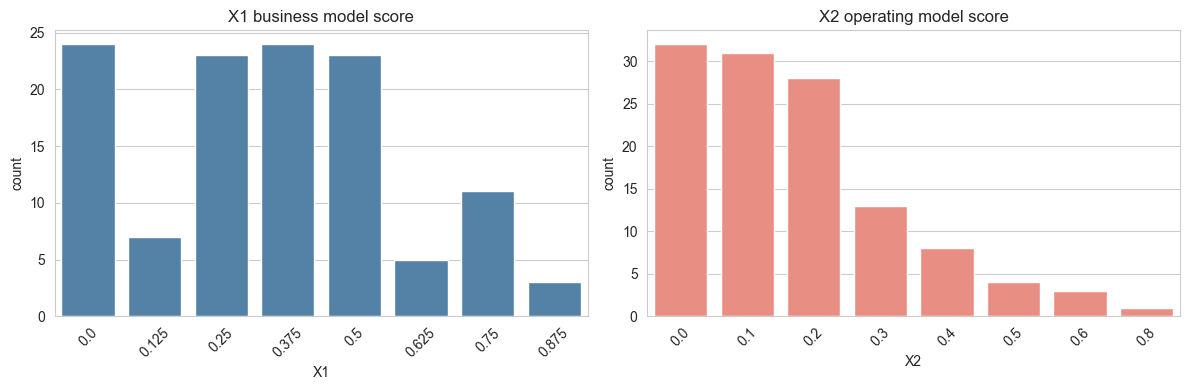

,X1,X2
count,120.000,120.000
mean,0.343,0.170
std,0.243,0.162
min,0.000,0.000
25%,0.125,0.000
50%,0.375,0.100
75%,0.500,0.200
max,0.875,0.800


In [23]:
#showing the frequency distribution of X1 and X2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(
    data=df,
    x="X1",
    order=sorted(df["X1"].unique()),
    color="steelblue",
    ax=axes[0]
)
axes[0].set_title("X1 business model score")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(
    data=df,
    x="X2",
    order=sorted(df["X2"].unique()),
    color="salmon",
    ax=axes[1]
)
axes[1].set_title("X2 operating model score")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

df[["X1", "X2"]].describe().round(3)

## 6.2 Adoption Over Time

Compares the annual mean X1 and X2 scores from 2022 to 2025.


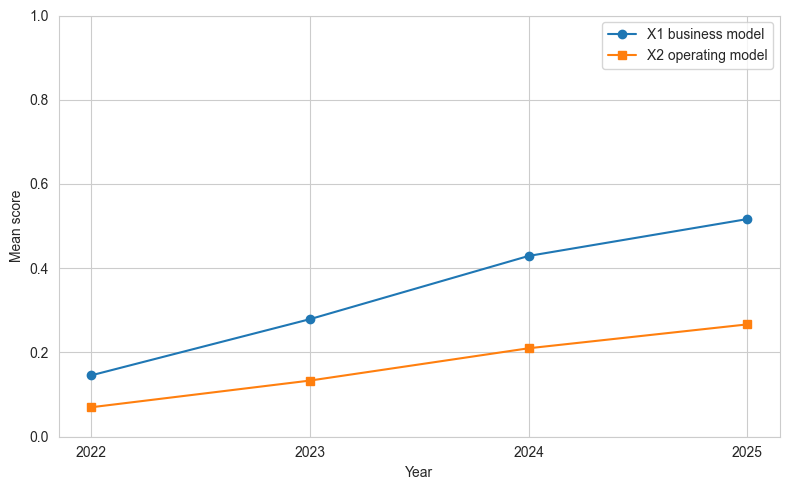

,X1,X2
Year,,
2022,0.146,0.070
2023,0.279,0.133
2024,0.429,0.210
2025,0.517,0.267


In [100]:
# Calculating average adoption scores by year
yearly = df.groupby("Year")[["X1", "X2"]].mean()

plt.figure(figsize=(8, 5))
plt.plot(yearly.index, yearly["X1"], marker="o", label="X1 business model")
plt.plot(yearly.index, yearly["X2"], marker="s", label="X2 operating model")

plt.xticks(ANALYSIS_YEARS)
plt.xlabel("Year")
plt.ylabel("Mean score")

plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(
    "x1_x2_annual_means.pdf",
    bbox_inches="tight"
)

plt.show()

yearly.round(3)

## 6.3 Adoption by Tier

Compares average adoption trends across the predefined insurer size tiers.


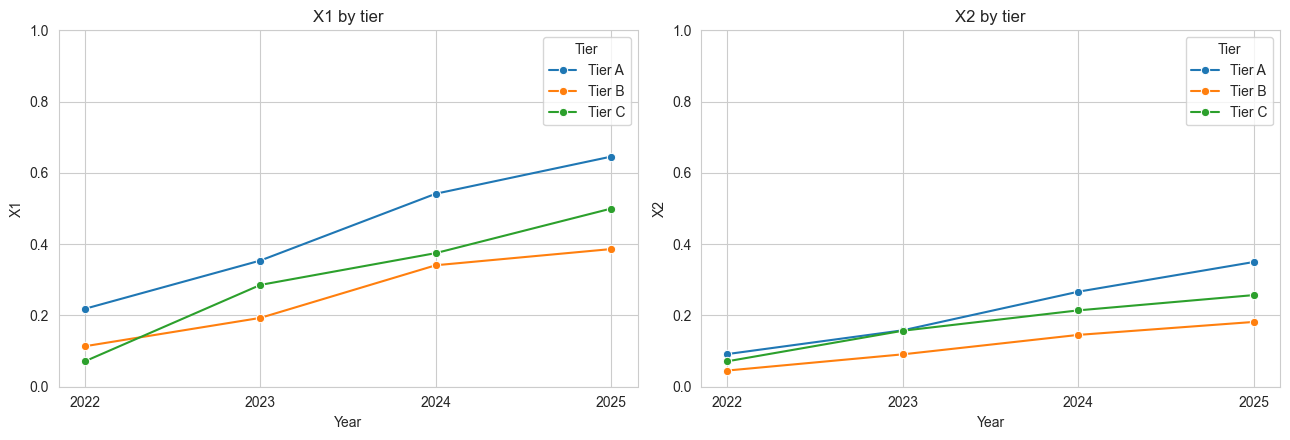

,Tier,Year,X1,X2
0,Tier A,2022,0.219,0.092
1,Tier A,2023,0.354,0.158
2,Tier A,2024,0.542,0.267
3,Tier A,2025,0.646,0.350
4,Tier B,2022,0.114,0.045
5,Tier B,2023,0.193,0.091
6,Tier B,2024,0.341,0.145
7,Tier B,2025,0.386,0.182
8,Tier C,2022,0.071,0.071
9,Tier C,2023,0.286,0.157


In [25]:
# Calculating average adoption scores by tier and year
tier_yearly = (
    df.groupby(["Tier", "Year"], as_index=False)[["X1", "X2"]]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, variable in zip(axes, ["X1", "X2"]):
    sns.lineplot(
        data=tier_yearly,
        x="Year",
        y=variable,
        hue="Tier",
        marker="o",
        errorbar=None,
        ax=ax
    )

    ax.set_xticks(ANALYSIS_YEARS)
    ax.set_ylim(0, 1)
    ax.set_title(f"{variable} by tier")

plt.tight_layout()
plt.show()

tier_yearly.round(3)

## 6.4 Adoption Profile by Company

Compares each insurer’s X1 and X2 scores in 2025, the latest year in the panel.


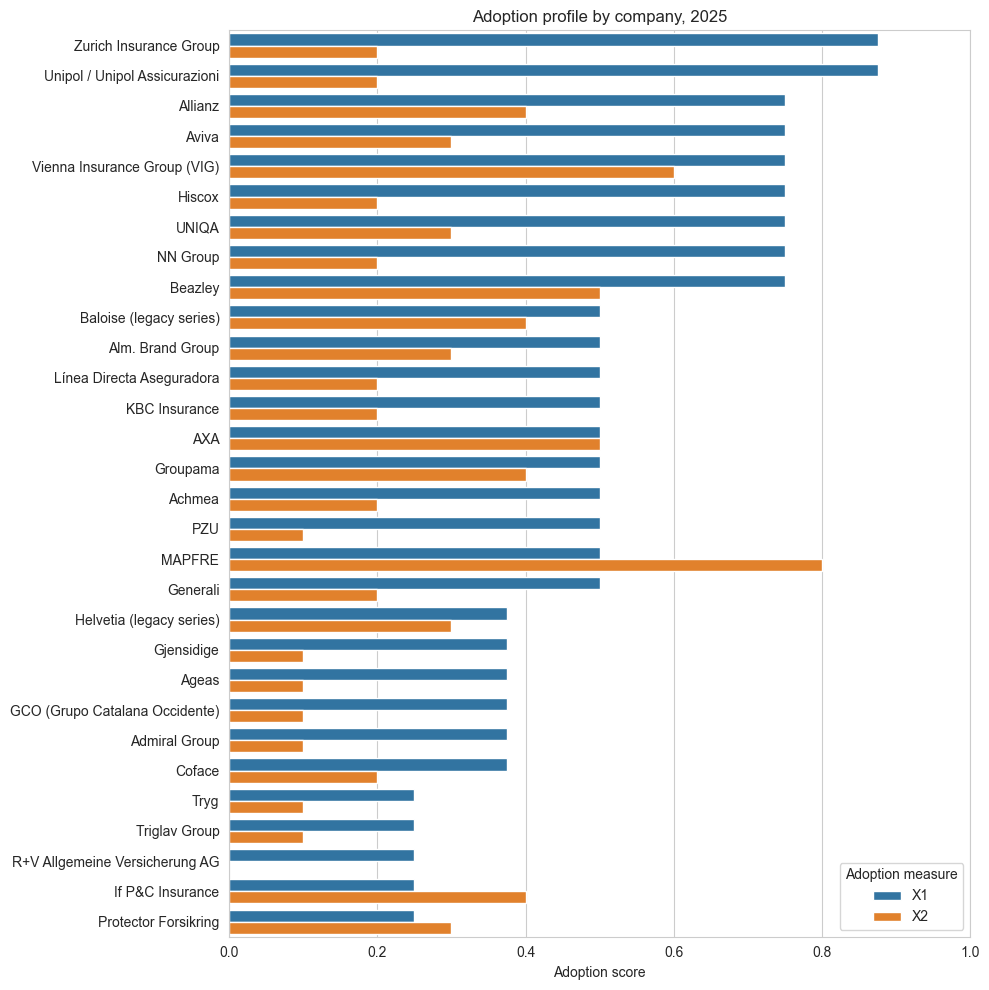

In [26]:
# selecting company adoption scores for 2025
latest = (
    df[df["Year"] == 2025]
    .sort_values("X1", ascending=False)
)

latest_long = latest.melt(
    id_vars="Company",
    value_vars=["X1", "X2"],
    var_name="Adoption measure",
    value_name="Score"
)

#comparing X1 and X2 across companies
plt.figure(figsize=(10, 10))

sns.barplot(
    data=latest_long,
    y="Company",
    x="Score",
    hue="Adoption measure",
    order=latest["Company"]
)

plt.xlim(0, 1)
plt.xlabel("Adoption score")
plt.ylabel("")
plt.title("Adoption profile by company, 2025")
plt.tight_layout()
plt.show()

## 6.5 Detailed AI Component Analysis

This section examines the four business-model dimensions underlying X1 and the five operating-model stages underlying X2. Annual mean scores are compared to show how the individual components changed between 2022 and 2025.


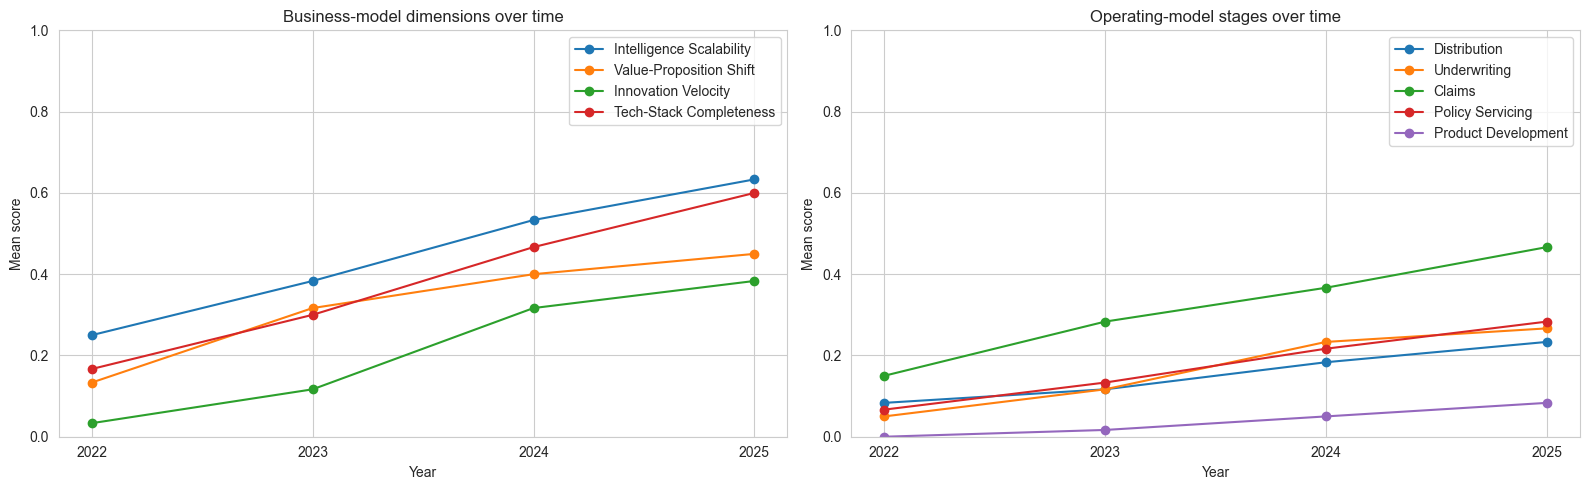

In [27]:
# Calculating average component scores by year
business_dimension_by_year = (
    df.groupby("Year")[business_dimensions]
    .mean()
)

operating_stage_by_year = (
    df.groupby("Year")[operating_stages]
    .mean()
)

# Plotting changes in the underlying AI components
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for dimension in business_dimensions:
    axes[0].plot(
        business_dimension_by_year.index,
        business_dimension_by_year[dimension],
        marker="o",
        label=dimension
    )

for stage in operating_stages:
    axes[1].plot(
        operating_stage_by_year.index,
        operating_stage_by_year[stage],
        marker="o",
        label=stage
    )

axes[0].set_title("Business-model dimensions over time")
axes[1].set_title("Operating-model stages over time")

for ax in axes:
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean score")
    ax.set_xticks(ANALYSIS_YEARS)
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

## 6.6 Distribution of the Financial Outcomes

Examines the distributions of the six financial outcomes used in the analysis.


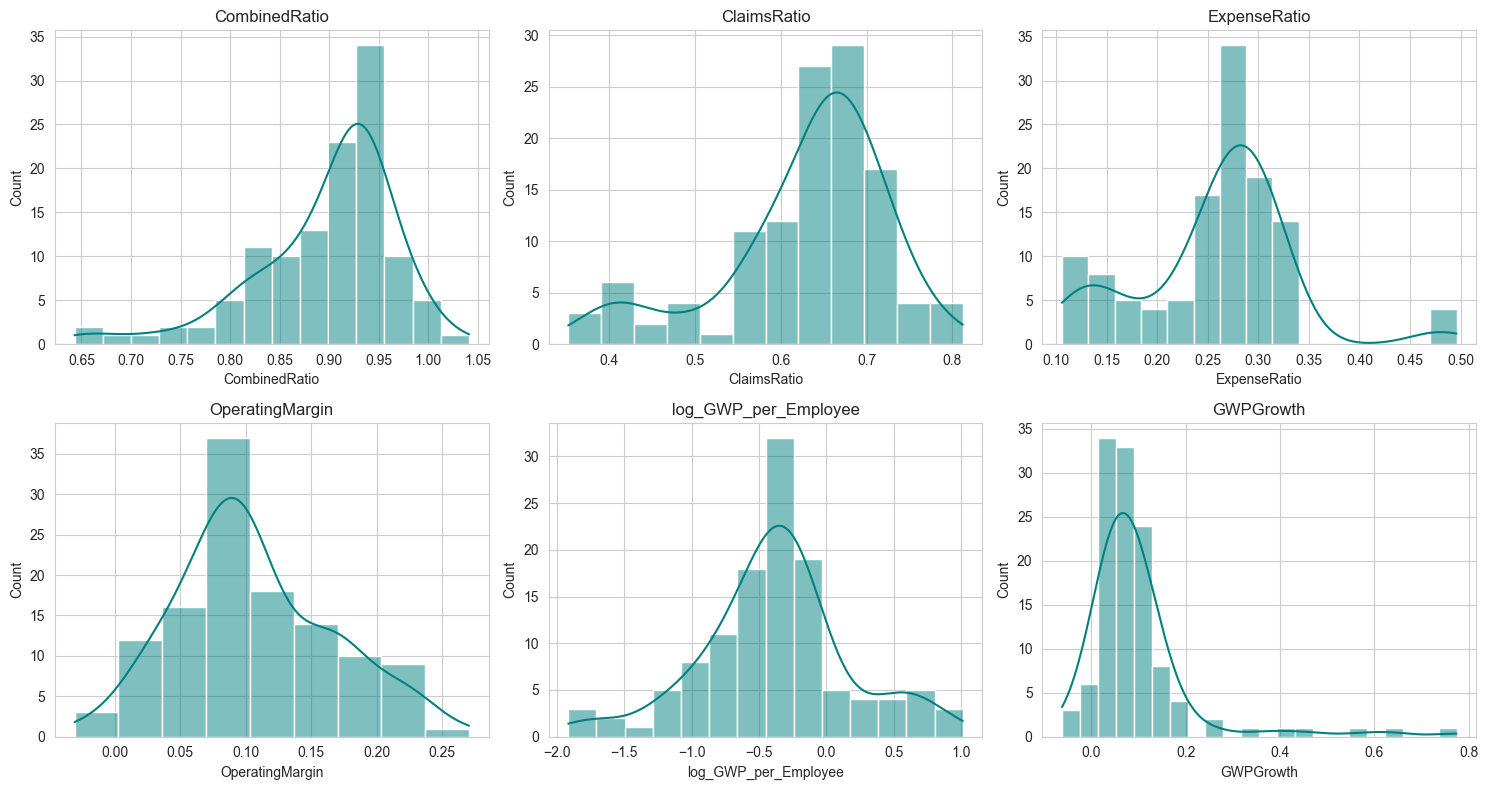

,count,mean,std,min,25%,50%,75%,max
CombinedRatio,120.0,0.898,0.071,0.643,0.866,0.922,0.940,1.041
ClaimsRatio,120.0,0.630,0.095,0.352,0.592,0.655,0.692,0.812
ExpenseRatio,120.0,0.258,0.075,0.106,0.233,0.275,0.299,0.496
OperatingMargin,120.0,0.106,0.060,-0.031,0.069,0.096,0.152,0.270
log_GWP_per_Employee,120.0,-0.381,0.556,-1.915,-0.654,-0.363,-0.132,1.014
GWPGrowth,120.0,0.098,0.119,-0.062,0.042,0.072,0.114,0.774


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, variable in zip(axes.flatten(), outcomes):
    sns.histplot(df[variable].dropna(), kde=True, ax=ax, color="teal")
    ax.set_title(variable)
plt.tight_layout()
plt.show()
plt.close("all")

df[outcomes].describe().T.round(3)

## 6.7 Financial Outcomes by Year

Compares annual means and medians to show how the financial outcomes changed between 2022 and 2025. Lower combined, claims and expense ratios indicate better underwriting performance, while higher operating margin, productivity and GWP growth indicate better performance.


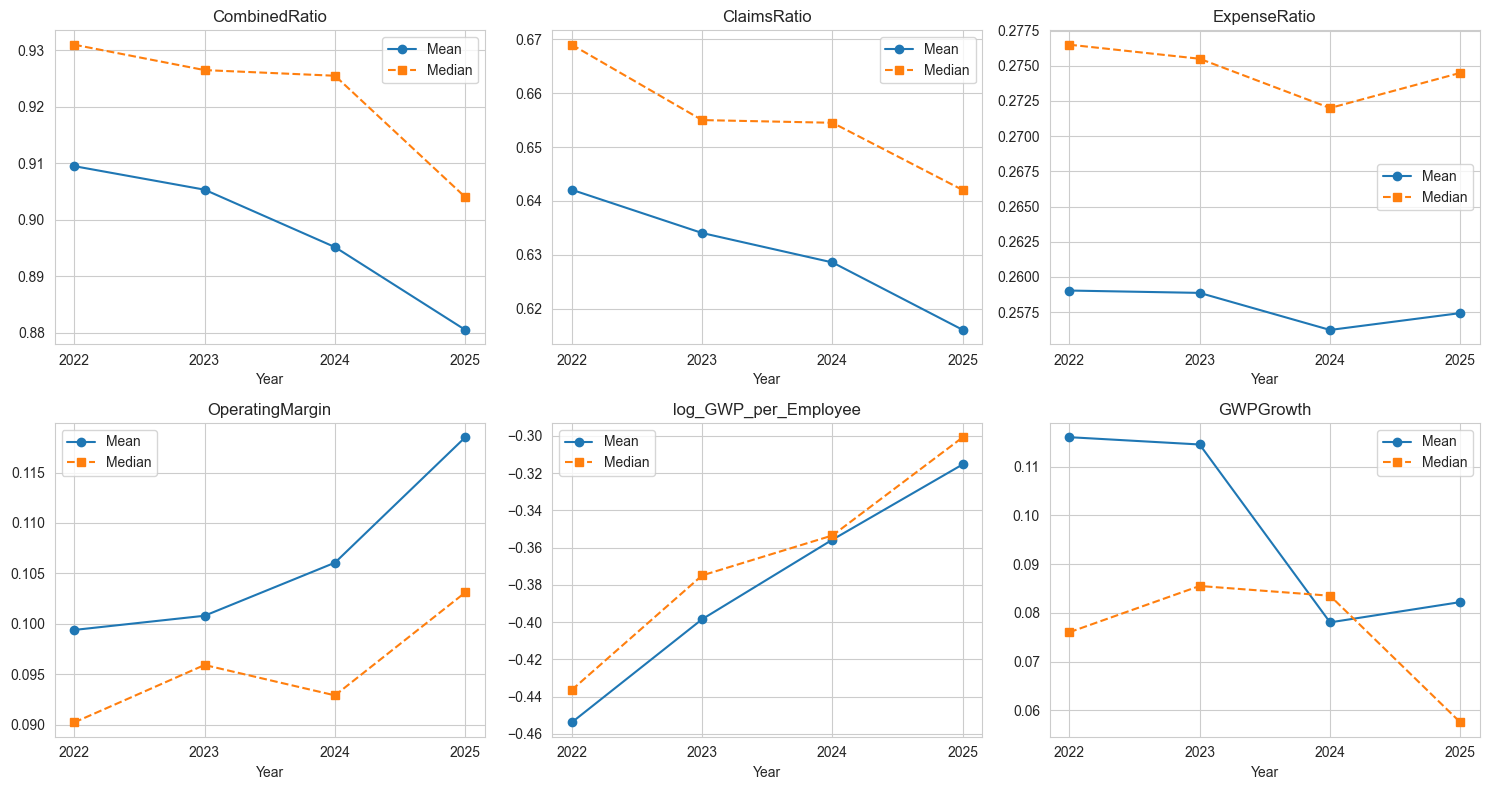

In [29]:
# Calculating annual means and medians
yearly_outcomes = (
    df.groupby("Year")[outcomes]
    .agg(["mean", "median"])
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, variable in zip(axes.flatten(), outcomes):
    ax.plot(
        yearly_outcomes.index,
        yearly_outcomes[(variable, "mean")],
        marker="o",
        label="Mean"
    )

    ax.plot(
        yearly_outcomes.index,
        yearly_outcomes[(variable, "median")],
        marker="s",
        linestyle="--",
        label="Median"
    )

    ax.set_xticks(ANALYSIS_YEARS)
    ax.set_title(variable)
    ax.set_xlabel("Year")
    ax.legend()

plt.tight_layout()
plt.show()

## 6.8 Adoption Against the Financial Outcomes

Displays the unadjusted relationships between the adoption scores and financial outcomes. Each company appears in multiple years, and these charts do not control for year, company size or previous financial performance. The fitted lines are therefore descriptive and should not be interpreted as regression results.


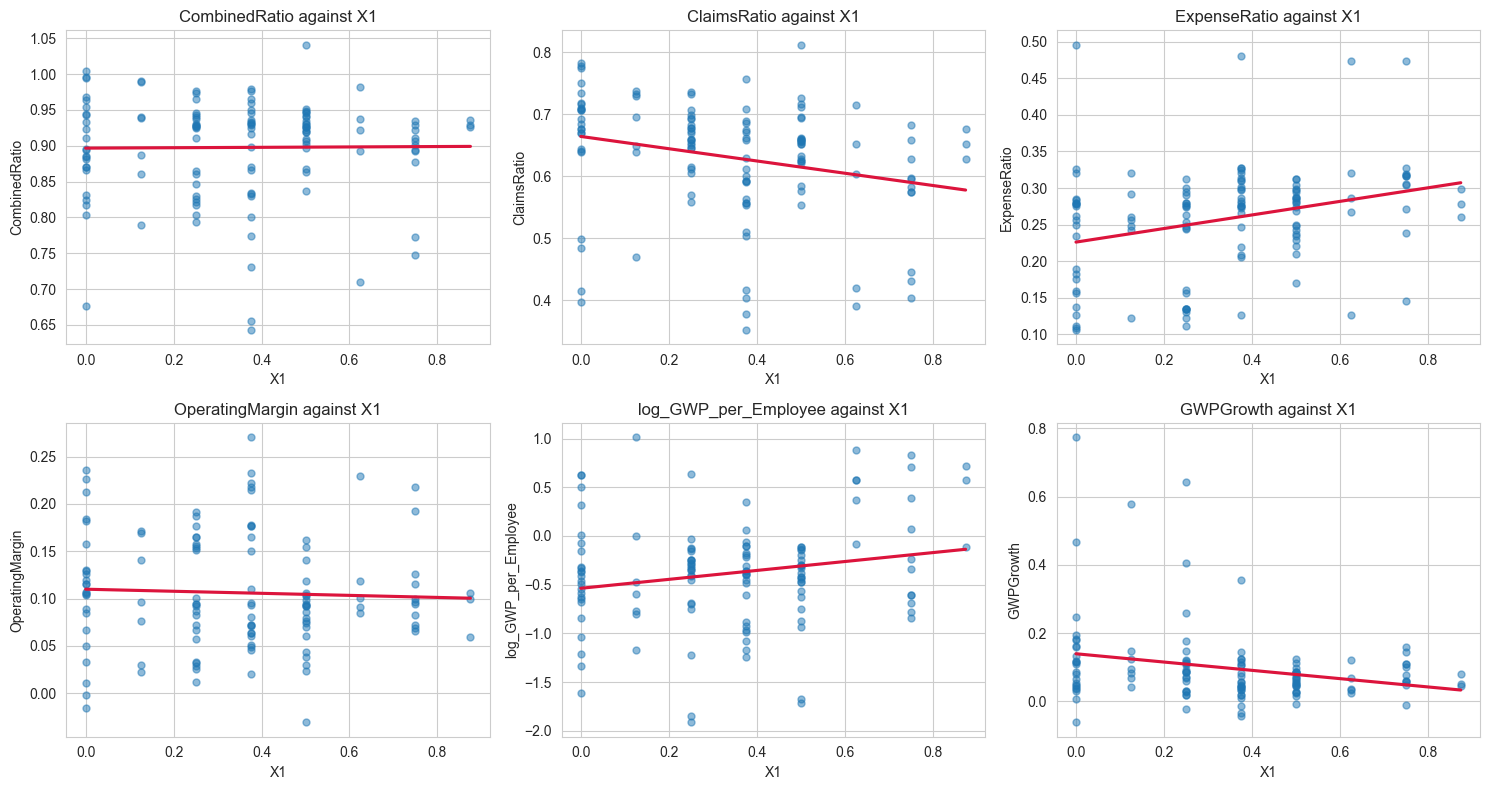

In [30]:
#Plotting raw relationships between X1 and the financial outcomes
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, variable in zip(axes.flatten(), outcomes):
    sns.regplot(
        data=df,
        x="X1",
        y=variable,
        ci=None,
        scatter_kws={"alpha": 0.5, "s": 25},
        line_kws={"color": "crimson"},
        ax=ax
    )

    ax.set_title(f"{variable} against X1")

plt.tight_layout()
plt.show()

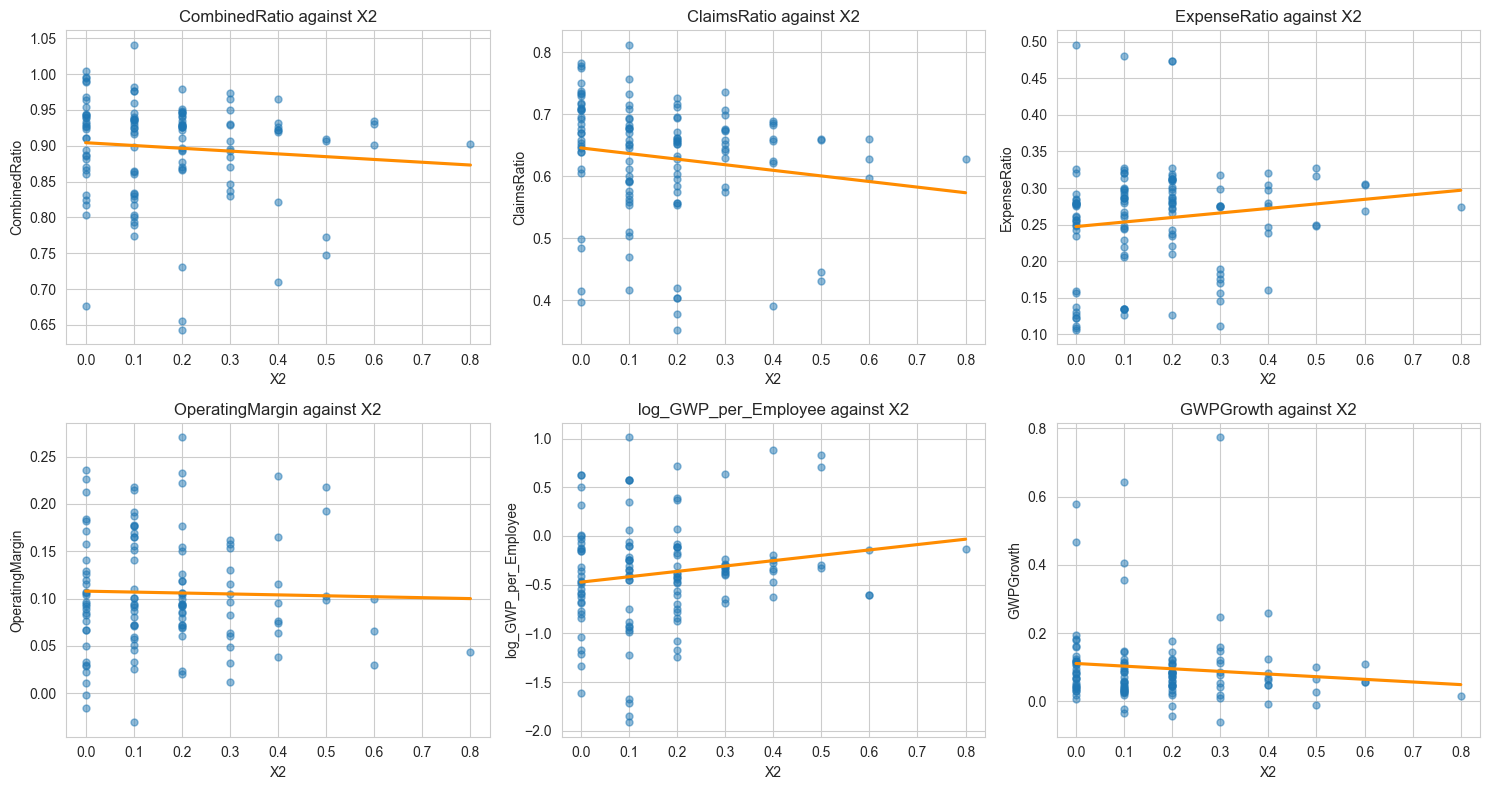

In [31]:
# Plotting raw relationships between X2 and the financial outcomes
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, variable in zip(axes.flatten(), outcomes):
    sns.regplot(
        data=df,
        x="X2",
        y=variable,
        ci=None,
        scatter_kws={"alpha": 0.5, "s": 25},
        line_kws={"color": "darkorange"},
        ax=ax
    )

    ax.set_title(f"{variable} against X2")

plt.tight_layout()
plt.show()

## 6.9 Adoption Scores and Company Size

Examines the relationship between company size and AI adoption separately for each year. Year-specific correlations show whether larger insurers consistently recorded higher X1 and X2 scores throughout the study period.


In [32]:
# Calculating size-adoption correlations separately for each year
size_correlation_rows = []

for year in ANALYSIS_YEARS:
    yearly_data = df[df["Year"] == year]

    size_correlation_rows.append({
        "Year": year,
        "X1 correlation with log GWP": yearly_data["X1"].corr(
            yearly_data["log_GWP"]
        ),
        "X2 correlation with log GWP": yearly_data["X2"].corr(
            yearly_data["log_GWP"]
        )
    })

size_correlations_by_year = pd.DataFrame(size_correlation_rows)

size_correlations_by_year.round(3)

,Year,X1 correlation with log GWP,X2 correlation with log GWP
0,2022,0.170,0.101
1,2023,0.251,0.294
2,2024,0.421,0.387
3,2025,0.414,0.391


# 7. Correlation Analysis

Correlation analysis examines how the adoption scores, financial outcomes and company size move together before regression modelling. Correlations range from −1 to +1 and describe association rather than causation.


## 7.1 Correlation Heatmap

Provides an overall view of the linear relationships among the adoption scores, financial outcomes and main company-size control.


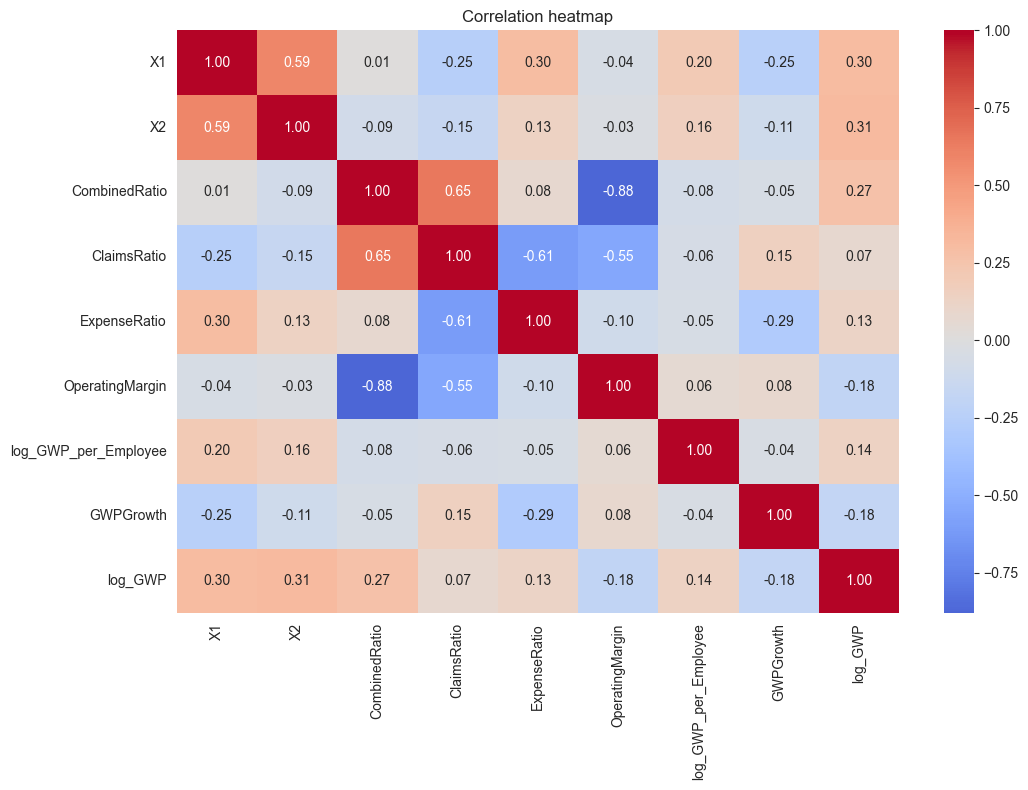

In [33]:
# calculating correlations among the main analysis variables
correlation_variables = (
    ["X1", "X2"]
    + outcomes
    + ["log_GWP"]
)

correlation_matrix = df[correlation_variables].corr()

# Displaying the correlation matrix
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

## 7.2 Correlations Between Adoption and Performance

Compares Pearson and Spearman correlations between X1 or X2 and each financial outcome. Pearson measures linear relationships, while Spearman measures whether variables generally move in the same or opposite direction based on their rankings. The results are descriptive because companies appear repeatedly across years.


In [34]:
# Calculating Pearson and Spearman correlations
def correlation_table(data, predictors, outcome_list):
    results = []

    for predictor in predictors:
        for outcome in outcome_list:
            subset = data[[predictor, outcome]].dropna()

            results.append({
                "Adoption score": predictor,
                "Financial outcome": outcome,
                "Pearson correlation": subset[predictor].corr(
                    subset[outcome],
                    method="pearson"
                ),
                "Spearman correlation": subset[predictor].corr(
                    subset[outcome],
                    method="spearman"
                )
            })

    return pd.DataFrame(results)


pooled_correlations = correlation_table(
    df,
    ["X1", "X2"],
    outcomes
)

pooled_correlations.round(3)

,Adoption score,Financial outcome,Pearson correlation,Spearman correlation
0,X1,CombinedRatio,0.009,-0.002
1,X1,ClaimsRatio,-0.252,-0.329
2,X1,ExpenseRatio,0.300,0.324
3,X1,OperatingMargin,-0.044,-0.072
4,X1,log_GWP_per_Employee,0.200,0.172
5,X1,GWPGrowth,-0.248,-0.238
6,X2,CombinedRatio,-0.089,-0.116
7,X2,ClaimsRatio,-0.154,-0.230
8,X2,ExpenseRatio,0.134,0.177
9,X2,OperatingMargin,-0.027,-0.016


# 8. One-Year-Lagged Panel

This section matches adoption scores, company size and financial performance from the previous year with financial outcomes in the following year. This allows the analysis to examine whether adoption in year \(t-1\) is associated with performance in year \(t\).

Because 2022 has no previous-year observation, the lagged panel covers outcome years 2023–2025. It contains 90 company-year observations across 30 insurers.


In [35]:
# Sorting observations before creating within-company lags
panel = df.sort_values(["Company", "Year"]).copy()

# Creating one-year lags for the adoption scores
for variable in ["X1", "X2"]:
    panel[f"{variable}_lag1"] = (
        panel.groupby("Company")[variable].shift(1)
    )

# Creating lags for the size measures used later
for variable in ["log_GWP", "log_Assets"]:
    panel[f"{variable}_lag1"] = (
        panel.groupby("Company")[variable].shift(1)
    )

# Creating previous-year values for all financial outcomes
for outcome in outcomes:
    panel[f"{outcome}_lag1"] = (
        panel.groupby("Company")[outcome].shift(1)
    )

# Aligning the zero-score indicator with the predictor year
panel["Zero Both Lagged"] = (
    panel.groupby("Company")["Zero Both Scores"].shift(1)
)

# Keeping observations with the main lagged predictors available
lagged = panel.dropna(
    subset=["X1_lag1", "X2_lag1", "log_GWP_lag1"]
).copy()

# Displaying the structure of the lagged panel
print("Lagged sample shape:", lagged.shape)
print("Outcome years:", sorted(lagged["Year"].unique()))
print("Companies:", lagged["Company"].nunique())

lagged[
    [
        "Company",
        "Year",
        "X1",
        "X1_lag1",
        "X2",
        "X2_lag1",
        "CombinedRatio",
        "CombinedRatio_lag1",
    ]
].head(9).round(3)

Lagged sample shape: (90, 62)
Outcome years: [np.int64(2023), np.int64(2024), np.int64(2025)]
Companies: 30


,Company,Year,X1,X1_lag1,X2,X2_lag1,CombinedRatio,CombinedRatio_lag1
5,AXA,2023,0.375,0.250,0.4,0.1,0.932,0.976
6,AXA,2024,0.500,0.375,0.5,0.4,0.910,0.932
7,AXA,2025,0.500,0.500,0.5,0.5,0.906,0.910
53,Achmea,2023,0.125,0.000,0.0,0.0,0.939,0.944
54,Achmea,2024,0.500,0.125,0.2,0.0,0.948,0.939
55,Achmea,2025,0.500,0.500,0.2,0.2,0.930,0.948
93,Admiral Group,2023,0.125,0.000,0.0,0.0,0.887,0.968
94,Admiral Group,2024,0.375,0.125,0.1,0.0,0.774,0.887
95,Admiral Group,2025,0.375,0.375,0.1,0.1,0.801,0.774


## 8.1 Outcome Persistence

This section measures how closely each financial outcome is related to its previous-year value. Strong persistence supports including prior-year performance as a control in the main regression specification.


In [36]:
# Calculating each outcome's correlation with its previous-year value
persistence = pd.DataFrame({
    "Outcome": outcomes,
    "Correlation with own lag": [
        round(lagged[[o, o + "_lag1"]].dropna().corr().iloc[0, 1], 3)
        for o in outcomes
    ],
})
persistence

,Outcome,Correlation with own lag
0,CombinedRatio,0.905
1,ClaimsRatio,0.951
2,ExpenseRatio,0.991
3,OperatingMargin,0.901
4,log_GWP_per_Employee,0.987
5,GWPGrowth,0.299


## 8.2 Final Modelling Sample

This section confirms the size of the lagged panel and checks whether the variables required by the main regression specifications contain missing values.


In [37]:
# Defining the fields required by the main regression specifications
main_model_columns = [
    "Company",
    "Year",
    "X1_lag1",
    "X2_lag1",
    "log_GWP_lag1",
] + outcomes + [f"{outcome}_lag1" for outcome in outcomes]

# checking missing values in the modelling fields
main_model_missing = lagged[main_model_columns].isna().sum()
missing_fields = main_model_missing[main_model_missing > 0]

# Displaying the final sample structure
print("FULL PANEL")
print("  observations :", len(df))
print("  companies    :", df["Company"].nunique())
print("  years        :", sorted(df["Year"].unique()))

print("\nLAGGED PANEL")
print("  observations :", len(lagged))
print("  companies    :", lagged["Company"].nunique())
print("  outcome years:", sorted(lagged["Year"].unique()))

print("\nMissing values in the main modelling fields:")
print("None" if missing_fields.empty else missing_fields.to_string())

FULL PANEL
  observations : 120
  companies    : 30
  years        : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

LAGGED PANEL
  observations : 90
  companies    : 30
  outcome years: [np.int64(2023), np.int64(2024), np.int64(2025)]

Missing values in the main modelling fields:
None


In [38]:
#recheking the lagged panel structure
lagged.head()

,Company,Year,Tier,Main Market,Reporting Currency,X1 Business Model,X2 Operating Model,P&C GWP (million),P&C Insurance Revenue (million),P&C Operating Result (million),Combined Ratio,Claims / Loss Ratio,Expense Ratio,P&C Employee Count,P&C GWP per Employee (million),P&C GWP Growth,Group Total Assets (million),Group Equity (million),Intelligence Scalability,Value-Proposition Shift,Innovation Velocity,Tech-Stack Completeness,Distribution,Underwriting,Claims,Policy Servicing,Product Development,Average Exchange Rate,Year-End Exchange Rate,P&C GWP EUR (million),P&C Insurance Revenue EUR (million),P&C Operating Result EUR (million),Group Total Assets EUR (million),Group Equity EUR (million),GWP per Employee EUR (million),log_GWP,log_Revenue,log_Assets,log_Equity,log_Employees,log_GWP_per_Employee,Operating Margin,Region,Zero Both Scores,X1,X2,CombinedRatio,ClaimsRatio,ExpenseRatio,OperatingMargin,GWPGrowth,X1_lag1,X2_lag1,log_GWP_lag1,log_Assets_lag1,CombinedRatio_lag1,ClaimsRatio_lag1,ExpenseRatio_lag1,OperatingMargin_lag1,log_GWP_per_Employee_lag1,GWPGrowth_lag1,Zero Both Lagged
5,AXA,2023,Tier A,France / Paris,EUR,0.375,0.4,53027.0,52326.0,5012.0,0.932,0.685,0.247,75866.7,0.699,0.047,644000.0,49579.0,0.5,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.0,1.0,1.0,53027.0,52326.0,5012.0,644000.0,49579.0,0.698950,10.878556,10.865249,13.375454,10.811323,11.236733,-0.358177,0.095784,France,False,0.375,0.4,0.932,0.685,0.247,0.095784,0.047,0.250,0.1,10.832359,13.454541,0.976,0.732,0.244,0.057699,-0.353166,0.026,False
6,AXA,2024,Tier A,France / Paris,EUR,0.500,0.5,56514.0,55898.0,5510.0,0.910,0.660,0.250,78894.2,0.716,0.066,653760.0,49943.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,1.0,1.0,56514.0,55898.0,5510.0,653760.0,49943.0,0.716326,10.942244,10.931284,13.390496,10.818638,11.275863,-0.333619,0.098572,France,False,0.500,0.5,0.910,0.660,0.250,0.098572,0.066,0.375,0.4,10.878556,13.375454,0.932,0.685,0.247,0.095784,-0.358177,0.047,False
7,AXA,2025,Tier A,France / Paris,EUR,0.500,0.5,58038.0,57390.0,5872.0,0.906,0.658,0.248,78374.4,0.741,0.027,NaN,47200.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,1.0,1.0,58038.0,57390.0,5872.0,NaN,47200.0,0.740522,10.968853,10.957625,NaN,10.762149,11.269253,-0.300399,0.102317,France,False,0.500,0.5,0.906,0.658,0.248,0.102317,0.027,0.500,0.5,10.942244,13.390496,0.910,0.660,0.250,0.098572,-0.333619,0.066,False
53,Achmea,2023,Tier B,Netherlands / Zeist,EUR,0.125,0.0,4044.0,4034.0,309.0,0.939,0.696,0.243,7305.4,0.554,0.042,77718.0,8980.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,4044.0,4034.0,309.0,77718.0,8980.0,0.553563,8.304990,8.302514,11.260842,9.102755,8.896369,-0.591379,0.076599,Benelux,False,0.125,0.0,0.939,0.696,0.243,0.076599,0.042,0.000,0.0,8.263848,11.248113,0.944,0.710,0.234,0.066770,-0.628598,0.031,True
54,Achmea,2024,Tier B,Netherlands / Zeist,EUR,0.500,0.2,4397.0,4321.0,301.0,0.948,0.711,0.237,7046.4,0.624,0.087,82216.0,9415.0,0.5,0.5,0.5,0.5,0.5,0.0,0.5,0.0,0.0,1.0,1.0,4397.0,4321.0,301.0,82216.0,9415.0,0.624007,8.388678,8.371242,11.317105,9.150059,8.860272,-0.471594,0.069660,Benelux,False,0.500,0.2,0.948,0.711,0.237,0.069660,0.087,0.125,0.0,8.304990,11.260842,0.939,0.696,0.243,0.076599,-0.591379,0.042,False


# Part 2: Modelling Analysis

This part examines whether previous-year AI adoption is associated with subsequent financial performance. OLS provides the main interpretable association estimates, while Ridge, Lasso and Random Forest provide complementary evidence on predictive performance, coefficient stability, feature selection and possible non-linear relationships.


# 9. Modelling Framework and Model Preparation

This section defines the research model, predictor specifications and company-grouped data split used in the modelling analysis. It also prepares a separate predictor matrix for each financial outcome.

All models use the one-year-lagged panel created in Section 8, linking adoption and company characteristics in year \(t-1\) with financial performance in year \(t\).


## 9.1 Research Question and Roles of the Models

The modelling analysis examines whether business-model adoption (\(X1\)) and operating-model adoption (\(X2\)) are associated with subsequent P&C financial performance after accounting for company size, year effects and, in the main specification, previous financial performance.

The modelling methods serve complementary purposes:

- OLS provides the main estimates of association, including coefficients, confidence intervals and company-clustered standard errors.
- Ridge examines coefficient stability when predictors contain overlapping information.
- Lasso examines whether individual predictors retain predictive information after regularisation.
- Random Forest checks for possible non-linear relationships and interactions.

The methods are therefore compared as complementary analyses rather than as interchangeable versions of one model.


## 9.2 Model Specifications

Two predictor specifications are examined for every financial outcome.

### Comparison Specification: Without Previous Performance

$$
Y_{i,t} 
=
\beta_0
+\beta_1X1_{i,t-1}
+\beta_2X2_{i,t-1}
+\beta_3\log(GWP_{i,t-1})
+\lambda_t
+\varepsilon_{i,t}
$$

This specification includes lagged adoption, lagged company size and outcome-year effects. It is used to show how the estimated adoption relationships change when previous financial performance is not controlled for.

### Main Specification: Controlling for Previous Performance

$$
Y_{i,t} 
=
\beta_0
+\beta_1X1_{i,t-1}
+\beta_2X2_{i,t-1}
+\beta_3Y_{i,t-1}
+\beta_4\log(GWP_{i,t-1})
+\lambda_t
+\varepsilon_{i,t}
$$

This is the main specification because it additionally controls for the dependent variable's own previous-year value. This accounts for persistent differences in financial performance between insurers.

For example, when the dependent variable is the expense ratio, \(Y_{i,t-1}\) represents the insurer's previous-year expense ratio. Other financial outcomes are not automatically included as controls.


## 9.3 Company-Grouped Development Split

A fixed company-level split is used for initial model development and hyperparameter tuning. All observations from the same insurer are assigned to either the training or test sample, preventing information from one insurer from appearing in both samples.

The fixed split is used for Ridge, Lasso and Random Forest. The final OLS association models are estimated using all 90 lagged observations because their main purpose is coefficient interpretation and statistical inference. Predictive performance is assessed separately using leave-one-carrier-out validation.


In [39]:
# Creating a reproducible company-level development split
companies = np.array(sorted(lagged["Company"].unique()))

company_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=RANDOM_STATE
)

train_company_index, test_company_index = next(
    company_split.split(
        np.zeros((len(companies), 1)),
        groups=companies
    )
)

# Identifying the companies assigned to each sample
train_companies = set(companies[train_company_index])
test_companies = set(companies[test_company_index])

# Confirming that no company appears in both samples
assert train_companies.isdisjoint(test_companies)
assert train_companies | test_companies == set(companies)

print("Training companies:", len(train_companies))
print("Test companies:", len(test_companies))

print("\nHeld-out test companies:")
for company in sorted(test_companies):
    print("-", company)

Training companies: 21
Test companies: 9

Held-out test companies:
- Beazley
- Coface
- Gjensidige
- Hiscox
- KBC Insurance
- R+V Allgemeine Versicherung AG
- Triglav Group
- Unipol / Unipol Assicurazioni
- Vienna Insurance Group (VIG)


## 9.4 Preparing the Predictor Matrices

The following function prepares the modelling data separately for each financial outcome and specification. It selects the required variables, removes incomplete observations and creates outcome-year indicators.

The earliest outcome year, 2023, is used as the reference year. The function also returns the company labels and training and test masks required by the later modelling sections.


In [40]:
# Defining readable labels for the financial outcomes
outcome_labels = {
    "CombinedRatio": "Combined ratio",
    "ClaimsRatio": "Claims ratio",
    "ExpenseRatio": "Expense ratio",
    "OperatingMargin": "Operating margin",
    "log_GWP_per_Employee": "Log GWP per employee",
    "GWPGrowth": "GWP growth"
}

outcomes = list(outcome_labels.keys())

# Matching each outcome with its actual lagged column
outcome_lag_columns = {
    "CombinedRatio": "CombinedRatio_lag1",
    "ClaimsRatio": "ClaimsRatio_lag1",
    "ExpenseRatio": "ExpenseRatio_lag1",
    "OperatingMargin": "OperatingMargin_lag1",
    "log_GWP_per_Employee": "log_GWP_per_Employee_lag1",
    "GWPGrowth": "GWPGrowth_lag1"
}

# Defining the two predictor specifications
WITHOUT_PREVIOUS_PERFORMANCE = "Without previous performance"
MAIN_SPECIFICATION = "Main specification"

specifications = [
    WITHOUT_PREVIOUS_PERFORMANCE,
    MAIN_SPECIFICATION
]

# Defining the outcome years represented in the lagged panel
model_years = sorted(lagged["Year"].unique())
reference_year = model_years[0]

print("Model outcome years:", model_years)
print("Reference year:", reference_year)

Model outcome years: [np.int64(2023), np.int64(2024), np.int64(2025)]
Reference year: 2023


In [41]:
def prepare_model_data(data, outcome, specification):
    """
    Prepare the predictors, outcome, company groups and development-split
    masks for one financial outcome and one model specification.
    """

    # Checking that valid names were supplied
    if outcome not in outcomes:
        raise ValueError(f"Unknown outcome: {outcome}")

    if specification not in specifications:
        raise ValueError(f"Unknown specification: {specification}")

    # Predictors included in both specifications
    predictors = [
        "X1_lag1",
        "X2_lag1",
        "log_GWP_lag1"
    ]

    # Adding the outcome's own lag to the main specification
    if specification == MAIN_SPECIFICATION:
        predictors = predictors + [outcome_lag_columns[outcome]]

    # Keeping complete observations for the selected model
    required_columns = [
        "Company",
        "Year",
        outcome
    ] + predictors

    model_data = (
        data[required_columns]
        .dropna()
        .copy()
        .reset_index(drop=True)
    )

    # Creating year indicators with 2023 as the reference year
    year_dummies = pd.get_dummies(
        pd.Categorical(
            model_data["Year"],
            categories=model_years
        ),
        prefix="Year",
        dtype=float
    ).drop(columns=[f"Year_{reference_year}"])

    # Constructing the predictor matrix
    X = pd.concat(
        [
            model_data[predictors],
            year_dummies
        ],
        axis=1
    ).astype(float)

    # Defining the dependent variable and company groups
    y = model_data[outcome].astype(float)
    groups = model_data["Company"]

    # Applying the company-level development split
    train_mask = groups.isin(train_companies).to_numpy()
    test_mask = groups.isin(test_companies).to_numpy()

    # Return order: data, predictors, outcome, groups, train mask, test mask
    return model_data, X, y, groups, train_mask, test_mask

## 9.5 Verifying the Prepared Data

The combined-ratio main specification is used as an example to verify the dimensions of the predictor matrix, the allocation of observations and the variables supplied to the later models.


In [42]:
# Preparing an example using the combined-ratio main specification
(
    example_data,
    example_X,
    example_y,
    example_groups,
    example_train,
    example_test
) = prepare_model_data(
    lagged,
    outcome="CombinedRatio",
    specification=MAIN_SPECIFICATION
)

print("Example model matrix:", example_X.shape)
print("Training observations:", int(example_train.sum()))
print("Test observations:", int(example_test.sum()))
print("Predictors:", example_X.columns.tolist())

Example model matrix: (90, 6)
Training observations: 63
Test observations: 27
Predictors: ['X1_lag1', 'X2_lag1', 'log_GWP_lag1', 'CombinedRatio_lag1', 'Year_2024', 'Year_2025']


# 10. Regularised Linear Models

This section applies Ridge and Lasso regression to examine whether previous-year AI adoption contributes to predicting insurers’ subsequent financial performance.

Both models are estimated for six financial outcomes under two specifications:

1. Without previous performance: includes previous-year X1, X2, logged P&C GWP and year controls.
2. Main specification: additionally includes the previous-year value of the financial outcome being predicted.

Ridge and Lasso serve different purposes. Ridge stabilises correlated coefficients by shrinking them towards zero while retaining the predictors. Lasso can shrink weak predictors exactly to zero and therefore provides a limited form of feature selection.

The models are trained using the company-grouped development split created in Section 9. Hyperparameters are selected using five-fold GroupKFold cross-validation within the training companies. All predictors are standardised separately inside each cross-validation fold, preventing information from the validation observations from entering the scaling process.

The nine fixed test companies are used only to evaluate the selected models. These results are treated as development diagnostics because performance may depend on the particular companies included in the test group. Leave-one-carrier-out validation is presented later as the main internal-validation procedure.


In [43]:
# Creating candidate regularisation strengths from 0.0001 to 1000
alpha_grid = np.logspace(-4, 3, 12)


def fit_regularised_model(model_name, estimator, parameter_grid):
    """
    Fit one regularised model for every financial outcome and specification.

    Hyperparameters are selected using company-grouped cross-validation
    within the development training sample.
    """
 #creating empty lists for storing model results and coefficients
    performance_rows = []
    coefficient_rows = []

    for outcome in outcomes:  # LOOPING through each financial outcome
        for specification in specifications: # Testing each model specification for the current outcome

            (
                model_data,
                X,
                y,
                groups,
                train_mask,
                test_mask
            ) = prepare_model_data(
                lagged,
                outcome,
                specification
            )

               #building a pipeline to scale predictors before fitting the model
            pipeline = Pipeline([
                ("scale", StandardScaler()),
                ("model", estimator)
            ])

            # setting up grouped cross-validation for alpha selection
            #GroupKFold keeps observations from the same company together
            model_search = GridSearchCV(
                estimator=pipeline,
                param_grid=parameter_grid, # Selecting alpha by minimising validation RMSE
                scoring="neg_root_mean_squared_error",
                cv=GroupKFold(n_splits=5), # using five company-grouped validation folds
                n_jobs=1
            )

            model_search.fit(
                X[train_mask],
                y[train_mask],
                groups=groups[train_mask]
            )

            # evaluating the selected model on the fixed test companies
            prediction = model_search.predict(X[test_mask])
            best_parameters = model_search.best_params_

            performance_rows.append({
                "Outcome": outcome_labels[outcome],
                "Specification": specification,
                "Model": model_name,
                "Test R-squared": r2_score(
                    y[test_mask],
                    prediction
                ),
                "Test RMSE": mean_squared_error( # calculating test root mean squared error
                    y[test_mask],
                    prediction
                ) ** 0.5,
                "Test MAE": mean_absolute_error( # calculating test mean absolute error
                    y[test_mask],
                    prediction
                ),
                "Best alpha": best_parameters["model__alpha"]
            })

            # Extracting coefficients from the selected model
            coefficients = (
                model_search
                .best_estimator_
                .named_steps["model"]
                .coef_
            )

            for feature, coefficient in zip(
                X.columns,
                coefficients
            ):
                coefficient_rows.append({
                    "Outcome": outcome_labels[outcome],
                    "Specification": specification,
                    "Model": model_name,
                    "Feature": feature,
                    "Coefficient (standardised X)": coefficient
                })

    return (
        pd.DataFrame(performance_rows),
        pd.DataFrame(coefficient_rows)
    )

## 10.1 Ridge Regression

Ridge regression applies an L2 penalty that shrinks coefficients towards zero without normally removing predictors completely. It is useful when explanatory variables are correlated because it reduces coefficient instability while retaining all predictors.

The penalty parameter $\alpha$ controls the strength of regularisation. It is selected separately for every financial outcome and specification using five-fold company-grouped cross-validation.


In [44]:
# fitting Ridge models for every outcome and model specification
ridge_performance, ridge_coefficients = fit_regularised_model(
    model_name="Ridge",
    estimator=Ridge(),
    parameter_grid={
        "model__alpha": alpha_grid
    }
)

ridge_performance.round(4)

,Outcome,Specification,Model,Test R-squared,Test RMSE,Test MAE,Best alpha
0,Combined ratio,Without previous performance,Ridge,-0.1358,0.1031,0.0710,12.3285
1,Combined ratio,Main specification,Ridge,0.8588,0.0364,0.0263,2.8480
2,Claims ratio,Without previous performance,Ridge,-0.2733,0.1498,0.1173,1000.0000
3,Claims ratio,Main specification,Ridge,0.9159,0.0385,0.0295,0.0001
4,Expense ratio,Without previous performance,Ridge,-0.2748,0.0963,0.0725,53.3670
5,Expense ratio,Main specification,Ridge,0.9778,0.0127,0.0089,0.0001
6,Operating margin,Without previous performance,Ridge,-0.4302,0.0818,0.0636,12.3285
7,Operating margin,Main specification,Ridge,0.8032,0.0304,0.0238,2.8480
8,Log GWP per employee,Without previous performance,Ridge,-0.0731,0.7134,0.6125,1000.0000
9,Log GWP per employee,Main specification,Ridge,0.9688,0.1217,0.0882,0.0001


## 10.2 Lasso Regression

Lasso regression applies an L1 penalty. Unlike Ridge, it can reduce weak coefficients exactly to zero, allowing it to perform a form of feature selection.

A zero coefficient indicates that the predictor did not provide additional predictive information under the selected penalty and model specification. It does not establish that the predictor has no economic or causal relationship with the outcome.

The penalty parameter $\alpha$ is selected separately for every outcome and specification using company-grouped cross-validation.


In [45]:
# fitting Lasso models for every outcome and model specification
lasso_performance, lasso_coefficients = fit_regularised_model(
    model_name="Lasso",
    estimator=Lasso(max_iter=50000),
    parameter_grid={
        "model__alpha": alpha_grid
    }
)

lasso_performance.round(4)

,Outcome,Specification,Model,Test R-squared,Test RMSE,Test MAE,Best alpha
0,Combined ratio,Without previous performance,Lasso,-0.1854,0.1054,0.0725,0.0001
1,Combined ratio,Main specification,Lasso,0.8666,0.0353,0.0260,0.0019
2,Claims ratio,Without previous performance,Lasso,-0.2757,0.1500,0.1176,0.0351
3,Claims ratio,Main specification,Lasso,0.9072,0.0405,0.0313,0.0019
4,Expense ratio,Without previous performance,Lasso,-0.2862,0.0967,0.0729,0.0081
5,Expense ratio,Main specification,Lasso,0.9780,0.0127,0.0089,0.0001
6,Operating margin,Without previous performance,Lasso,-0.4800,0.0833,0.0648,0.0019
7,Operating margin,Main specification,Lasso,0.8237,0.0287,0.0227,0.0019
8,Log GWP per employee,Without previous performance,Lasso,-0.0646,0.7106,0.6104,0.1520
9,Log GWP per employee,Main specification,Lasso,0.9703,0.1188,0.0892,0.0081


## 10.3 Comparison of the Regularised Models

The models are compared using test $R^2$, RMSE and MAE:

- Higher test $R^2$ indicates that the model explains more variation among the held-out observations.
- Lower RMSE indicates smaller prediction errors, while placing greater weight on large errors.
- Lower MAE indicates a smaller average absolute prediction error.

A training-mean benchmark is also included. It predicts every test observation using the mean outcome from the corresponding training sample.

A negative test $R^2$ means that the model performs worse than a constant prediction based on the mean of the observed test outcomes. Because these results come from one fixed company split, they are interpreted as development diagnostics rather than final evidence of generalisable forecasting performance.


In [46]:
# creating a training-mean benchmark
baseline_rows = []

for outcome in outcomes: # looping through each financial outcome
    for specification in specifications:

        (        #preparing the same data and train-test split used by the models
            model_data,
            X,
            y,
            groups,
            train_mask,
            test_mask
        ) = prepare_model_data(
            lagged,
            outcome,
            specification
        )
        # Predicting the training-sample mean for every test observation
        baseline_prediction = np.repeat(
            y[train_mask].mean(),
            int(test_mask.sum())
        )
        #storing the test performance of the benchmark
        baseline_rows.append({
            "Outcome": outcome_labels[outcome],
            "Specification": specification,
            "Model": "Training mean",
            "Test R-squared": r2_score(
                y[test_mask],
                baseline_prediction
            ),
            "Test RMSE": mean_squared_error( #measuring the benchmark's test RMSE
                y[test_mask],
                baseline_prediction
            ) ** 0.5,
            "Test MAE": mean_absolute_error(
                y[test_mask],
                baseline_prediction
            ),
            "Best alpha": np.nan
        })


# Combining the performance results
regularised_performance = pd.concat(
    [
        pd.DataFrame(baseline_rows),
        ridge_performance,
        lasso_performance
    ],
    ignore_index=True
)

# Combining the coefficient results
regularised_coefficients = pd.concat(
    [
        ridge_coefficients,
        lasso_coefficients
    ],
    ignore_index=True
)

regularised_performance.round(4)

,Outcome,Specification,Model,Test R-squared,Test RMSE,Test MAE,Best alpha
0,Combined ratio,Without previous performance,Training mean,-0.1240,0.1026,0.0722,NaN
1,Combined ratio,Main specification,Training mean,-0.1240,0.1026,0.0722,NaN
2,Claims ratio,Without previous performance,Training mean,-0.2757,0.1500,0.1176,NaN
3,Claims ratio,Main specification,Training mean,-0.2757,0.1500,0.1176,NaN
4,Expense ratio,Without previous performance,Training mean,-0.3394,0.0987,0.0749,NaN
5,Expense ratio,Main specification,Training mean,-0.3394,0.0987,0.0749,NaN
6,Operating margin,Without previous performance,Training mean,-0.1061,0.0720,0.0555,NaN
7,Operating margin,Main specification,Training mean,-0.1061,0.0720,0.0555,NaN
8,Log GWP per employee,Without previous performance,Training mean,-0.0646,0.7106,0.6104,NaN
9,Log GWP per employee,Main specification,Training mean,-0.0646,0.7106,0.6104,NaN


In [47]:
#creating a comparison table of test R-squared values
predictive_r2_table = (
    regularised_performance
    .pivot_table(
        index=["Outcome", "Model"],
        columns="Specification",
        values="Test R-squared"
    )
    .reset_index()
)

predictive_r2_table.round(4)

Specification,Outcome,Model,Main specification,Without previous performance
0,Claims ratio,Lasso,0.9072,-0.2757
1,Claims ratio,Ridge,0.9159,-0.2733
2,Claims ratio,Training mean,-0.2757,-0.2757
3,Combined ratio,Lasso,0.8666,-0.1854
4,Combined ratio,Ridge,0.8588,-0.1358
5,Combined ratio,Training mean,-0.1240,-0.1240
6,Expense ratio,Lasso,0.9780,-0.2862
7,Expense ratio,Ridge,0.9778,-0.2748
8,Expense ratio,Training mean,-0.3394,-0.3394
9,GWP growth,Lasso,0.0686,-0.0003


In [48]:
# Identifying the highest test R-squared for each outcome and specification
best_regularised_models = (
    regularised_performance[
        regularised_performance["Model"].isin(
            ["Ridge", "Lasso"]
        )
    ]
    .sort_values( # sorting models from highest to lowest test R-squared
        [
            "Outcome",
            "Specification",
            "Test R-squared"
        ],
        ascending=[True, True, False]
    )
    .groupby(
        ["Outcome", "Specification"],
        group_keys=False
    )
    .head(1)
    [
        [ # Keeping only the relevant performance columns
            "Outcome",
            "Specification",
            "Model",
            "Test R-squared",
            "Test RMSE",
            "Test MAE",
            "Best alpha"
        ]
    ]
    .reset_index(drop=True)
)

best_regularised_models.round(4)

,Outcome,Specification,Model,Test R-squared,Test RMSE,Test MAE,Best alpha
0,Claims ratio,Main specification,Ridge,0.9159,0.0385,0.0295,0.0001
1,Claims ratio,Without previous performance,Ridge,-0.2733,0.1498,0.1173,1000.0000
2,Combined ratio,Main specification,Lasso,0.8666,0.0353,0.0260,0.0019
3,Combined ratio,Without previous performance,Ridge,-0.1358,0.1031,0.0710,12.3285
4,Expense ratio,Main specification,Lasso,0.9780,0.0127,0.0089,0.0001
5,Expense ratio,Without previous performance,Ridge,-0.2748,0.0963,0.0725,53.3670
6,GWP growth,Main specification,Lasso,0.0686,0.1138,0.0555,0.0081
7,GWP growth,Without previous performance,Ridge,0.0289,0.1162,0.0581,231.0130
8,Log GWP per employee,Main specification,Lasso,0.9703,0.1188,0.0892,0.0081
9,Log GWP per employee,Without previous performance,Lasso,-0.0646,0.7106,0.6104,0.1520


The following figure compares Ridge and Lasso across the six financial outcomes and two model specifications. The vertical zero line separates positive and negative test $R^2$ values.


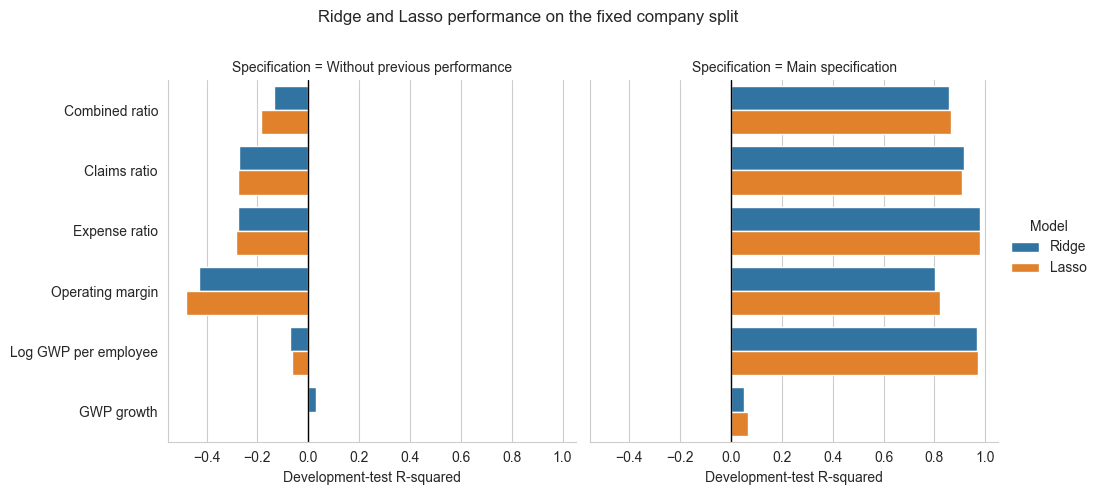

In [49]:
#keeping only the Ridge and Lasso performance results
plot_data = regularised_performance[
    regularised_performance["Model"].isin(
        ["Ridge", "Lasso"]
    )
].copy()

# creating separate bar charts for the two model specifications
regularised_plot = sns.catplot(
    data=plot_data,
    x="Test R-squared",
    y="Outcome",
    hue="Model",
    col="Specification",
    col_order=[
        WITHOUT_PREVIOUS_PERFORMANCE,
        MAIN_SPECIFICATION
    ],
    hue_order=[
        "Ridge",
        "Lasso"
    ],
    kind="bar",
    sharex=True,
    height=5,
    aspect=1.05
)

for axis in regularised_plot.axes.flat: # adding a vertical reference line at zero to each panel
    axis.axvline(
        0,
        color="black",
        linewidth=1
    )

regularised_plot.set_axis_labels(
    "Development-test R-squared",
    ""
)

regularised_plot.fig.subplots_adjust(top=0.84)

regularised_plot.fig.suptitle(
    "Ridge and Lasso performance on the fixed company split"
)

plt.show()

## 10.4 Interpretation of AI-Adoption Coefficients

The following table isolates the coefficients for X1 and X2.

The predictors were standardised before model estimation, but the financial outcomes were not standardised. Each coefficient therefore represents the predicted change in the outcome’s original units associated with a one-standard-deviation increase in the corresponding AI-adoption score, holding the other predictors constant.

Coefficient signs and magnitudes can be examined within the same financial outcome and specification. However, coefficient magnitudes should not be directly compared across outcomes measured in different units.

For Lasso, a coefficient of zero means that the adoption score was not retained as an additional predictor under the selected penalty. It does not demonstrate that the adoption measure has no relationship with financial performance.


In [50]:
# extracting the coefficients for the two lagged AI adoption scores
adoption_coefficients = regularised_coefficients[
    regularised_coefficients["Feature"].isin(
        ["X1_lag1", "X2_lag1"]
    )
].copy()

# Replacing the technical lagged names with clearer display labels
adoption_coefficients["Feature"] = (
    adoption_coefficients["Feature"].replace({
        "X1_lag1": "X1",
        "X2_lag1": "X2"
    })
)

# creating a comparison table with separate columns for X1 and X2
adoption_coefficient_table = (
    adoption_coefficients

    # Arranging results by outcome, specification and model
    .pivot_table(
        index=[
            "Outcome",
            "Specification",
            "Model"
        ],

        # Using the AI adoption measures as separate columns
        columns="Feature",
        values="Coefficient (standardised X)"
    )
    .reset_index()
)

adoption_coefficient_table.round(4)

Feature,Outcome,Specification,Model,X1,X2
0,Claims ratio,Main specification,Lasso,-0.0003,0.0000
1,Claims ratio,Main specification,Ridge,-0.0014,-0.0004
2,Claims ratio,Without previous performance,Lasso,0.0000,0.0000
3,Claims ratio,Without previous performance,Ridge,-0.0007,0.0000
4,Combined ratio,Main specification,Lasso,0.0016,0.0000
5,Combined ratio,Main specification,Ridge,0.0062,-0.0008
6,Combined ratio,Without previous performance,Lasso,0.0200,0.0012
7,Combined ratio,Without previous performance,Ridge,0.0133,0.0012
8,Expense ratio,Main specification,Lasso,0.0013,0.0010
9,Expense ratio,Main specification,Ridge,0.0015,0.0011


# 11. Random Forest

Random Forest was used as an exploratory nonlinear check alongside Ridge and Lasso. Unlike the regularised linear models, it can capture nonlinear relationships and interactions without requiring them to be specified in advance.


## 11.1 Model Specification and Predictive Performance

The Random Forest used the main specification from Section 10, including lagged X1, lagged X2, the previous value of the financial outcome, lagged log GWP and year indicators. It also used the same fixed company-level development split, ensuring that all observations from one insurer remained together.

The trees were deliberately constrained using a maximum depth of three and a minimum of three observations per terminal leaf. These restrictions reduce the risk of overfitting in the small training sample. Because the hyperparameters were fixed rather than tuned, the results are treated as an exploratory nonlinear check rather than an optimised forecasting exercise.


In [51]:
random_forest_rows = []

for outcome in outcomes:
    _, X, y, _, train_mask, test_mask = prepare_model_data(
        lagged,
        outcome,
        MAIN_SPECIFICATION
    )

    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]

    random_forest = RandomForestRegressor(
        n_estimators=100,
        max_depth=3,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=RANDOM_STATE
    )

    random_forest.fit(X_train, y_train)
    prediction = random_forest.predict(X_test)

    random_forest_rows.append({
        "Outcome": outcome_labels[outcome],
        "Test R-squared": r2_score(y_test, prediction),
        "Test RMSE": mean_squared_error(y_test, prediction) ** 0.5,
        "Test MAE": mean_absolute_error(y_test, prediction)
    })

    # Permutation importance is calculated only for the combined ratio.
    if outcome == "CombinedRatio":
        importance = permutation_importance(
            random_forest,
            X_test,
            y_test,
            scoring="r2",
            n_repeats=10,
            random_state=RANDOM_STATE
        )

        combined_ratio_importance = pd.DataFrame({
            "Feature": X.columns,
            "Permutation importance": importance.importances_mean,
            "Importance SD": importance.importances_std
        }).sort_values("Permutation importance")

random_forest_performance = pd.DataFrame(random_forest_rows)

random_forest_performance.round(4)

,Outcome,Test R-squared,Test RMSE,Test MAE
0,Combined ratio,0.3531,0.0778,0.0498
1,Claims ratio,0.2884,0.1120,0.0817
2,Expense ratio,0.2941,0.0717,0.0474
3,Operating margin,0.4506,0.0507,0.0372
4,Log GWP per employee,0.3866,0.5394,0.4235
5,GWP growth,-0.0085,0.1185,0.0609


## 11.2 Permutation Feature Importance for the Combined Ratio

Permutation importance was calculated for the combined ratio because it is the main measure of underwriting efficiency. It measures how much test performance changes when the values of one predictor are randomly shuffled while the other predictors remain unchanged.

A positive importance means that shuffling the predictor reduced model performance, indicating that the predictor contained useful information. A value close to zero indicates little predictive contribution. A negative value means that performance improved slightly after the predictor was shuffled, suggesting that it may have introduced noise.

Permutation importance does not show whether the relationship is positive or negative. It therefore cannot determine whether higher AI adoption improves or worsens the combined ratio.


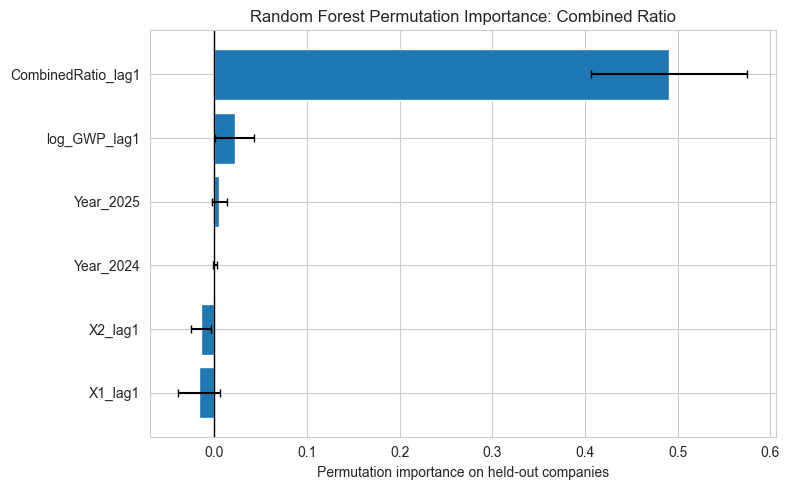

,Feature,Permutation importance,Importance SD
0,X1_lag1,-0.0165,0.0224
1,X2_lag1,-0.0145,0.0107
4,Year_2024,0.0009,0.0022
5,Year_2025,0.0054,0.0078
2,log_GWP_lag1,0.0220,0.0211
3,CombinedRatio_lag1,0.4908,0.0845


In [52]:
plt.figure(figsize=(8, 5))

plt.barh(
    combined_ratio_importance["Feature"],
    combined_ratio_importance["Permutation importance"],
    xerr=combined_ratio_importance["Importance SD"],
    capsize=3
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Permutation importance on held-out companies")
plt.title("Random Forest Permutation Importance: Combined Ratio")
plt.tight_layout()
plt.show()

combined_ratio_importance.round(4)

# 12. Leave-One-Carrier-Out Internal Validation

## 12.1 Nested Validation Design

The fixed company-level development split used in Sections 10 and 11 provides a useful initial assessment, but its results may depend on which insurers were assigned to the test sample. Leave-one-carrier-out validation therefore provides a broader internal assessment of model stability.

In each outer validation fold, all three observations belonging to one insurer are held out. The models are trained using the remaining 29 insurers and then used to predict the held-out insurer's 2023–2025 financial outcomes. This procedure is repeated until every insurer has served as the test carrier once.

Ridge and Lasso are evaluated using the main specification, which includes lagged X1, lagged X2, lagged log GWP, the previous value of the financial outcome and year indicators. The regularisation parameter is selected separately inside every outer fold using five-fold company-grouped cross-validation. Consequently, the held-out insurer does not influence model fitting, predictor standardisation or penalty selection.

The resulting metrics are calculated from the 90 pooled out-of-fold predictions. They assess stability across the 30 observed insurers rather than external forecasting performance or causal effects.


## 12.2 Validation Results

Performance is evaluated using pooled leave-one-carrier-out $R^2$, RMSE and MAE. Higher $R^2$ and lower RMSE and MAE indicate better predictive performance.

A training-mean benchmark is also calculated within each outer fold. This benchmark predicts the held-out insurer's observations using the average outcome among the remaining 29 insurers.


In [53]:
# setting up leave-one-carrier-out validation
outer_cv = LeaveOneGroupOut()


# defining the regularised models
models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=50000)
}

# creating a list to store the validation results
logo_rows = []


# running the validation separately for each financial outcome
for outcome in outcomes:

    # preparing the main specification data
    _, X, y, groups, _, _ = prepare_model_data(
        lagged,
        outcome,
        MAIN_SPECIFICATION
    )

    # evaluating Ridge and Lasso separately
    for model_name, estimator in models.items():

        # creating empty arrays for the out-of-fold predictions
        predictions = np.full(len(y), np.nan)
        benchmark_predictions = np.full(len(y), np.nan)


        # leaving out one carrier and training on all remaining carriers
        for train_index, test_index in outer_cv.split(
            X,
            y,
            groups
        ):

            # selecting the best alpha using grouped cross-validation
            # within the remaining training carriers
            model_search = GridSearchCV(
                estimator=Pipeline([
                    ("scale", StandardScaler()),
                    ("model", estimator)
                ]),
                param_grid={
                    "model__alpha": alpha_grid
                },
                scoring="neg_root_mean_squared_error",
                cv=GroupKFold(n_splits=5),
                n_jobs=1
            )


            # fitting the model without using the held-out carrier
            model_search.fit(
                X.iloc[train_index],
                y.iloc[train_index],
                groups=groups.iloc[train_index]
            )


            # predicting the three observations of the held-out carrier
            predictions[test_index] = model_search.predict(
                X.iloc[test_index]
            )


            # creating a training-mean benchmark for the same carrier
            benchmark_predictions[test_index] = (
                y.iloc[train_index].mean()
            )


        # calculating performance across all out-of-fold predictions
        logo_rows.append({
            "Outcome": outcome_labels[outcome],
            "Specification": MAIN_SPECIFICATION,
            "Model": model_name,
            "LOCO R-squared": r2_score(
                y,
                predictions
            ),
            "LOCO RMSE": mean_squared_error(
                y,
                predictions
            ) ** 0.5,
            "LOCO MAE": mean_absolute_error(
                y,
                predictions
            ),
            "Mean-benchmark R-squared": r2_score(
                y,
                benchmark_predictions
            )
        })


# combining the validation results into one table
logo_internal_validation = (
    pd.DataFrame(logo_rows)
    .sort_values(
        ["Outcome", "LOCO R-squared"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


# displaying the main performance measures
logo_internal_validation[
    [
        "Outcome",
        "Model",
        "LOCO R-squared",
        "LOCO RMSE",
        "LOCO MAE",
        "Mean-benchmark R-squared"
    ]
].round(4)

,Outcome,Model,LOCO R-squared,LOCO RMSE,LOCO MAE,Mean-benchmark R-squared
0,Claims ratio,Lasso,0.8961,0.0303,0.0223,-0.0675
1,Claims ratio,Ridge,0.8938,0.0307,0.0226,-0.0675
2,Combined ratio,Lasso,0.8123,0.0302,0.0204,-0.0633
3,Combined ratio,Ridge,0.8109,0.0303,0.0203,-0.0633
4,Expense ratio,Lasso,0.9813,0.0101,0.0074,-0.0695
5,Expense ratio,Ridge,0.9809,0.0102,0.0075,-0.0695
6,GWP growth,Ridge,0.0461,0.1046,0.0574,-0.0335
7,GWP growth,Lasso,0.0445,0.1047,0.0569,-0.0335
8,Log GWP per employee,Lasso,0.9688,0.0944,0.0633,-0.0690
9,Log GWP per employee,Ridge,0.9681,0.0955,0.0627,-0.0690


# 13. OLS Association Models

OLS complements the predictive models by estimating the direction, magnitude and uncertainty of the associations between previous-year AI adoption and next-year financial performance. Ridge, Lasso and Random Forest focus primarily on predictive performance, while OLS provides coefficients, confidence intervals and hypothesis tests.

No individual method is treated as the primary model. Instead, the different approaches address related but distinct questions.

All OLS association models include year indicators and use company-clustered standard errors. Clustering allows observations belonging to the same insurer to be statistically related. The estimates describe conditional associations and should not be interpreted as causal effects.


## 13.1 Main OLS Estimates

Two OLS specifications are estimated for each financial outcome:

1. Without previous performance: includes lagged X1, lagged X2, lagged log GWP and year indicators.
2. Main specification: additionally controls for the previous value of the financial outcome.

The main specification follows the study methodology because it accounts for the strong persistence of insurer financial performance. For each model, standard errors are clustered by company.

Because X1 and X2 are tested across six outcomes, Benjamini–Hochberg adjusted p-values are reported both within each specification and across all 24 AI-adoption tests.


In [54]:
# fitting one company-clustered OLS model
def fit_clustered_ols(data, outcome, specification):

    # defining the AI variables
    regression_terms = [
        "X1_lag1",
        "X2_lag1"
    ]

    required_columns = [
        "Company",
        "Year",
        outcome,
        "X1_lag1",
        "X2_lag1",
        "log_GWP_lag1"
    ]

    # adding previous financial performance to the main specification
    if specification == MAIN_SPECIFICATION:

        previous_outcome = outcome_lag_columns[outcome]

        regression_terms.append(previous_outcome)
        required_columns.append(previous_outcome)

    # adding insurer size and year controls
    regression_terms.extend([
        "log_GWP_lag1",
        "C(Year)"
    ])

    # confirming that every required variable exists before subsetting
    missing_columns = [
        column for column in required_columns
        if column not in data.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing columns required for {outcome}: {missing_columns}"
        )

    # keeping complete observations for the selected model
    model_data = (
        data[required_columns]
        .dropna()
        .copy()
    )

    # constructing the regression formula
    formula = (
        f"{outcome} ~ "
        f"{' + '.join(regression_terms)}"
    )

    # estimating OLS with company-clustered standard errors
    model = smf.ols(
        formula,
        data=model_data
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": model_data["Company"]
        }
    )

    return model, model_data

In [55]:
# storing the fitted models and coefficient results
ols_models = {}
ols_result_rows = []

# estimating both specifications for every outcome
for outcome in outcomes:
    for specification in specifications:

        model, model_data = fit_clustered_ols(
            lagged,
            outcome,
            specification
        )

        ols_models[(outcome, specification)] = model

        # extracting the X1 and X2 estimates
        for predictor in ["X1_lag1", "X2_lag1"]:
            confidence_interval = model.conf_int().loc[predictor]

            ols_result_rows.append({
                "Outcome": outcome_labels[outcome],
                "Specification": specification,
                "Predictor": predictor.replace("_lag1", ""),
                "Coefficient": model.params[predictor],
                "Clustered SE": model.bse[predictor],
                "p-value": model.pvalues[predictor],
                "95% CI lower": confidence_interval.iloc[0],
                "95% CI upper": confidence_interval.iloc[1],
                "Adjusted R-squared": model.rsquared_adj,
                "N": int(model.nobs)
            })


# combining the estimates into one table
ols_results = pd.DataFrame(ols_result_rows)

# applying BH correction separately within each specification
ols_results["BH adjusted p-value: within specification"] = (
    ols_results
    .groupby("Specification")["p-value"]
    .transform(
        lambda p: multipletests(
            p,
            method="fdr_bh"
        )[1]
    )
)

# applying BH correction across all 24 X1 and X2 tests
ols_results["BH adjusted p-value: all 24 tests"] = multipletests(
    ols_results["p-value"],
    method="fdr_bh"
)[1]

# displaying the main-specification results first
main_ols_results = ols_results[
    ols_results["Specification"] == MAIN_SPECIFICATION
]

display(main_ols_results.round(4))
display(ols_results.round(4))

,Outcome,Specification,Predictor,Coefficient,Clustered SE,p-value,95% CI lower,95% CI upper,Adjusted R-squared,N,BH adjusted p-value: within specification,BH adjusted p-value: all 24 tests
2,Combined ratio,Main specification,X1,0.0306,0.0081,0.0002,0.0147,0.0465,0.8196,90,0.0019,0.0038
3,Combined ratio,Main specification,X2,-0.0064,0.0114,0.5740,-0.0288,0.0160,0.8196,90,0.7903,0.8577
6,Claims ratio,Main specification,X1,0.0083,0.0119,0.4886,-0.0151,0.0317,0.8983,90,0.7903,0.8227
7,Claims ratio,Main specification,X2,-0.0031,0.0138,0.8212,-0.0302,0.0239,0.8983,90,0.8266,0.8626
10,Expense ratio,Main specification,X1,0.0090,0.0051,0.0770,-0.0010,0.0190,0.9822,90,0.4344,0.4893
11,Expense ratio,Main specification,X2,0.0096,0.0060,0.1086,-0.0021,0.0213,0.9822,90,0.4344,0.4893
14,Operating margin,Main specification,X1,-0.0135,0.0093,0.1449,-0.0317,0.0047,0.8099,90,0.4348,0.4893
15,Operating margin,Main specification,X2,-0.0029,0.0130,0.8266,-0.0284,0.0227,0.8099,90,0.8266,0.8626
18,Log GWP per employee,Main specification,X1,-0.0234,0.0529,0.6586,-0.1271,0.0804,0.9722,90,0.7903,0.8577
19,Log GWP per employee,Main specification,X2,-0.0356,0.0801,0.6565,-0.1926,0.1213,0.9722,90,0.7903,0.8577


,Outcome,Specification,Predictor,Coefficient,Clustered SE,p-value,95% CI lower,95% CI upper,Adjusted R-squared,N,BH adjusted p-value: within specification,BH adjusted p-value: all 24 tests
0,Combined ratio,Without previous performance,X1,0.0568,0.0413,0.1696,-0.0242,0.1378,0.0690,90,0.4893,0.4893
1,Combined ratio,Without previous performance,X2,-0.0883,0.0657,0.1791,-0.2171,0.0405,0.0690,90,0.4893,0.4893
2,Combined ratio,Main specification,X1,0.0306,0.0081,0.0002,0.0147,0.0465,0.8196,90,0.0019,0.0038
3,Combined ratio,Main specification,X2,-0.0064,0.0114,0.5740,-0.0288,0.0160,0.8196,90,0.7903,0.8577
4,Claims ratio,Without previous performance,X1,-0.1004,0.0790,0.2039,-0.2551,0.0544,0.0203,90,0.4893,0.4893
5,Claims ratio,Without previous performance,X2,-0.0678,0.0871,0.4360,-0.2384,0.1028,0.0203,90,0.6540,0.8049
6,Claims ratio,Main specification,X1,0.0083,0.0119,0.4886,-0.0151,0.0317,0.8983,90,0.7903,0.8227
7,Claims ratio,Main specification,X2,-0.0031,0.0138,0.8212,-0.0302,0.0239,0.8983,90,0.8266,0.8626
8,Expense ratio,Without previous performance,X1,0.1377,0.0540,0.0107,0.0320,0.2435,0.1014,90,0.1285,0.1285
9,Expense ratio,Without previous performance,X2,0.0169,0.0689,0.8064,-0.1181,0.1519,0.1014,90,0.8797,0.8626


### 13.1.1 Incremental Explanatory Value of AI Adoption

The main OLS specification contains a lagged dependent variable because insurer financial outcomes are highly persistent over time. A high model R-squared may therefore largely reflect the predictive information contained in previous-year financial performance rather than AI adoption itself.

To assess the incremental explanatory contribution of the AI-adoption variables, the main specification is compared with an autoregressive baseline that excludes X1 and X2.

Baseline specification:

$$
Y_{it} = \alpha + \rho Y_{i,t-1} + \gamma \log(GWP_{i,t-1}) + \delta_t + \varepsilon_{it}
$$

AI-augmented specification:

$$
Y_{it} = \alpha + \beta_1 X1_{i,t-1} + \beta_2 X2_{i,t-1} + \rho Y_{i,t-1} + \gamma \log(GWP_{i,t-1}) + \delta_t + \varepsilon_{it}
$$

Both models are estimated on exactly the same observations and use company-clustered standard errors. Changes in adjusted R-squared and AIC are used to assess model fit, while a joint Wald test evaluates whether X1 and X2 jointly contribute explanatory information beyond previous financial performance, company size and year effects.

In [56]:
# comparing the autoregressive baseline with the full AI-augmented model

incremental_fit_rows = []

for outcome in outcomes:

    # identifying the correct previous-year outcome column
    previous_outcome = outcome_lag_columns[outcome]

    # fitting the existing full main specification
    # this contains:
    # X1_lag1 + X2_lag1 + previous outcome + log GWP + year effects
    full_model, model_data = fit_clustered_ols(
        lagged,
        outcome,
        MAIN_SPECIFICATION
    )

    # autoregressive baseline:
    # previous outcome + log GWP + year effects
    # X1 and X2 are deliberately excluded
    baseline_formula = (
        f"{outcome} ~ "
        f"{previous_outcome} "
        "+ log_GWP_lag1 "
        "+ C(Year)"
    )

    # fitting the baseline on EXACTLY the same observations
    # used by the full model
    baseline_model = smf.ols(
        baseline_formula,
        data=model_data
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": model_data["Company"]
        }
    )

    # jointly testing whether X1 and X2 add explanatory information
    # beyond the autoregressive baseline
    ai_joint_test = full_model.wald_test(
        "X1_lag1 = 0, X2_lag1 = 0",
        scalar=True
    )

    # storing the comparison results
    incremental_fit_rows.append({
        "Outcome": outcome_labels[outcome],

        "Baseline adjusted R-squared":
            baseline_model.rsquared_adj,

        "Full adjusted R-squared":
            full_model.rsquared_adj,

        "Delta adjusted R-squared":
            full_model.rsquared_adj
            - baseline_model.rsquared_adj,

        "Baseline AIC":
            baseline_model.aic,

        "Full AIC":
            full_model.aic,

        "Delta AIC":
            full_model.aic
            - baseline_model.aic,

        "Joint X1/X2 Wald p-value":
            float(np.asarray(ai_joint_test.pvalue).squeeze()),

        "N":
            int(full_model.nobs)
    })


# combining all six outcome comparisons
incremental_fit_comparison = pd.DataFrame(
    incremental_fit_rows
)

display(
    incremental_fit_comparison.round(4)
)

,Outcome,Baseline adjusted R-squared,Full adjusted R-squared,Delta adjusted R-squared,Baseline AIC,Full AIC,Delta AIC,Joint X1/X2 Wald p-value,N
0,Combined ratio,0.8175,0.8196,0.0021,-371.0916,-370.2922,0.7993,0.0002,90
1,Claims ratio,0.9005,0.8983,-0.0022,-371.7831,-367.9867,3.7964,0.7675,90
2,Expense ratio,0.9815,0.9822,0.0007,-566.2630,-567.6555,-1.3925,0.0548,90
3,Operating margin,0.8120,0.8099,-0.0021,-403.8684,-401.0111,2.8573,0.3162,90
4,Log GWP per employee,0.9727,0.9722,-0.0004,-175.3987,-172.0968,3.3019,0.5160,90
5,GWP growth,0.1011,0.1022,0.0011,-150.4399,-148.6962,1.7437,0.0519,90


## 13.2 Interpreting the Combined-Ratio Coefficients

The combined ratio is recorded as a decimal and lower values represent better underwriting performance. A positive coefficient is therefore associated with a higher, less favourable next-year combined ratio, while a negative coefficient is associated with a lower, more favourable ratio.

Because X1 and X2 range from 0 to 1, the table converts the coefficients into the estimated change associated with a 0.1-point increase in each adoption score. The resulting effect is also expressed in percentage points.


In [57]:
# selecting the combined-ratio estimates
combined_ratio_effects = (
    ols_results[
        ols_results["Outcome"] == "Combined ratio"
    ]
    .copy()
)


# converting coefficients into effects of a 0.1-point score increase
combined_ratio_effects["Effect of +0.1 score"] = (
    combined_ratio_effects["Coefficient"] * 0.1
)

combined_ratio_effects["Percentage-point effect of +0.1"] = (
    combined_ratio_effects["Coefficient"] * 10
)


# converting the confidence limits to the same percentage-point scale
combined_ratio_effects["95% CI lower: pp effect of +0.1"] = (
    combined_ratio_effects["95% CI lower"] * 10
)

combined_ratio_effects["95% CI upper: pp effect of +0.1"] = (
    combined_ratio_effects["95% CI upper"] * 10
)


# displaying effect sizes and their uncertainty in interpretable units
combined_ratio_effects[
    [
        "Specification",
        "Predictor",
        "Coefficient",
        "Effect of +0.1 score",
        "Percentage-point effect of +0.1",
        "95% CI lower: pp effect of +0.1",
        "95% CI upper: pp effect of +0.1",
        "p-value",
        "BH adjusted p-value: all 24 tests",
    ]
].round(4)


,Specification,Predictor,Coefficient,Effect of +0.1 score,Percentage-point effect of +0.1,95% CI lower: pp effect of +0.1,95% CI upper: pp effect of +0.1,p-value,BH adjusted p-value: all 24 tests
0,Without previous performance,X1,0.0568,0.0057,0.5676,-0.2423,1.3775,0.1696,0.4893
1,Without previous performance,X2,-0.0883,-0.0088,-0.8830,-2.1712,0.4051,0.1791,0.4893
2,Main specification,X1,0.0306,0.0031,0.3062,0.1473,0.4651,0.0002,0.0038
3,Main specification,X2,-0.0064,-0.0006,-0.0642,-0.2882,0.1597,0.5740,0.8577


In [58]:
# displaying the complete main combined-ratio model
main_combined_ratio_model = ols_models[
    ("CombinedRatio", MAIN_SPECIFICATION)
]

print(main_combined_ratio_model.summary())

                            OLS Regression Results                            
Dep. Variable:          CombinedRatio   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     203.2
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           2.50e-22
Time:                        20:08:58   Log-Likelihood:                 192.15
No. Observations:                  90   AIC:                            -370.3
Df Residuals:                      83   BIC:                            -352.8
Df Model:                           6                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.1374      0

## 13.3 Combined-Ratio Specification Checks

### 13.3.1 Alternative Controls and Size Measures

Several combined-ratio specifications are compared to assess whether the X1 and X2 estimates are sensitive to the choice of controls.

The models begin with the adoption scores alone and then add year indicators, previous combined ratio and alternative size controls. Adjusted $R^2$ and AIC describe in-sample model fit, while the X1 and X2 columns show whether the adoption estimates remain reasonably stable.


In [59]:
# defining alternative combined-ratio specifications
combined_ratio_specifications = {
    "1. Adoption scores only":
        "CombinedRatio ~ X1_lag1 + X2_lag1",

    "2. Without previous performance":
        "CombinedRatio ~ X1_lag1 + X2_lag1 "
        "+ log_GWP_lag1 + C(Year)",

    f"3. {MAIN_SPECIFICATION}":
        "CombinedRatio ~ X1_lag1 + X2_lag1 "
        "+ CombinedRatio_lag1 + log_GWP_lag1 + C(Year)",

    "4. Main specification + tier":
        "CombinedRatio ~ X1_lag1 + X2_lag1 "
        "+ CombinedRatio_lag1 + log_GWP_lag1 "
        "+ C(Year) + C(Tier)",

    "5. Assets instead of GWP":
        "CombinedRatio ~ X1_lag1 + X2_lag1 "
        "+ CombinedRatio_lag1 + log_Assets_lag1 + C(Year)",

    "6. GWP and assets":
        "CombinedRatio ~ X1_lag1 + X2_lag1 "
        "+ CombinedRatio_lag1 + log_GWP_lag1 "
        "+ log_Assets_lag1 + C(Year)",

    "7. Main specification + region":
        "CombinedRatio ~ X1_lag1 + X2_lag1 "
        "+ CombinedRatio_lag1 + log_GWP_lag1 "
        "+ C(Year) + C(Region)"
}


# using the same complete observations in every comparison model
comparison_columns = [
    "Company",
    "Year",
    "Tier",
    "Region",
    "CombinedRatio",
    "X1_lag1",
    "X2_lag1",
    "CombinedRatio_lag1",
    "log_GWP_lag1",
    "log_Assets_lag1"
]

comparison_data = lagged[
    comparison_columns
].dropna().copy()


# estimating and comparing the specifications
model_comparison_rows = []
combined_ratio_models = {}

for label, formula in combined_ratio_specifications.items():

    model = smf.ols(
        formula,
        data=comparison_data
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": comparison_data["Company"]}
    )

    combined_ratio_models[label] = model

    model_comparison_rows.append({
        "Specification": label,
        "N": int(model.nobs),
        "Adjusted R-squared": model.rsquared_adj,
        "AIC": model.aic,
        "X1 coefficient": model.params["X1_lag1"],
        "X1 clustered p-value": model.pvalues["X1_lag1"],
        "X2 coefficient": model.params["X2_lag1"],
        "X2 clustered p-value": model.pvalues["X2_lag1"]
    })


model_comparison = pd.DataFrame(model_comparison_rows)

model_comparison.round(4)

,Specification,N,Adjusted R-squared,AIC,X1 coefficient,X1 clustered p-value,X2 coefficient,X2 clustered p-value
0,1. Adoption scores only,90,-0.0023,-219.6973,0.0474,0.1204,-0.0780,0.2306
1,2. Without previous performance,90,0.0690,-223.4983,0.0568,0.1696,-0.0883,0.1791
2,3. Main specification,90,0.8196,-370.2922,0.0306,0.0002,-0.0064,0.5740
3,4. Main specification + tier,90,0.8300,-373.7944,0.0291,0.0162,0.0072,0.6585
4,5. Assets instead of GWP,90,0.8228,-371.8837,0.0263,0.0027,-0.0051,0.6114
5,6. GWP and assets,90,0.8247,-371.9727,0.0245,0.0124,0.0083,0.4974
6,7. Main specification + region,90,0.8299,-370.3184,0.0293,0.0489,-0.0064,0.6985


Adding region as a categorical control does not materially alter the estimated X1 coefficient for next-year Combined Ratio. The coefficient changes only modestly from 0.0306 in the main specification to 0.0293 after controlling for region, while remaining positive and statistically significant at the 5% level (p = 0.0489). This suggests that the estimated association is not primarily driven by broad geographic differences across insurers, although the weaker statistical significance indicates that inference is somewhat sensitive to the inclusion of regional controls. X2 remains statistically insignificant.

### 13.3.2 Tier Indicators

Tier was tested because it was considered as a possible company-size control. However, tier is assigned partly from company size and may duplicate information already represented by lagged log GWP.

A nested F-test compares the main specification with and without the tier indicators. Because this test uses conventional OLS assumptions, it is treated as a supporting in-sample specification check rather than the main inferential result.


In [60]:
# fitting nested ordinary OLS models for the tier comparison
model_without_tier = smf.ols(
    combined_ratio_specifications[f"3. {MAIN_SPECIFICATION}"],
    data=comparison_data
).fit()

model_with_tier = smf.ols(
    combined_ratio_specifications["4. Main specification + tier"],
    data=comparison_data
).fit()


# testing whether the two tier indicators jointly improve model fit
f_statistic, f_p_value, parameters_added = (
    model_with_tier.compare_f_test(model_without_tier)
)


tier_test_results = pd.Series({
    "F statistic": f_statistic,
    "p-value": f_p_value,
    "Parameters added": int(parameters_added),
    "Adjusted R-squared without tier":
        model_without_tier.rsquared_adj,
    "Adjusted R-squared with tier":
        model_with_tier.rsquared_adj,
    "X1 coefficient without tier":
        model_without_tier.params["X1_lag1"],
    "X1 coefficient with tier":
        model_with_tier.params["X1_lag1"]
})

tier_test_results.round(4)

F statistic                        3.5207
p-value                            0.0342
Parameters added                   2.0000
Adjusted R-squared without tier    0.8196
Adjusted R-squared with tier       0.8300
X1 coefficient without tier        0.0306
X1 coefficient with tier           0.0291
dtype: float64

## 13.4 Main-Model Diagnostics

### 13.4.1 Multicollinearity

Variance inflation factors assess whether the continuous predictors in the main combined-ratio specification contain substantial overlapping information. A constant is included when calculating the VIF values to avoid misleading uncentred estimates.


In [61]:
# selecting the continuous predictors from the main model
vif_variables = [
    "X1_lag1",
    "X2_lag1",
    "CombinedRatio_lag1",
    "log_GWP_lag1"
]

vif_data = lagged[vif_variables].dropna().copy()


# including a constant in the VIF design matrix
vif_design = sm.add_constant(vif_data)


# calculating VIF for every variable
vif_table = pd.DataFrame({
    "Variable": vif_design.columns,
    "VIF": [
        variance_inflation_factor(
            vif_design.values,
            index
        )
        for index in range(vif_design.shape[1])
    ]
})


# removing the constant from the displayed table
vif_table = vif_table[
    vif_table["Variable"] != "const"
]

vif_table.round(2)

,Variable,VIF
1,X1_lag1,1.59
2,X2_lag1,1.63
3,CombinedRatio_lag1,1.10
4,log_GWP_lag1,1.20


### 13.4.2 Residual Diagnostics

The residual-versus-fitted plot is used to identify systematic patterns or changing residual variance. The Q–Q plot and histogram describe the residual distribution.

These plots are descriptive diagnostics. Exact residual normality is not required for the company-clustered estimates, although substantial outliers or systematic patterns may still affect the model.


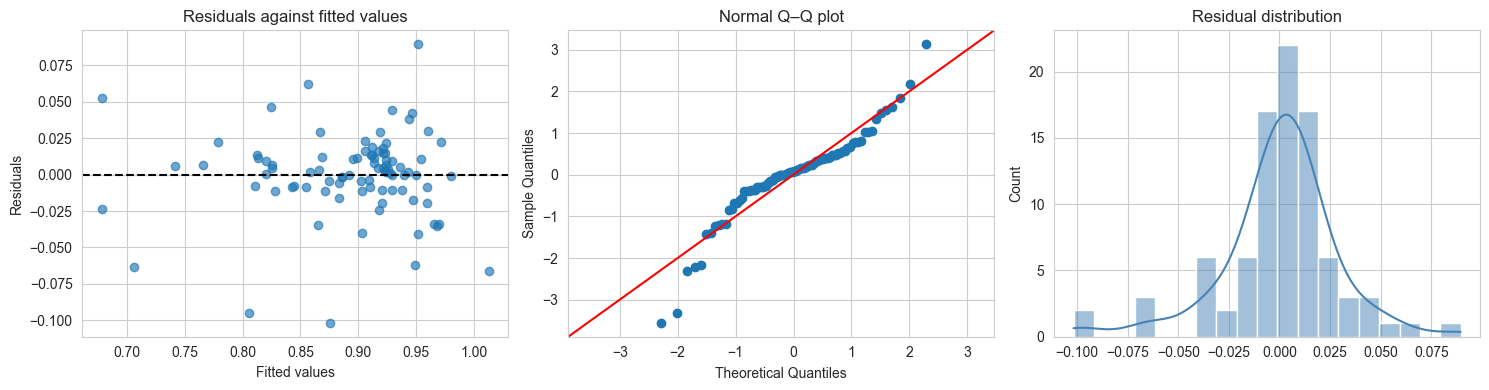

In [62]:
# reusing the fitted main combined-ratio model
residuals = main_combined_ratio_model.resid
fitted_values = main_combined_ratio_model.fittedvalues

# plotting the main residual diagnostics
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

axes[0].scatter(
    fitted_values,
    residuals,
    alpha=0.65
)
axes[0].axhline(
    0,
    color="black",
    linestyle="--"
)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals against fitted values")

sm.qqplot(
    residuals,
    line="45",
    fit=True,
    ax=axes[1]
)
axes[1].set_title("Normal Q–Q plot")

sns.histplot(
    residuals,
    kde=True,
    ax=axes[2],
    color="steelblue"
)
axes[2].set_title("Residual distribution")

plt.tight_layout()
plt.show()

## 13.5 Conventional and Company-Clustered Standard Errors

Each insurer contributes three observations to the lagged panel. Conventional OLS standard errors treat these observations as independent, while company-clustered standard errors allow residuals from the same insurer to be related.

Both approaches produce identical coefficients because the underlying OLS estimates are unchanged. Only the estimated standard errors, confidence intervals and p-values differ. Company-clustered standard errors are used for the main association results because they better reflect the panel structure.


In [63]:
# retrieving the exact data and formula used by the main model
main_model_data = main_combined_ratio_model.model.data.frame
main_model_formula = main_combined_ratio_model.model.formula

# fitting only the conventional-SE version
# the clustered version has already been fitted in Section 13.1
ordinary_model = smf.ols(
    main_model_formula,
    data=main_model_data
).fit()

clustered_model = main_combined_ratio_model

# Comparing uncertainty estimates for the continuous predictors
se_predictors = [
    "X1_lag1",
    "X2_lag1",
    "CombinedRatio_lag1",
    "log_GWP_lag1"
]

standard_error_comparison = pd.DataFrame({
    "Predictor": se_predictors,
    "Coefficient": [
        ordinary_model.params[predictor]
        for predictor in se_predictors
    ],
    "Ordinary SE": [
        ordinary_model.bse[predictor]
        for predictor in se_predictors
    ],
    "Ordinary p-value": [
        ordinary_model.pvalues[predictor]
        for predictor in se_predictors
    ],
    "Clustered SE": [
        clustered_model.bse[predictor]
        for predictor in se_predictors
    ],
    "Clustered p-value": [
        clustered_model.pvalues[predictor]
        for predictor in se_predictors
    ]
})

standard_error_comparison.round(4)

,Predictor,Coefficient,Ordinary SE,Ordinary p-value,Clustered SE,Clustered p-value
0,X1_lag1,0.0306,0.0188,0.1070,0.0081,0.0002
1,X2_lag1,-0.0064,0.0281,0.8199,0.0114,0.5740
2,CombinedRatio_lag1,0.8304,0.0443,0.0000,0.0352,0.0000
3,log_GWP_lag1,0.0010,0.0031,0.7476,0.0016,0.5360


## 13.6 Zero-Score Sensitivity Analysis

A substantial share of the panel scores zero on both AI-adoption constructs, particularly in 2022. Zero remains the appropriate coded value when no retrievable evidence of adoption was identified, but its influence is examined through two sensitivity samples.

The first sensitivity test removes observations whose AI predictors come from 2022. The second removes lagged observations in which both X1 and X2 equal zero. These estimates are compared with the full lagged sample.

The purpose is to examine whether the direction and approximate magnitude of the adoption coefficients depend entirely on the concentration of zero scores. Changes in statistical significance must also be interpreted alongside the smaller sample sizes.


In [64]:
# counting observations that score zero on both constructs
zero_years_per_company = (
    df.groupby("Company")["Zero Both Scores"].sum()
)

always_zero = zero_years_per_company[
    zero_years_per_company == 4
].index.tolist()

print("Carrier-years scoring zero on both constructs, by year:")
print(
    df.groupby("Year")["Zero Both Scores"]
    .sum()
    .to_string()
)

print(
    "\nCarriers scoring zero on both in all four years:",
    always_zero if always_zero else "none"
)


# defining the full sample and two sensitivity samples
zero_samples = {
    "Full lagged sample":
        lagged,

    "Exclude 2022 predictor year":
        lagged[lagged["Year"] > 2023],

    "Exclude zero-both predictor rows":
        lagged[
            ~lagged["Zero Both Lagged"].eq(True)
        ]
}

# re-estimating the main combined-ratio model in each sample
zero_rows = []
for label, sample in zero_samples.items():

    model, sample_data = fit_clustered_ols(
        sample,
        "CombinedRatio",
        MAIN_SPECIFICATION
    )

    zero_rows.append({
        "Sample": label,
        "N": int(model.nobs),
        "Carriers": sample_data["Company"].nunique(),
        "X1 coefficient": model.params["X1_lag1"],
        "X1 p-value": model.pvalues["X1_lag1"],
        "X2 coefficient": model.params["X2_lag1"],
        "X2 p-value": model.pvalues["X2_lag1"],
        "Adjusted R-squared": model.rsquared_adj
    })

zero_sensitivity = pd.DataFrame(zero_rows)
zero_sensitivity.round(4)

Carrier-years scoring zero on both constructs, by year:
Year
2022    15
2023     5
2024     1
2025     0

Carriers scoring zero on both in all four years: none


,Sample,N,Carriers,X1 coefficient,X1 p-value,X2 coefficient,X2 p-value,Adjusted R-squared
0,Full lagged sample,90,30,0.0306,0.0002,-0.0064,0.5740,0.8196
1,Exclude 2022 predictor year,60,30,0.0191,0.0688,-0.0111,0.4446,0.8526
2,Exclude zero-both predictor rows,69,29,0.0367,0.0034,-0.0048,0.7313,0.8021


## 13.7 Company Fixed-Effects Robustness

Company fixed effects compare each insurer with itself over time and absorb all stable company characteristics, including persistent differences in product mix, management structure and business model.

The lagged financial outcome is deliberately excluded from this specification. Combining company fixed effects with a lagged dependent variable would introduce substantial dynamic-panel bias when only three outcome years are available.

This model therefore addresses a different question from the main OLS specification: whether within-company changes in AI adoption are associated with within-company changes in financial performance. The results are treated as a robustness check because X1 and X2 change slowly within many insurers.


In [65]:
# storing the fixed-effects estimates
fixed_effect_rows = []

for outcome in outcomes: # estimating one company fixed-effects model for each outcome
    required_columns = [
        "Company",
        "Year",
        outcome,
        "X1_lag1",
        "X2_lag1",
        "log_GWP_lag1"
    ]

    model_data = lagged[
        required_columns
    ].dropna().copy()

    formula = (
        f"{outcome} ~ X1_lag1 + X2_lag1 "
        "+ log_GWP_lag1 + C(Year) + C(Company)"
    )

    model = smf.ols(  # fitting OLS with company indicators and clustered standard errors
        formula,
        data=model_data
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": model_data["Company"]}
    )

    # extracting the within-company X1 and X2 estimates
    for predictor in ["X1_lag1", "X2_lag1"]:

        fixed_effect_rows.append({
            "Outcome": outcome_labels[outcome],
            "Predictor": predictor.replace("_lag1", ""),
            "Coefficient": model.params[predictor],
            "Clustered SE": model.bse[predictor],
            "p-value": model.pvalues[predictor]
        })


fixed_effect_results = pd.DataFrame(
    fixed_effect_rows
)

# applying BH correction before rounding the p-values
fixed_effect_results["BH adjusted p-value"] = multipletests(
    fixed_effect_results["p-value"],
    method="fdr_bh"
)[1]


fixed_effect_results.round(4)

,Outcome,Predictor,Coefficient,Clustered SE,p-value,BH adjusted p-value
0,Combined ratio,X1,0.0414,0.0304,0.1724,0.8940
1,Combined ratio,X2,0.0027,0.0413,0.9477,0.9477
2,Claims ratio,X1,0.0322,0.0310,0.2980,0.8940
3,Claims ratio,X2,-0.0196,0.0441,0.6569,0.9477
4,Expense ratio,X1,0.0066,0.0147,0.6546,0.9477
5,Expense ratio,X2,0.0145,0.0130,0.2641,0.8940
6,Operating margin,X1,-0.0087,0.0235,0.7124,0.9477
7,Operating margin,X2,-0.0194,0.0283,0.4935,0.9477
8,Log GWP per employee,X1,0.0961,0.1150,0.4035,0.9477
9,Log GWP per employee,X2,-0.3120,0.1427,0.0288,0.3451


# 14. Score-Weighting Sensitivity Analysis

The official X1 and X2 measures give equal weight to their underlying components. This section examines whether the findings depend on that particular weighting choice.

The equal-weight scores are first reconstructed from the four business dimensions and five operating stages. This verifies that the detailed component data reproduce the official scores. Four theory-driven alternative weighting schemes are then examined.

The official X1 and X2 scores remain the measures used in the main analysis.


## 14.1 Alternative Weighting Scenarios

| Scenario | Change from the official equal weights |
|---|---|
| Value-proposition-led X1 | Value-Proposition Shift receives 40%; the other business dimensions receive 20% each |
| Tech-stack-led X1 | Tech-Stack Completeness receives 40%; the other business dimensions receive 20% each |
| Core-workflow X2 | Underwriting and Claims receive twice the weight of the other operating stages |
| Customer-facing X2 | Distribution and Policy Servicing receive twice the weight of the other operating stages |

The alternative weights were chosen before examining their regression results. They test plausible theoretical priorities rather than searching for weight combinations that produce favourable coefficients.


In [66]:
# calculating a weighted score from its component columns
def weighted_score(data, weights):
    return sum(
        data[column] * weight
        for column, weight in weights.items()
    )

# official equal weights used to validate the reconstruction
equal_business_weights = {
    "Intelligence Scalability": 0.25,
    "Value-Proposition Shift": 0.25,
    "Innovation Velocity": 0.25,
    "Tech-Stack Completeness": 0.25,
}

equal_operating_weights = {
    "Distribution": 0.20,
    "Underwriting": 0.20,
    "Claims": 0.20,
    "Policy Servicing": 0.20,
    "Product Development": 0.20,
}

# four alternative weighting schemes
alternative_weights = {
    "X1_weight_value_proposition": {
        "Intelligence Scalability": 0.20,
        "Value-Proposition Shift": 0.40,
        "Innovation Velocity": 0.20,
        "Tech-Stack Completeness": 0.20,
    },
    "X1_weight_tech_stack": {
        "Intelligence Scalability": 0.20,
        "Value-Proposition Shift": 0.20,
        "Innovation Velocity": 0.20,
        "Tech-Stack Completeness": 0.40,
    },
    "X2_weight_core_workflow": {
        "Distribution": 1 / 7,
        "Underwriting": 2 / 7,
        "Claims": 2 / 7,
        "Policy Servicing": 1 / 7,
        "Product Development": 1 / 7,
    },
    "X2_weight_customer_facing": {
        "Distribution": 2 / 7,
        "Underwriting": 1 / 7,
        "Claims": 1 / 7,
        "Policy Servicing": 2 / 7,
        "Product Development": 1 / 7,
    },
}

# reconstructing the official equal-weight scores
df["X1_equal_check"] = weighted_score(
    df,
    equal_business_weights,
)

df["X2_equal_check"] = weighted_score(
    df,
    equal_operating_weights,
)

# calculating the four alternative scores
for score_column, weights in alternative_weights.items():
    df[score_column] = weighted_score(df, weights)

# confirming that the components reproduce the official scores
equal_weight_validation = pd.Series({
    "Maximum X1 reconstruction difference": (
        df["X1_equal_check"] - df["X1"]
    ).abs().max(),
    "Maximum X2 reconstruction difference": (
        df["X2_equal_check"] - df["X2"]
    ).abs().max(),
    "X1 reconstructed correctly": np.allclose(
        df["X1_equal_check"],
        df["X1"],
    ),
    "X2 reconstructed correctly": np.allclose(
        df["X2_equal_check"],
        df["X2"],
    ),
})

display(equal_weight_validation.to_frame("Value"))

# official scores plus four genuine sensitivity scenarios
weighting_scenarios = {
    "Official scores": ("X1", "X2"),
    "Value-proposition-led X1": (
        "X1_weight_value_proposition",
        "X2",
    ),
    "Tech-stack-led X1": (
        "X1_weight_tech_stack",
        "X2",
    ),
    "Core-workflow X2": (
        "X1",
        "X2_weight_core_workflow",
    ),
    "Customer-facing X2": (
        "X1",
        "X2_weight_customer_facing",
    ),
}

,Value
Maximum X1 reconstruction difference,0.0
Maximum X2 reconstruction difference,0.0
X1 reconstructed correctly,True
X2 reconstructed correctly,True


## 14.2 Score Stability

Each alternative score is compared with the corresponding official score across all 120 company-year observations. The table reports the correlation with the official score and the mean absolute score change.

This section does not assign companies to archetypes. Company grouping is examined separately in Section 16 using K-means clustering. Keeping classification out of this section prevents a researcher-defined threshold from being mixed with the score-weighting test.

High correlations and small absolute changes would indicate that the numerical company positions are not driven by one particular reasonable weighting choice.


In [67]:
# comparing each scenario with the official scores
score_stability_rows = []

for scenario, (x1_column, x2_column) in weighting_scenarios.items():
    score_stability_rows.append({
        "Weighting scenario": scenario,
        "X1 correlation with official": (
            df[x1_column].corr(df["X1"])
        ),
        "X2 correlation with official": (
            df[x2_column].corr(df["X2"])
        ),
        "Mean absolute X1 change": (
            df[x1_column] - df["X1"]
        ).abs().mean(),
        "Mean absolute X2 change": (
            df[x2_column] - df["X2"]
        ).abs().mean(),
    })

weight_score_stability = pd.DataFrame(score_stability_rows)
display(weight_score_stability.round(3))

,Weighting scenario,X1 correlation with official,X2 correlation with official,Mean absolute X1 change,Mean absolute X2 change
0,Official scores,1.000,1.000,0.000,0.000
1,Value-proposition-led X1,0.988,1.000,0.027,0.000
2,Tech-stack-led X1,0.991,1.000,0.025,0.000
3,Core-workflow X2,1.000,0.978,0.000,0.033
4,Customer-facing X2,1.000,0.974,0.000,0.028


## 14.3 OLS Stability Under Alternative Weights

The Section 13 main specification is re-estimated for all six financial outcomes under the official scores and each of the four alternative weighting scenarios:

$$
Y_{it}
=
\alpha
+
\beta_1 X1_{i,t-1}
+
\beta_2 X2_{i,t-1}
+
\rho Y_{i,t-1}
+
\gamma \log(GWP_{i,t-1})
+
\delta_t
+
\varepsilon_{it}
$$

The regressions retain the same one-year lag, previous-outcome control, lagged company-size control, year indicators and company-clustered standard errors used in Section 13.

The purpose is to assess coefficient direction and approximate magnitude. The sensitivity regressions do not replace the official-score models or create additional confirmatory hypothesis tests.


In [68]:
# preparing a panel containing every alternative score
sensitivity_panel = df.sort_values(
    ["Company", "Year"]
).copy()

# identifying all columns that require a one-year lag
score_columns = [
    column
    for scenario_columns in weighting_scenarios.values()
    for column in scenario_columns
]

columns_to_lag = list(dict.fromkeys(
    outcomes
    + ["log_GWP"]
    + score_columns
))

# creating every required lag once
for column in columns_to_lag:
    sensitivity_panel[f"{column}_lag1"] = (
        sensitivity_panel
        .groupby("Company")[column]
        .shift(1)
    )

# re-estimating the main OLS specification for each scenario
weight_regression_rows = []

for scenario, (x1_column, x2_column) in weighting_scenarios.items():
    scenario_data = sensitivity_panel.copy()

    # using the standard names expected by fit_clustered_ols()
    scenario_data["X1_lag1"] = (
        scenario_data[f"{x1_column}_lag1"]
    )
    scenario_data["X2_lag1"] = (
        scenario_data[f"{x2_column}_lag1"]
    )

    for outcome in outcomes:
        model, model_data = fit_clustered_ols(
            scenario_data,
            outcome,
            MAIN_SPECIFICATION,
        )

        for predictor in ["X1_lag1", "X2_lag1"]:
            confidence_interval = model.conf_int().loc[predictor]

            weight_regression_rows.append({
                "Outcome": outcome_labels[outcome],
                "Weighting scenario": scenario,
                "Predictor": predictor.replace("_lag1", ""),
                "Coefficient": model.params[predictor],
                "95% CI lower": confidence_interval.iloc[0],
                "95% CI upper": confidence_interval.iloc[1],
                "p-value": model.pvalues[predictor],
                "Adjusted R-squared": model.rsquared_adj,
                "N": int(model.nobs),
            })

weight_sensitivity_results = pd.DataFrame(
    weight_regression_rows
)

# displaying the combined-ratio results
combined_ratio_weight_sensitivity = (
    weight_sensitivity_results[
        weight_sensitivity_results["Outcome"]
        == "Combined ratio"
    ]
)

display(
    combined_ratio_weight_sensitivity[
        [
            "Weighting scenario",
            "Predictor",
            "Coefficient",
            "95% CI lower",
            "95% CI upper",
            "p-value",
            "Adjusted R-squared",
            "N",
        ]
    ].round(4)
)

,Weighting scenario,Predictor,Coefficient,95% CI lower,95% CI upper,p-value,Adjusted R-squared,N
0,Official scores,X1,0.0306,0.0147,0.0465,0.0002,0.8196,90
1,Official scores,X2,-0.0064,-0.0288,0.0160,0.5740,0.8196,90
12,Value-proposition-led X1,X1,0.0309,0.0178,0.0440,0.0000,0.8200,90
13,Value-proposition-led X1,X2,-0.0076,-0.0327,0.0175,0.5533,0.8200,90
24,Tech-stack-led X1,X1,0.0301,0.0103,0.0498,0.0029,0.8197,90
25,Tech-stack-led X1,X2,-0.0058,-0.0266,0.0149,0.5824,0.8197,90
36,Core-workflow X2,X1,0.0287,0.0123,0.0451,0.0006,0.8195,90
37,Core-workflow X2,X2,-0.0001,-0.0261,0.0258,0.9912,0.8195,90
48,Customer-facing X2,X1,0.0314,0.0147,0.0481,0.0002,0.8199,90
49,Customer-facing X2,X2,-0.0108,-0.0310,0.0094,0.2964,0.8199,90


In [69]:
# summarising coefficient-direction stability
weighting_direction_summary = (
    weight_sensitivity_results
    .assign(
        Positive=lambda data: data["Coefficient"] > 0,
        Negative=lambda data: data["Coefficient"] < 0,
    )
    .groupby(["Outcome", "Predictor"])
    .agg(
        Minimum_coefficient=("Coefficient", "min"),
        Maximum_coefficient=("Coefficient", "max"),
        Positive_scenarios=("Positive", "sum"),
        Negative_scenarios=("Negative", "sum"),
        Scenarios=("Weighting scenario", "nunique"),
    )
    .reset_index()
)

display(weighting_direction_summary.round(4))

,Outcome,Predictor,Minimum_coefficient,Maximum_coefficient,Positive_scenarios,Negative_scenarios,Scenarios
0,Claims ratio,X1,0.0079,0.0106,5,0,5
1,Claims ratio,X2,-0.0054,-0.0015,0,5,5
2,Combined ratio,X1,0.0287,0.0314,5,0,5
3,Combined ratio,X2,-0.0108,-0.0001,0,5,5
4,Expense ratio,X1,0.0067,0.0108,5,0,5
5,Expense ratio,X2,0.0045,0.0137,5,0,5
6,GWP growth,X1,-0.0506,-0.0154,0,5,5
7,GWP growth,X2,-0.1202,-0.0466,0,5,5
8,Log GWP per employee,X1,-0.0400,-0.0008,0,5,5
9,Log GWP per employee,X2,-0.0866,0.0224,1,4,5


# 15. Two-Year-Lag Robustness Check

## 15.1 Design and Sample

This section examines whether the Section 13 OLS findings remain similar when the explanatory variables are measured two years before the financial outcome.

The model replaces the one-year lags in the main specification with two-year lags:

$$
Y_{it}
=
\alpha
+
\beta_1 X1_{i,t-2}
+
\beta_2 X2_{i,t-2}
+
\rho Y_{i,t-2}
+
\gamma \log(GWP_{i,t-2})
+
\delta_t
+
\varepsilon_{it}
$$

Therefore, the AI scores, previous financial outcome and company-size control are all measured in year $t-2$. Year indicators and company-clustered standard errors are retained.

Because the panel begins in 2022, only 2024 and 2025 remain as outcome years. The maximum sample consequently falls from 90 to 60 company-year observations, reducing statistical precision. This analysis is a lag-length robustness check and does not provide causal estimates.


In [70]:
# sorting the panel before creating company-specific lags
panel_lag2 = (
    df.sort_values(["Company", "Year"])
    .copy()
)

# variables required in the two-year-lag models
variables_to_lag = [
    "X1",
    "X2",
    "log_GWP",
] + outcomes


# creating two-year lags within each company
for variable in variables_to_lag:
    panel_lag2[f"{variable}_lag2"] = (
        panel_lag2
        .groupby("Company")[variable]
        .shift(2)
    )

# retaining observations with the common AI and size controls
lagged2 = panel_lag2.dropna(
    subset=[
        "X1_lag2",
        "X2_lag2",
        "log_GWP_lag2",
    ]
).copy()

# checking the maximum sample and available outcome years
print(
    "Maximum two-year-lag sample:",
    len(lagged2)
)

print(
    "Outcome years:",
    sorted(
        lagged2["Year"]
        .astype(int)
        .unique()
    )
)

Maximum two-year-lag sample: 60
Outcome years: [np.int64(2024), np.int64(2025)]


## 15.2 Two-Year-Lag OLS Results

The following table reports the X1 and X2 estimates from the six two-year-lag OLS models. All explanatory variables use the same two-year timing, company-clustered standard errors are retained, and Benjamini–Hochberg correction is applied jointly to the 12 AI-adoption tests.


In [71]:
# storing the X1 and X2 estimates from each outcome model
two_year_rows = []
for outcome in outcomes:

    lagged_outcome = f"{outcome}_lag2"
    required_columns = [
        "Company",
        "Year",
        outcome,
        "X1_lag2",
        "X2_lag2",
        lagged_outcome,
        "log_GWP_lag2",
    ]

    # using complete observations for the selected outcome
    model_data = (
        lagged2[required_columns]
        .dropna()
        .copy()
    )

    # estimating the two-year-lag specification
    formula = (
        f"{outcome} ~ "
        f"X1_lag2 + X2_lag2 + {lagged_outcome} "
        "+ log_GWP_lag2 + C(Year)"
    )

    model = smf.ols(
        formula,
        data=model_data,
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": model_data["Company"]
        },
    )

    confidence_intervals = model.conf_int()

    # retaining only the two AI-adoption coefficients
    for predictor in ["X1_lag2", "X2_lag2"]:

        interval = confidence_intervals.loc[predictor]

        two_year_rows.append({
            "Outcome": outcome_labels[outcome],
            "Predictor": predictor.replace("_lag2", ""),
            "Coefficient": model.params[predictor],
            "Clustered SE": model.bse[predictor],
            "p-value": model.pvalues[predictor],
            "95% CI lower": interval.iloc[0],
            "95% CI upper": interval.iloc[1],
            "Adjusted R-squared": model.rsquared_adj,
            "N": int(model.nobs),
        })


# combining the estimates from all six models
two_year_lag_results = pd.DataFrame(
    two_year_rows
)


# adjusting the 12 AI-coefficient p-values for multiple testing
two_year_lag_results["BH adjusted p-value"] = (
    multipletests(
        two_year_lag_results["p-value"],
        method="fdr_bh",
    )[1]
)

display(
    two_year_lag_results.round(4)
)

,Outcome,Predictor,Coefficient,Clustered SE,p-value,95% CI lower,95% CI upper,Adjusted R-squared,N,BH adjusted p-value
0,Combined ratio,X1,0.0464,0.0169,0.0061,0.0132,0.0796,0.7080,60,0.0600
1,Combined ratio,X2,-0.0214,0.0247,0.3872,-0.0698,0.0271,0.7080,60,0.7349
2,Claims ratio,X1,0.0097,0.0201,0.6312,-0.0298,0.0491,0.8488,60,0.7827
3,Claims ratio,X2,-0.0025,0.0322,0.9392,-0.0656,0.0607,0.8488,60,0.9930
4,Expense ratio,X1,0.0099,0.0116,0.3904,-0.0127,0.0326,0.9563,60,0.7349
5,Expense ratio,X2,0.0185,0.0156,0.2358,-0.0121,0.0490,0.9563,60,0.7074
6,Operating margin,X1,-0.0406,0.0158,0.0100,-0.0715,-0.0097,0.7990,60,0.0600
7,Operating margin,X2,-0.0002,0.0243,0.9930,-0.0479,0.0474,0.7990,60,0.9930
8,Log GWP per employee,X1,-0.0350,0.0777,0.6522,-0.1874,0.1173,0.9457,60,0.7827
9,Log GWP per employee,X2,-0.0910,0.1318,0.4899,-0.3492,0.1673,0.9457,60,0.7349


# 16. Archetype Classification and Longitudinal Clustering

This section examines insurer transformation from 2022 to 2025 using two complementary approaches.

First, a fixed threshold rule classifies every company-year observation into one of the project's three conceptual archetypes. Because the same cut-off is used in every year, this approach shows absolute movement across the score framework.

Second, one pooled K-means model is fitted to all 120 company-year observations. The scaler and cluster centres are estimated once from the complete panel, so every insurer receives an annual cluster assignment under the same empirical boundaries. Four separate annual K-means models are not used because their centres would move from year to year and could create artificial transitions.

The two approaches answer different questions:

| Approach | Question |
|---|---|
| Fixed threshold classification | Which project-defined maturity position does each insurer meet in each year? |
| Pooled K-means clustering | Which common empirical adoption profiles appear across the full 2022–2025 panel? |

The methods are estimated independently and compared only after both sets of results have been produced.


## 16.1 Fixed Threshold Classification

### 16.1.1 Threshold Rationale and Decision Rule

Both X1 and X2 are weighted-average scores on a 0–1 scale. Their underlying scoring rubric uses 0, 0.5 and 1 as substantive anchors for no demonstrated maturity, partial or intermediate maturity, and advanced maturity. A cut-off of **0.50** is therefore used because it corresponds to the pre-existing intermediate anchor rather than to a boundary estimated from the observed company distribution.

The rule is:

- Retrofitter: X1 and X2 are both below 0.50.
- Frontier Candidate: X1 and X2 are both at least 0.50.
- Reengineerer: one score is at least 0.50 and the other is below 0.50.

In this study, Frontier Candidate means that the insurer has reached at least the intermediate anchor on both axes. It does not imply perfect scores or completed transformation.

The cut-off is fixed before K-means is estimated and is applied unchanged to all four years. It is not revised using sample quantiles, cluster centres, or category sizes.


In [72]:
# Fix the conceptual threshold before inspecting the clustering results.
ARCHETYPE_CUTOFF = 0.50


def threshold_archetype(x1, x2, cutoff=ARCHETYPE_CUTOFF):
    """Assign one archetype using the fixed X1 and X2 threshold."""

    if x1 >= cutoff and x2 >= cutoff:
        return "Frontier Candidate"

    if x1 < cutoff and x2 < cutoff:
        return "Retrofitter"

    return "Reengineerer"


# Retain one observation for each insurer and year.
cluster_panel = (
    df[
        [
            "Company",
            "Year",
            "Tier",
            "X1",
            "X2",
        ]
    ]
    .dropna(subset=["X1", "X2"])
    .sort_values(["Company", "Year"])
    .reset_index(drop=True)
)


# Apply the same threshold rule to every company-year observation.
cluster_panel["Threshold archetype"] = [
    threshold_archetype(x1, x2)
    for x1, x2 in zip(
        cluster_panel["X1"],
        cluster_panel["X2"],
    )
]


threshold_order = [
    "Retrofitter",
    "Reengineerer",
    "Frontier Candidate",
]


# Create a complete year-by-archetype summary, including zero-count groups.
threshold_summary_index = pd.MultiIndex.from_product(
    [
        sorted(cluster_panel["Year"].unique()),
        threshold_order,
    ],
    names=["Year", "Threshold archetype"],
)

threshold_annual_summary = (
    cluster_panel
    .groupby(["Year", "Threshold archetype"])
    .size()
    .reindex(threshold_summary_index, fill_value=0)
    .rename("Number of insurers")
    .reset_index()
)

threshold_annual_summary["Percentage within year"] = (
    100
    * threshold_annual_summary["Number of insurers"]
    / threshold_annual_summary.groupby("Year")[
        "Number of insurers"
    ].transform("sum")
)

display(threshold_annual_summary.round(1))

,Year,Threshold archetype,Number of insurers,Percentage within year
0,2022,Retrofitter,29,96.7
1,2022,Reengineerer,1,3.3
2,2022,Frontier Candidate,0,0.0
3,2023,Retrofitter,24,80.0
4,2023,Reengineerer,6,20.0
5,2023,Frontier Candidate,0,0.0
6,2024,Retrofitter,14,46.7
7,2024,Reengineerer,12,40.0
8,2024,Frontier Candidate,4,13.3
9,2025,Retrofitter,11,36.7


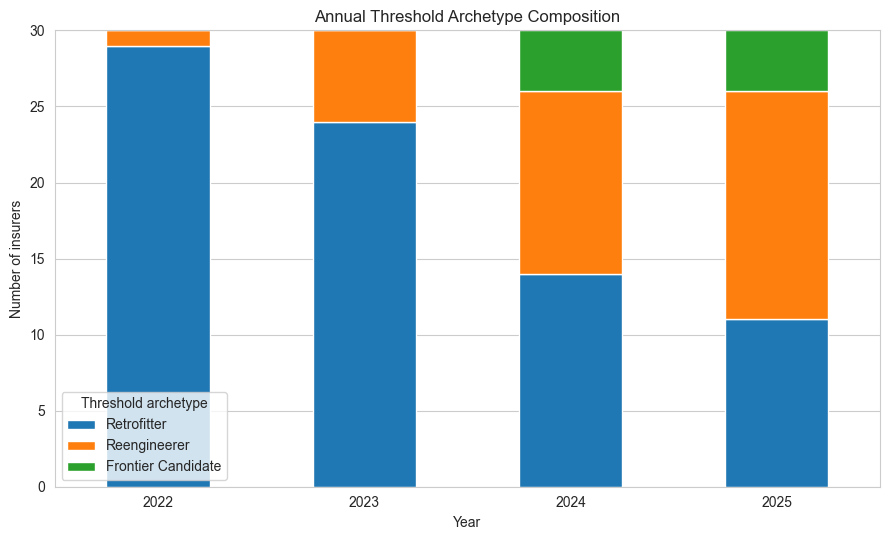

In [73]:
# Plot the annual composition under the fixed threshold rule.
threshold_annual_counts = (
    threshold_annual_summary
    .pivot(
        index="Year",
        columns="Threshold archetype",
        values="Number of insurers",
    )
    .reindex(columns=threshold_order, fill_value=0)
)

threshold_annual_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5.5),
)

plt.xlabel("Year")
plt.ylabel("Number of insurers")
plt.title("Annual Threshold Archetype Composition")
plt.xticks(rotation=0)
plt.legend(title="Threshold archetype")
plt.tight_layout()
plt.show()

## 16.2 Threshold-Based Changes from 2022 to 2025

The fixed rule produces comparable annual classifications. A threshold transition is recorded whenever an insurer's archetype differs from its classification in the previous year.

These changes are descriptive threshold-crossing points. They identify movement in the measured AI-adoption scores but do not establish that the change caused a financial outcome.


In [74]:
# Reshape the annual threshold assignments to one path per insurer.
threshold_company_paths = (
    cluster_panel
    .pivot(
        index="Company",
        columns="Year",
        values="Threshold archetype",
    )
    .reset_index()
)


# Identify year-to-year threshold changes within each insurer.
cluster_panel["Previous threshold archetype"] = (
    cluster_panel
    .groupby("Company")["Threshold archetype"]
    .shift(1)
)

threshold_changes = cluster_panel[
    cluster_panel["Previous threshold archetype"].notna()
    & (
        cluster_panel["Previous threshold archetype"]
        != cluster_panel["Threshold archetype"]
    )
][
    [
        "Company",
        "Year",
        "Previous threshold archetype",
        "Threshold archetype",
        "X1",
        "X2",
    ]
].reset_index(drop=True)


# Summarise all observed one-year threshold movements.
threshold_transition_matrix = pd.crosstab(
    cluster_panel["Previous threshold archetype"],
    cluster_panel["Threshold archetype"],
).reindex(
    index=threshold_order,
    columns=threshold_order,
    fill_value=0,
)

display(threshold_company_paths)
display(threshold_transition_matrix)
display(threshold_changes)

Year,Company,2022,2023,2024,2025
0,AXA,Retrofitter,Retrofitter,Frontier Candidate,Frontier Candidate
1,Achmea,Retrofitter,Retrofitter,Reengineerer,Reengineerer
2,Admiral Group,Retrofitter,Retrofitter,Retrofitter,Retrofitter
3,Ageas,Retrofitter,Retrofitter,Retrofitter,Retrofitter
4,Allianz,Retrofitter,Retrofitter,Reengineerer,Reengineerer
5,Alm. Brand Group,Retrofitter,Retrofitter,Retrofitter,Reengineerer
6,Aviva,Retrofitter,Retrofitter,Reengineerer,Reengineerer
7,Baloise (legacy series),Retrofitter,Retrofitter,Retrofitter,Reengineerer
8,Beazley,Retrofitter,Reengineerer,Frontier Candidate,Frontier Candidate
9,Coface,Retrofitter,Retrofitter,Retrofitter,Retrofitter


Threshold archetype,Retrofitter,Reengineerer,Frontier Candidate
Previous threshold archetype,,,
Retrofitter,49,16,2
Reengineerer,0,17,2
Frontier Candidate,0,0,4


,Company,Year,Previous threshold archetype,Threshold archetype,X1,X2
0,AXA,2024,Retrofitter,Frontier Candidate,0.500,0.5
1,Achmea,2024,Retrofitter,Reengineerer,0.500,0.2
2,Allianz,2024,Retrofitter,Reengineerer,0.500,0.2
3,Alm. Brand Group,2025,Retrofitter,Reengineerer,0.500,0.3
4,Aviva,2024,Retrofitter,Reengineerer,0.625,0.2
5,Baloise (legacy series),2025,Retrofitter,Reengineerer,0.500,0.4
6,Beazley,2023,Retrofitter,Reengineerer,0.625,0.4
7,Beazley,2024,Reengineerer,Frontier Candidate,0.750,0.5
8,Generali,2024,Retrofitter,Reengineerer,0.500,0.2
9,Groupama,2024,Retrofitter,Reengineerer,0.500,0.2


## 16.3 Longitudinal K-Means Design

K-means is fitted to all 120 company-year observations using X1 and X2. This gives every insurer one empirical profile assignment in each year while keeping the cluster boundaries constant across 2022–2025.

The two features are standardised once across the full panel. A separate scaler is not fitted for each year, because year-specific standardisation would redefine the relative position of the same score over time. Similarly, four separate annual K-means models are not estimated because independently moving centres would make annual labels incomparable.

The pooled observations are not statistically independent because each insurer appears four times. The clustering is therefore descriptive and is used to summarise score patterns and transitions, not for statistical inference.


In [75]:
cluster_features = ["X1", "X2"]


# Fit one common scaler across every company-year observation.
longitudinal_scaler = StandardScaler()
cluster_scores = longitudinal_scaler.fit_transform(
    cluster_panel[cluster_features]
)


print(
    "Company-year observations:",
    len(cluster_panel),
)
print(
    "Companies:",
    cluster_panel["Company"].nunique(),
)
print(
    "Years:",
    sorted(
        cluster_panel["Year"].astype(int).unique().tolist()
    ),
)

Company-year observations: 120
Companies: 30
Years: [2022, 2023, 2024, 2025]


## 16.4 Elbow Method and Silhouette Diagnostics

Candidate solutions from $k=1$ to $k=7$ are assessed using inertia, while silhouette scores are calculated from $k=2$ onward.

- **Inertia** measures within-cluster dispersion. It always decreases as more clusters are added, so the elbow is judged from the rate of improvement rather than the lowest value.
- **Silhouette score** measures cohesion and separation on a scale from -1 to 1. Higher values indicate more clearly separated groups.

These measures are treated as diagnostics rather than as an automatic decision rule. The project requires broad, interpretable transformation profiles, so statistical separation must be balanced against parsimony and the conceptual three-profile framework.


In [76]:
cluster_selection_rows = []
k_values = range(1, 8)


for number_of_clusters in k_values:
    candidate_model = KMeans(
        n_clusters=number_of_clusters,
        n_init=50,
        random_state=RANDOM_STATE,
    )

    candidate_labels = candidate_model.fit_predict(
        cluster_scores
    )

    cluster_selection_rows.append({
        "Number of clusters": number_of_clusters,
        "Inertia": candidate_model.inertia_,
        "Silhouette score": (
            silhouette_score(
                cluster_scores,
                candidate_labels,
            )
            if number_of_clusters >= 2
            else np.nan
        ),
    })


cluster_selection_table = pd.DataFrame(
    cluster_selection_rows
)

display(cluster_selection_table.round(4))

,Number of clusters,Inertia,Silhouette score
0,1,240.0000,NaN
1,2,112.0599,0.4642
2,3,72.0931,0.4715
3,4,50.1776,0.4726
4,5,36.3663,0.5235
5,6,27.3005,0.5455
6,7,22.3293,0.5493


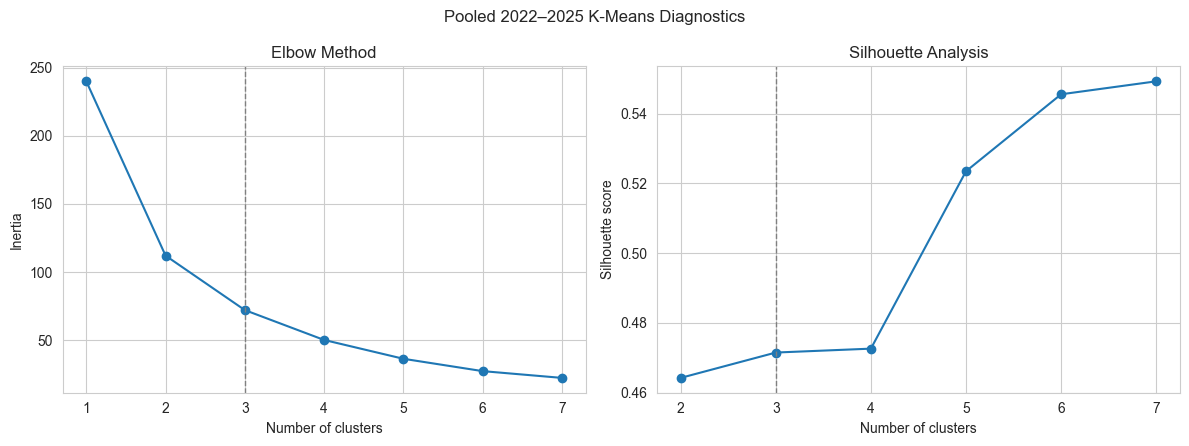

In [77]:
# Display the elbow and silhouette diagnostics side by side.
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    cluster_selection_table["Number of clusters"],
    cluster_selection_table["Inertia"],
    marker="o",
)
axes[0].axvline(
    3,
    color="grey",
    linestyle="--",
    linewidth=1,
)
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(list(k_values))


silhouette_plot_data = cluster_selection_table.dropna(
    subset=["Silhouette score"]
)

axes[1].plot(
    silhouette_plot_data["Number of clusters"],
    silhouette_plot_data["Silhouette score"],
    marker="o",
)
axes[1].axvline(
    3,
    color="grey",
    linestyle="--",
    linewidth=1,
)
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Analysis")
axes[1].set_xticks(
    silhouette_plot_data["Number of clusters"]
)

figure.suptitle(
    "Pooled 2022–2025 K-Means Diagnostics"
)
figure.tight_layout()
plt.show()

## 16.5 Pooled K-Means Cluster Profiles

One three-cluster model is fitted to the pooled, standardised X1 and X2 scores. Cluster numbers have no inherent meaning, so descriptive names are assigned only after the centres are converted back to the original 0–1 scales:

- the group with the lowest average across both axes is labelled Low adoption;
- the higher-scoring group with the smallest absolute difference between X1 and X2 is labelled Balanced/higher adoption;
- the remaining group is labelled according to whether its larger centre is on the business-model or operating-model axis.

These are sample-relative empirical profiles. They do not replace the fixed threshold archetypes.


In [78]:
# Fit one common three-cluster model to the pooled panel.
longitudinal_kmeans = KMeans(
    n_clusters=3,
    n_init=50,
    random_state=RANDOM_STATE,
)

cluster_panel["Cluster"] = (
    longitudinal_kmeans.fit_predict(
        cluster_scores
    )
)


# Convert the standardised centres back to the original score scales.
cluster_centres = pd.DataFrame(
    longitudinal_scaler.inverse_transform(
        longitudinal_kmeans.cluster_centers_
    ),
    columns=["Mean X1", "Mean X2"],
)

cluster_centres.index.name = "Cluster"
cluster_centres["Average adoption"] = (
    cluster_centres[["Mean X1", "Mean X2"]]
    .mean(axis=1)
)
cluster_centres["Axis difference"] = (
    cluster_centres["Mean X1"]
    - cluster_centres["Mean X2"]
)


# Identify the low and most balanced of the two higher clusters.
low_cluster = cluster_centres[
    "Average adoption"
].idxmin()

remaining_clusters = [
    cluster
    for cluster in cluster_centres.index
    if cluster != low_cluster
]

balanced_cluster = (
    cluster_centres
    .loc[remaining_clusters, "Axis difference"]
    .abs()
    .idxmin()
)


profile_map = {
    low_cluster: "Low adoption",
    balanced_cluster: "Balanced/higher adoption",
}

for cluster in remaining_clusters:
    if cluster == balanced_cluster:
        continue

    profile_map[cluster] = (
        "Business-model-led adoption"
        if cluster_centres.loc[
            cluster,
            "Axis difference",
        ] > 0
        else "Operating-model-led adoption"
    )


cluster_panel["Cluster profile"] = (
    cluster_panel["Cluster"].map(profile_map)
)

cluster_centres["Cluster profile"] = (
    cluster_centres.index.map(profile_map)
)

cluster_sizes = (
    cluster_panel["Cluster"]
    .value_counts()
)

cluster_centres["Company-year observations"] = (
    cluster_centres.index.map(cluster_sizes)
)

cluster_profile_summary = (
    cluster_centres
    .reset_index()
    [
        [
            "Cluster profile",
            "Mean X1",
            "Mean X2",
            "Average adoption",
            "Company-year observations",
        ]
    ]
    .sort_values("Average adoption")
    .reset_index(drop=True)
)

display(cluster_profile_summary.round(3))

,Cluster profile,Mean X1,Mean X2,Average adoption,Company-year observations
0,Low adoption,0.107,0.046,0.076,48
1,Business-model-led adoption,0.484,0.186,0.335,56
2,Balanced/higher adoption,0.555,0.487,0.521,16


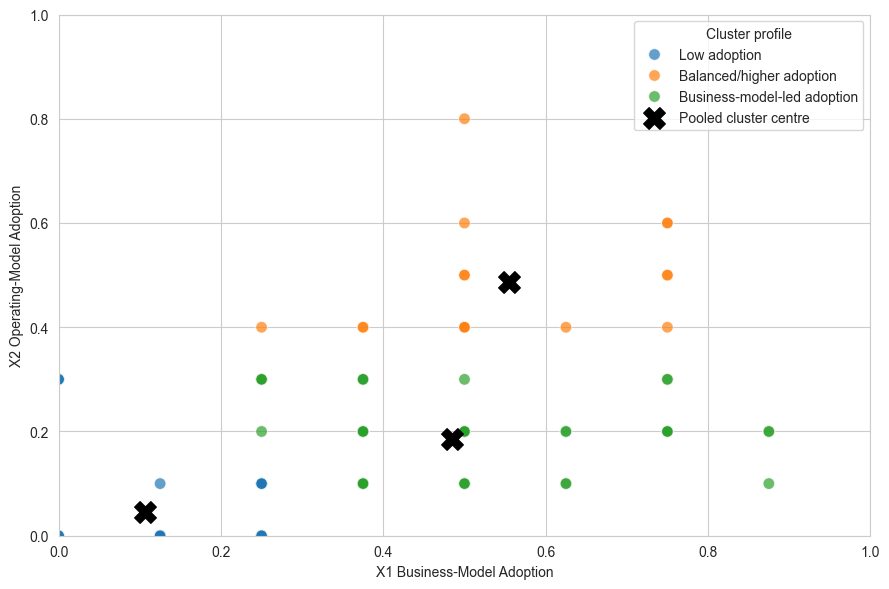

In [97]:
# Plot every company-year position and the fixed pooled centres.
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=cluster_panel,
    x="X1",
    y="X2",
    hue="Cluster profile",
    alpha=0.70,
    s=70,
)

plt.scatter(
    cluster_centres["Mean X1"],
    cluster_centres["Mean X2"],
    marker="X",
    s=240,
    color="black",
    label="Pooled cluster centre",
)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("X1 Business-Model Adoption")
plt.ylabel("X2 Operating-Model Adoption")

plt.legend(title="Cluster profile")
plt.tight_layout()

plt.savefig(
    "x1_x2_archetype_cluster_map.pdf",
    bbox_inches="tight"
)

plt.show()

## 16.6 Annual Cluster Membership and Transitions

Because the scaler and K-means centres are fixed across the full panel, the annual assignments are directly comparable. A cluster transition occurs when a company moves to a different empirical profile under these common boundaries.


In [80]:
cluster_profile_order = [
    "Low adoption",
    "Business-model-led adoption",
    "Balanced/higher adoption",
]


# Count the common empirical profiles in every year.
annual_cluster_counts = pd.crosstab(
    cluster_panel["Year"],
    cluster_panel["Cluster profile"],
).reindex(
    columns=cluster_profile_order,
    fill_value=0,
)


# Reshape the annual assignments to one empirical path per insurer.
company_cluster_paths = (
    cluster_panel
    .pivot(
        index="Company",
        columns="Year",
        values="Cluster profile",
    )
    .reset_index()
)

display(annual_cluster_counts)
display(company_cluster_paths)

Cluster profile,Low adoption,Business-model-led adoption,Balanced/higher adoption
Year,,,
2022,22,8,0
2023,16,10,4
2024,7,19,4
2025,3,19,8


Year,Company,2022,2023,2024,2025
0,AXA,Low adoption,Balanced/higher adoption,Balanced/higher adoption,Balanced/higher adoption
1,Achmea,Low adoption,Low adoption,Business-model-led adoption,Business-model-led adoption
2,Admiral Group,Low adoption,Low adoption,Business-model-led adoption,Business-model-led adoption
3,Ageas,Business-model-led adoption,Business-model-led adoption,Business-model-led adoption,Business-model-led adoption
4,Allianz,Low adoption,Low adoption,Business-model-led adoption,Balanced/higher adoption
5,Alm. Brand Group,Low adoption,Low adoption,Low adoption,Business-model-led adoption
6,Aviva,Low adoption,Low adoption,Business-model-led adoption,Business-model-led adoption
7,Baloise (legacy series),Low adoption,Low adoption,Business-model-led adoption,Balanced/higher adoption
8,Beazley,Low adoption,Balanced/higher adoption,Balanced/higher adoption,Balanced/higher adoption
9,Coface,Low adoption,Business-model-led adoption,Business-model-led adoption,Business-model-led adoption


In [81]:
# Identify movements under the common pooled cluster boundaries.
cluster_panel["Previous cluster profile"] = (
    cluster_panel
    .groupby("Company")["Cluster profile"]
    .shift(1)
)

cluster_transition_matrix = pd.crosstab(
    cluster_panel["Previous cluster profile"],
    cluster_panel["Cluster profile"],
).reindex(
    index=cluster_profile_order,
    columns=cluster_profile_order,
    fill_value=0,
)

cluster_changes = cluster_panel[
    cluster_panel["Previous cluster profile"].notna()
    & (
        cluster_panel["Previous cluster profile"]
        != cluster_panel["Cluster profile"]
    )
][
    [
        "Company",
        "Year",
        "Previous cluster profile",
        "Cluster profile",
        "X1",
        "X2",
    ]
].reset_index(drop=True)

display(cluster_transition_matrix)
display(cluster_changes)

Cluster profile,Low adoption,Business-model-led adoption,Balanced/higher adoption
Previous cluster profile,,,
Low adoption,26,17,2
Business-model-led adoption,0,31,6
Balanced/higher adoption,0,0,8


,Company,Year,Previous cluster profile,Cluster profile,X1,X2
0,AXA,2023,Low adoption,Balanced/higher adoption,0.375,0.4
1,Achmea,2024,Low adoption,Business-model-led adoption,0.500,0.2
2,Admiral Group,2024,Low adoption,Business-model-led adoption,0.375,0.1
3,Allianz,2024,Low adoption,Business-model-led adoption,0.500,0.2
4,Allianz,2025,Business-model-led adoption,Balanced/higher adoption,0.750,0.4
5,Alm. Brand Group,2025,Low adoption,Business-model-led adoption,0.500,0.3
6,Aviva,2024,Low adoption,Business-model-led adoption,0.625,0.2
7,Baloise (legacy series),2024,Low adoption,Business-model-led adoption,0.375,0.3
8,Baloise (legacy series),2025,Business-model-led adoption,Balanced/higher adoption,0.500,0.4
9,Beazley,2023,Low adoption,Balanced/higher adoption,0.625,0.4


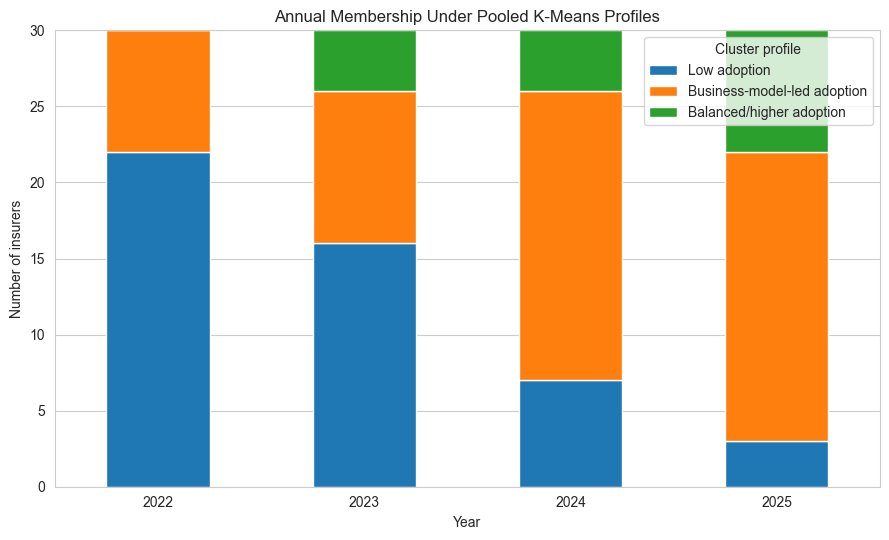

In [82]:
# Plot how membership changes under the fixed empirical profiles.
annual_cluster_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5.5),
)

plt.xlabel("Year")
plt.ylabel("Number of insurers")
plt.title("Annual Membership Under Pooled K-Means Profiles")
plt.xticks(rotation=0)
plt.legend(title="Cluster profile")
plt.tight_layout()
plt.show()

## 16.7 Comparison of Threshold and Clustering Results

The threshold and K-means classifications are compared only after both have been assigned
independently. The two approaches define groups differently:

- the threshold categories are fixed conceptual positions anchored at 0.50;
- the pooled K-means profiles are sample-relative groups defined by common empirical centres.

Exact label agreement is not a meaningful statistic here, because the label sets are not
equivalent: "Retrofitter" and "Low adoption" are not intended to describe the same thing. The
**Adjusted Rand Index** is used instead. It compares two partitions of the same observations by
asking, for every pair of company-years, whether the two methods place them together or apart. It
therefore requires no correspondence between label names, and is the appropriate way to report the
concordance the methodology asks for.

The index is 1.0 when the two methods produce identical groupings, and approximately 0 when the
agreement is no better than chance.


In [83]:
# Compare the number of annual changes detected by each method.
method_comparison_summary = pd.DataFrame(
    [
        {
            "Method": "Fixed threshold",
            "Assignment basis": "0.50 anchor on X1 and X2",
            "Company-year observations": len(cluster_panel),
            "Year-to-year changes": len(threshold_changes),
            "Companies with at least one change": (
                threshold_changes["Company"].nunique()
            ),
        },
        {
            "Method": "Pooled K-means",
            "Assignment basis": "Common pooled centres",
            "Company-year observations": len(cluster_panel),
            "Year-to-year changes": len(cluster_changes),
            "Companies with at least one change": (
                cluster_changes["Company"].nunique()
            ),
        },
    ]
)


# Cross-tabulate the independently assigned company-year classifications.
threshold_cluster_comparison = pd.crosstab(
    cluster_panel["Threshold archetype"],
    cluster_panel["Cluster profile"],
).reindex(
    index=threshold_order,
    columns=cluster_profile_order,
    fill_value=0,
)

display(method_comparison_summary)
display(threshold_cluster_comparison)

,Method,Assignment basis,Company-year observations,Year-to-year changes,Companies with at least one change
0,Fixed threshold,0.50 anchor on X1 and X2,120,20,18
1,Pooled K-means,Common pooled centres,120,25,21


Cluster profile,Low adoption,Business-model-led adoption,Balanced/higher adoption
Threshold archetype,,,
Retrofitter,48,27,3
Reengineerer,0,29,5
Frontier Candidate,0,0,8


### 16.7.1 Comparison Results

The two methods show the same broad progression but divide intermediate observations differently.

- All 48 Low-adoption observations are threshold Retrofitters.
- All 8 Frontier Candidate observations belong to the Balanced/higher adoption profile.
- The Business-model-led profile contains 27 threshold Retrofitters and 29 Reengineerers, showing that K-means detects a relative intermediate group even before some observations cross the fixed 0.50 boundary.
- The Balanced/higher profile contains 3 Retrofitters, 5 Reengineerers and 8 Frontier Candidate observations because empirical proximity to its centre does not require both axes to meet the threshold.

The threshold approach records 20 annual changes across 18 insurers, whereas pooled K-means records 25 changes across 21 insurers. K-means is more sensitive to relative movement within the low and intermediate score regions, while the threshold rule changes a label only when an axis crosses 0.50.


In [84]:
# Adjusted Rand Index between the two independently assigned classifications.
# The index is label-invariant, so it does not require the category names to correspond.
threshold_cluster_ari = adjusted_rand_score(
    cluster_panel["Threshold archetype"],
    cluster_panel["Cluster profile"],
)

print("CONCORDANCE BETWEEN THE TWO CLASSIFICATIONS")
print(
    "Company-year observations compared:",
    len(cluster_panel),
)
print(
    "Adjusted Rand Index:",
    round(threshold_cluster_ari, 3),
)


# The same comparison restricted to the 2025 cross-section, where each insurer
# contributes exactly one observation.
concordance_2025 = cluster_panel[
    cluster_panel["Year"] == cluster_panel["Year"].max()
]

threshold_cluster_ari_2025 = adjusted_rand_score(
    concordance_2025["Threshold archetype"],
    concordance_2025["Cluster profile"],
)

print(
    "\nAdjusted Rand Index, 2025 cross-section only:",
    round(threshold_cluster_ari_2025, 3),
)
print(
    "Insurers compared:",
    concordance_2025["Company"].nunique(),
)

CONCORDANCE BETWEEN THE TWO CLASSIFICATIONS
Company-year observations compared: 120
Adjusted Rand Index: 0.293

Adjusted Rand Index, 2025 cross-section only: 0.205
Insurers compared: 30


## 16.8 Financial Profiles of the 2025 Pooled K-Means Groups

This subsection describes the financial characteristics of the empirical cluster memberships observed in 2025. Only the 2025 cross-section is used, so each insurer appears once and repeated company-year observations do not enter the summary.

The table reports medians because the cluster sizes are unequal and several financial measures are skewed. These are unadjusted descriptive comparisons. They do not test whether the groups differ statistically and do not establish that AI adoption caused the observed financial outcomes.


In [85]:
# Select one 2025 financial observation for every insurer.
financial_profile_variables = {
    "CombinedRatio": "Median combined ratio",
    "ClaimsRatio": "Median claims ratio",
    "ExpenseRatio": "Median expense ratio",
    "OperatingMargin": "Median operating margin",
    "GWPGrowth": "Median GWP growth",
    "GWP per Employee EUR (million)": (
        "Median GWP per employee (EUR million)"
    ),
}


financial_profiles_2025 = (
    cluster_panel.loc[
        cluster_panel["Year"] == 2025,
        ["Company", "Cluster profile"],
    ]
    .merge(
        df.loc[
            df["Year"] == 2025,
            ["Company"] + list(financial_profile_variables),
        ],
        on="Company",
        how="left",
        validate="one_to_one",
    )
)


# Calculate group sizes and medians on the original financial scales.
financial_profile_summary_2025 = (
    financial_profiles_2025
    .groupby("Cluster profile", observed=True)
    .agg(
        Insurers=("Company", "nunique"),
        **{
            display_name: (variable, "median")
            for variable, display_name
            in financial_profile_variables.items()
        },
    )
    .reindex(cluster_profile_order)
    .reset_index()
)


display(financial_profile_summary_2025.round(3))


,Cluster profile,Insurers,Median combined ratio,Median claims ratio,Median expense ratio,Median operating margin,Median GWP growth,Median GWP per employee (EUR million)
0,Low adoption,3,0.911,0.669,0.248,0.094,0.069,0.500
1,Business-model-led adoption,19,0.892,0.627,0.278,0.106,0.059,0.740
2,Balanced/higher adoption,8,0.904,0.642,0.277,0.101,0.038,0.749


# 17. Archetype-Conditioned Financial Trajectories

This section estimates adjusted combined-ratio paths for the fixed threshold archetypes defined in Section 16.

The trajectory model uses the previous-year threshold archetype, because AI adoption is lagged behind the financial outcome:

$$COR_t = PriorArchetype_{t-1} + COR_{t-1} + \log(GWP_{t-1}) + Year_t$$

The resulting paths are adjusted scenario means, not forecasts or causal effects. Confidence intervals may be wide because the panel contains only three lagged outcome years.

Some archetype-year combinations have no observed company-years. Predictions for those combinations are model-based scenarios and are explicitly marked by an observed count of zero.


In [86]:
trajectory_model_data = lagged[
    [
        "Company",
        "Year",
        "CombinedRatio",
        "CombinedRatio_lag1",
        "log_GWP_lag1",
        "X1_lag1",
        "X2_lag1",
    ]
].dropna().copy()

trajectory_model_data["PriorArchetype"] = [
    threshold_archetype(x1, x2)
    for x1, x2 in zip(
        trajectory_model_data["X1_lag1"],
        trajectory_model_data["X2_lag1"],
    )
]

trajectory_formula = (
    "CombinedRatio ~ C(PriorArchetype, Treatment(reference='Retrofitter')) "
    "+ CombinedRatio_lag1 + log_GWP_lag1 + C(Year)"
)

trajectory_model = smf.ols(
    trajectory_formula,
    data=trajectory_model_data,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": trajectory_model_data["Company"]},
)

trajectory_counts = (
    trajectory_model_data
    .groupby(["PriorArchetype", "Year"])
    .size()
    .rename("Observed carrier-years")
    .reset_index()
)

trajectory_counts

,PriorArchetype,Year,Observed carrier-years
0,Frontier Candidate,2025,4
1,Reengineerer,2023,1
2,Reengineerer,2024,6
3,Reengineerer,2025,12
4,Retrofitter,2023,29
5,Retrofitter,2024,24
6,Retrofitter,2025,14


In [87]:
trajectory_archetypes = [
    "Retrofitter",
    "Reengineerer",
    "Frontier Candidate",
]

prediction_grid = pd.DataFrame(
    [
        {
            "PriorArchetype": archetype,
            "Year": year,
            "CombinedRatio_lag1": trajectory_model_data[
                "CombinedRatio_lag1"
            ].mean(),
            "log_GWP_lag1": trajectory_model_data[
                "log_GWP_lag1"
            ].mean(),
        }
        for archetype in trajectory_archetypes
        for year in sorted(trajectory_model_data["Year"].unique())
    ]
)

trajectory_prediction = trajectory_model.get_prediction(
    prediction_grid
).summary_frame(alpha=0.05)

trajectory_predictions = pd.concat(
    [
        prediction_grid[["PriorArchetype", "Year"]].reset_index(drop=True),
        trajectory_prediction[
            ["mean", "mean_ci_lower", "mean_ci_upper"]
        ].reset_index(drop=True),
    ],
    axis=1,
).merge(
    trajectory_counts,
    on=["PriorArchetype", "Year"],
    how="left",
)

trajectory_predictions["Observed carrier-years"] = trajectory_predictions["Observed carrier-years"].fillna(0).astype(int)
trajectory_predictions.round(4)

,PriorArchetype,Year,mean,mean_ci_lower,mean_ci_upper,Observed carrier-years
0,Retrofitter,2023,0.9003,0.8863,0.9144,29
1,Retrofitter,2024,0.8931,0.8817,0.9046,24
2,Retrofitter,2025,0.8863,0.8750,0.8976,14
3,Reengineerer,2023,0.9021,0.8837,0.9205,1
4,Reengineerer,2024,0.8949,0.8797,0.9101,6
5,Reengineerer,2025,0.8881,0.8781,0.8980,12
6,Frontier Candidate,2023,0.9010,0.8803,0.9218,0
7,Frontier Candidate,2024,0.8938,0.8707,0.9169,0
8,Frontier Candidate,2025,0.8870,0.8721,0.9019,4


## 17.1 Adjusted Combined-Ratio Scenarios

The chart reports adjusted predicted combined ratios for the three prior-year threshold
archetypes. The shaded areas are 95% confidence intervals.

These are associational scenario paths from the panel model, not firm-level forecasts or
causal effects. Some archetype-year combinations have few or no observed carrier-years, so
their confidence intervals should be interpreted cautiously.


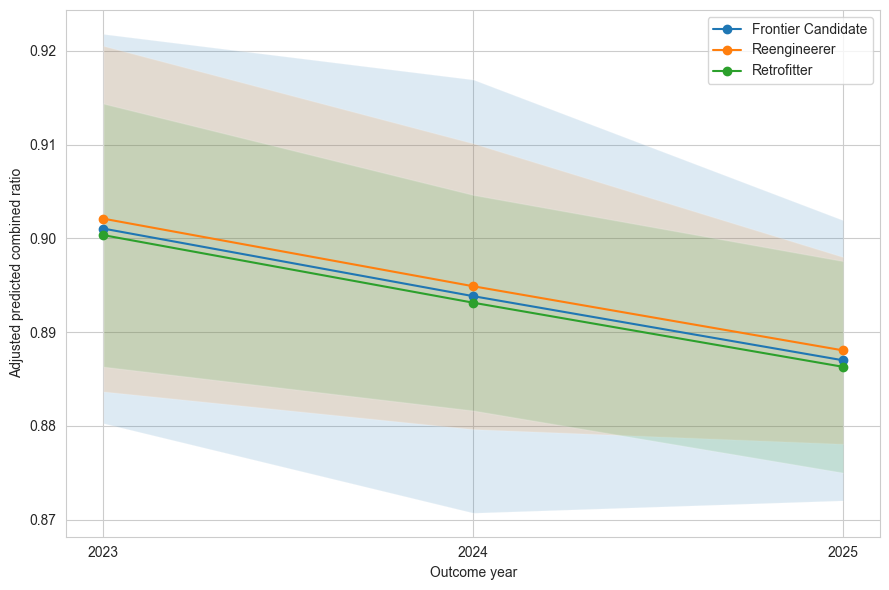

In [98]:
plt.figure(figsize=(9, 6))

for archetype, group_values in trajectory_predictions.groupby(
    "PriorArchetype"
):
    group_values = group_values.sort_values("Year")

    plt.plot(
        group_values["Year"],
        group_values["mean"],
        marker="o",
        label=archetype,
    )

    plt.fill_between(
        group_values["Year"],
        group_values["mean_ci_lower"],
        group_values["mean_ci_upper"],
        alpha=0.15,
    )

plt.xlabel("Outcome year")
plt.ylabel("Adjusted predicted combined ratio")

plt.xticks(sorted(trajectory_model_data["Year"].unique()))
plt.legend()
plt.tight_layout()

plt.savefig(
    "archetype_combined_ratio_trajectories.pdf",
    bbox_inches="tight"
)

plt.show()

## 18 Reproducibility Summary

The following output collects the main numerical results generated earlier in the notebook. It is retained as a computational check rather than as an additional interpretation section.


In [89]:
print("=" * 88)
print("FINALISED METHODOLOGY-ALIGNED ANALYSIS SUMMARY")
print("=" * 88)

print("\nSAMPLE")
print(f"Full panel: {len(df)} carrier-years, {df['Company'].nunique()} carriers")
print(f"One-year-lagged panel: {len(lagged)} carrier-years")
print(f"Two-year-lagged panel: {len(lagged2)} carrier-years")

print("\nHEADLINE OLS: METHODOLOGY SPECIFICATION")
print(
    ols_results[ols_results["Specification"] == MAIN_SPECIFICATION][
        [
            "Outcome",
            "Predictor",
            "Coefficient",
            "95% CI lower",
            "95% CI upper",
            "BH adjusted p-value: all 24 tests",
            "Adjusted R-squared",
            "N",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nLEAVE-ONE-CARRIER-OUT INTERNAL VALIDATION")
print(
    logo_internal_validation[
        logo_internal_validation["Specification"]
        == MAIN_SPECIFICATION
    ][
        [
            "Outcome",
            "Model",
            "LOCO R-squared",
            "LOCO RMSE",
            "LOCO MAE",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nTHEORY-DRIVEN WEIGHTING SENSITIVITY")
print(weight_score_stability.round(3).to_string(index=False))
print("\nCoefficient ranges across weighting scenarios:")
print(weighting_direction_summary.round(4).to_string(index=False))

print("\nALTERNATIVE TWO-YEAR LAG")
print(
    two_year_lag_results[
        [
            "Outcome",
            "Predictor",
            "Coefficient",
            "BH adjusted p-value",
            "N",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nLONGITUDINAL K-MEANS")
print(
    "Pooled k=3 silhouette on standardised X1/X2:",
    round(
        silhouette_score(
            cluster_scores,
            cluster_panel["Cluster"],
        ),
        3,
    ),
)
print(cluster_profile_summary.round(3).to_string(index=False))
print("\nAnnual pooled-cluster membership:")
print(annual_cluster_counts.to_string())

print("\nTRAJECTORY OUTPUT")
print(
    trajectory_predictions[
        [
            "PriorArchetype",
            "Year",
            "mean",
            "mean_ci_lower",
            "mean_ci_upper",
            "Observed carrier-years",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nINTERPRETATION RULE")
print(
    "The models estimate associations, not causal effects. "
    "Internal-validation results assess stability rather than firm-level forecasting."
)

FINALISED METHODOLOGY-ALIGNED ANALYSIS SUMMARY

SAMPLE
Full panel: 120 carrier-years, 30 carriers
One-year-lagged panel: 90 carrier-years
Two-year-lagged panel: 60 carrier-years

HEADLINE OLS: METHODOLOGY SPECIFICATION
             Outcome Predictor  Coefficient  95% CI lower  95% CI upper  BH adjusted p-value: all 24 tests  Adjusted R-squared  N
      Combined ratio        X1       0.0306        0.0147        0.0465                             0.0038              0.8196 90
      Combined ratio        X2      -0.0064       -0.0288        0.0160                             0.8577              0.8196 90
        Claims ratio        X1       0.0083       -0.0151        0.0317                             0.8227              0.8983 90
        Claims ratio        X2      -0.0031       -0.0302        0.0239                             0.8626              0.8983 90
       Expense ratio        X1       0.0090       -0.0010        0.0190                             0.4893              0.9822 90
 

# Appendix A. Supplementary 2025 Peer-Relative K-Means Profiles

This appendix provides an optional cross-sectional view of where insurers sit relative to their 2025 peers. It is separate from the primary Section 16 analysis, which uses fixed thresholds and one pooled K-means model to examine comparable movement across 2022–2025.

## A.1 Cross-Sectional Diagnostics

The scaler and candidate K-means models are fitted to the 30 final-year observations only. Inertia and silhouette scores are examined for $k=2$ to $k=7$. As in the pooled analysis, three profiles are retained for interpretability rather than claimed as the uniquely optimal statistical solution.


In [90]:
# Preparing one final-year observation for each insurer.
final_year = int(cluster_panel["Year"].max())

cross_section_panel = (
    cluster_panel[cluster_panel["Year"] == final_year]
    .copy()
    .reset_index(drop=True)
)

cross_section_scaler = StandardScaler()
cross_section_scores = cross_section_scaler.fit_transform(
    cross_section_panel[cluster_features]
)


# Evaluating candidate cross-sectional partitions independently of Section 16.
cross_section_diagnostic_rows = []

for number_of_clusters in range(2, 8):
    candidate_model = KMeans(
        n_clusters=number_of_clusters,
        n_init=50,
        random_state=RANDOM_STATE,
    )
    candidate_labels = candidate_model.fit_predict(
        cross_section_scores
    )
    cross_section_diagnostic_rows.append({
        "Number of clusters": number_of_clusters,
        "Inertia": candidate_model.inertia_,
        "Silhouette score": silhouette_score(
            cross_section_scores,
            candidate_labels,
        ),
    })

cross_section_diagnostics = pd.DataFrame(
    cross_section_diagnostic_rows
)

display(cross_section_diagnostics.round(4))


,Number of clusters,Inertia,Silhouette score
0,2,30.1879,0.4508
1,3,18.2944,0.4915
2,4,12.7385,0.4268
3,5,9.5884,0.4512
4,6,6.7212,0.4576
5,7,4.4646,0.5156


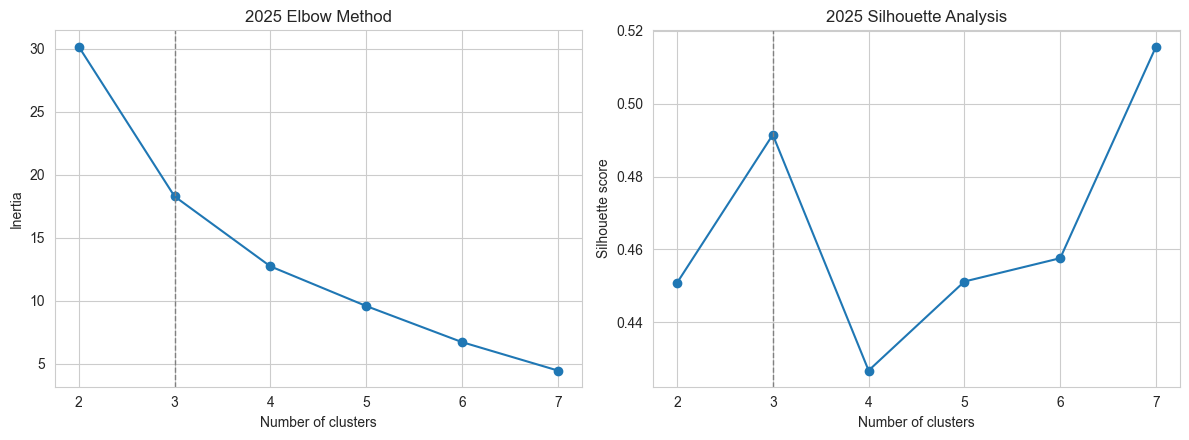

In [91]:
# Plotting the 2025 diagnostics without treating either measure as automatic.
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    cross_section_diagnostics["Number of clusters"],
    cross_section_diagnostics["Inertia"],
    marker="o",
)
axes[0].axvline(3, color="grey", linestyle="--", linewidth=1)
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")
axes[0].set_title("2025 Elbow Method")

axes[1].plot(
    cross_section_diagnostics["Number of clusters"],
    cross_section_diagnostics["Silhouette score"],
    marker="o",
)
axes[1].axvline(3, color="grey", linestyle="--", linewidth=1)
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("2025 Silhouette Analysis")

figure.tight_layout()
plt.show()


The 2025 silhouette score is approximately 0.492 for $k=3$ and is slightly higher for a more detailed seven-cluster solution. Three groups are therefore retained as a concise peer-profile summary, not because the diagnostic uniquely selects $k=3$.

## A.2 Three Peer-Relative Profiles

The three final-year clusters are named from their centres on the original X1 and X2 scales. The lowest-average group is labelled Lower adoption, the most balanced of the remaining groups is labelled Balanced/higher adoption, and the other group is labelled according to its dominant axis.


In [92]:
# Fitting the interpretable three-profile 2025 model.
cross_section_kmeans = KMeans(
    n_clusters=3,
    n_init=50,
    random_state=RANDOM_STATE,
)

cross_section_panel["Cross-sectional cluster"] = (
    cross_section_kmeans.fit_predict(cross_section_scores)
)

cross_section_centres = pd.DataFrame(
    cross_section_scaler.inverse_transform(
        cross_section_kmeans.cluster_centers_
    ),
    columns=["Mean X1", "Mean X2"],
)

cross_section_centres.index.name = "Cluster"
cross_section_centres["Average adoption"] = (
    cross_section_centres[["Mean X1", "Mean X2"]].mean(axis=1)
)
cross_section_centres["Axis difference"] = (
    cross_section_centres["Mean X1"]
    - cross_section_centres["Mean X2"]
)

lower_cluster = cross_section_centres["Average adoption"].idxmin()
remaining_clusters = [
    cluster
    for cluster in cross_section_centres.index
    if cluster != lower_cluster
]
balanced_cross_section_cluster = (
    cross_section_centres
    .loc[remaining_clusters, "Axis difference"]
    .abs()
    .idxmin()
)

cross_section_profile_map = {
    lower_cluster: "Lower adoption (2025 peer-relative)",
    balanced_cross_section_cluster: (
        "Balanced/higher adoption (2025 peer-relative)"
    ),
}

for cluster in remaining_clusters:
    if cluster == balanced_cross_section_cluster:
        continue
    cross_section_profile_map[cluster] = (
        "Business-model-led adoption (2025 peer-relative)"
        if cross_section_centres.loc[cluster, "Axis difference"] > 0
        else "Operating-model-led adoption (2025 peer-relative)"
    )

cross_section_panel["Peer-relative profile"] = (
    cross_section_panel["Cross-sectional cluster"]
    .map(cross_section_profile_map)
)
cross_section_centres["Peer-relative profile"] = (
    cross_section_centres.index.map(cross_section_profile_map)
)
cross_section_centres["Insurers"] = (
    cross_section_centres.index.map(
        cross_section_panel["Cross-sectional cluster"].value_counts()
    )
)

cross_section_profile_summary = (
    cross_section_centres
    .reset_index()
    [[
        "Peer-relative profile",
        "Mean X1",
        "Mean X2",
        "Insurers",
    ]]
    .sort_values("Mean X1")
    .reset_index(drop=True)
)

display(cross_section_profile_summary.round(3))

display(
    cross_section_panel[
        [
            "Company",
            "X1",
            "X2",
            "Peer-relative profile",
        ]
    ]
    .sort_values(["Peer-relative profile", "X1"], ascending=[True, False])
    .reset_index(drop=True)
)


,Peer-relative profile,Mean X1,Mean X2,Insurers
0,Lower adoption (2025 peer-relative),0.382,0.176,17
1,Balanced/higher adoption (2025 peer-relative),0.583,0.533,6
2,Business-model-led adoption (2025 peer-relative),0.786,0.257,7


,Company,X1,X2,Peer-relative profile
0,Beazley,0.750,0.5,Balanced/higher adoption (2025 peer-relative)
1,Vienna Insurance Group (VIG),0.750,0.6,Balanced/higher adoption (2025 peer-relative)
2,AXA,0.500,0.5,Balanced/higher adoption (2025 peer-relative)
3,Baloise (legacy series),0.500,0.4,Balanced/higher adoption (2025 peer-relative)
4,Groupama,0.500,0.4,Balanced/higher adoption (2025 peer-relative)
5,MAPFRE,0.500,0.8,Balanced/higher adoption (2025 peer-relative)
6,Unipol / Unipol Assicurazioni,0.875,0.2,Business-model-led adoption (2025 peer-relative)
7,Zurich Insurance Group,0.875,0.2,Business-model-led adoption (2025 peer-relative)
8,Allianz,0.750,0.4,Business-model-led adoption (2025 peer-relative)
9,Aviva,0.750,0.3,Business-model-led adoption (2025 peer-relative)


## A.3 Relationship With the Fixed 2025 Categories
The cross-tabulation retains the original descriptive labels and does not impose a one-to-one category mapping.


In [93]:
# Comparing partitions without forcing peer-relative labels into archetypes.
cross_section_ari = adjusted_rand_score(
    cross_section_panel["Threshold archetype"],
    cross_section_panel["Peer-relative profile"],
)

cross_section_comparison = pd.crosstab(
    cross_section_panel["Threshold archetype"],
    cross_section_panel["Peer-relative profile"],
).reindex(index=threshold_order, fill_value=0)

print(f"Supplementary 2025 Adjusted Rand Index: {cross_section_ari:.3f}")
display(cross_section_comparison)


Supplementary 2025 Adjusted Rand Index: 0.313


Peer-relative profile,Balanced/higher adoption (2025 peer-relative),Business-model-led adoption (2025 peer-relative),Lower adoption (2025 peer-relative)
Threshold archetype,,,
Retrofitter,0,0,11
Reengineerer,2,7,6
Frontier Candidate,4,0,0


The appendix profiles are useful only for a current peer-relative snapshot. They do not replace the fixed threshold categories used for longitudinal monitoring or the pooled K-means profiles used to summarise common 2022–2025 transitions.


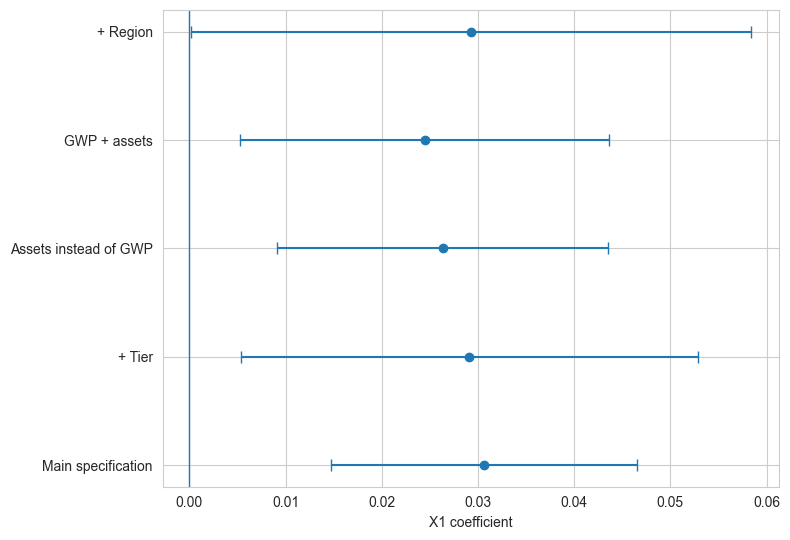

In [99]:
robustness_labels = [
    f"3. {MAIN_SPECIFICATION}",
    "4. Main specification + tier",
    "5. Assets instead of GWP",
    "6. GWP and assets",
    "7. Main specification + region",
]

display_labels = [
    "Main specification",
    "+ Tier",
    "Assets instead of GWP",
    "GWP + assets",
    "+ Region",
]

rows = []

for model_label, display_label in zip(
    robustness_labels,
    display_labels
):
    model = combined_ratio_models[model_label]
    ci = model.conf_int().loc["X1_lag1"]

    rows.append({
        "Specification": display_label,
        "Coefficient": model.params["X1_lag1"],
        "CI lower": ci.iloc[0],
        "CI upper": ci.iloc[1],
    })

robustness_plot = pd.DataFrame(rows)

plt.figure(figsize=(8, 5.5))

y = np.arange(len(robustness_plot))

plt.errorbar(
    robustness_plot["Coefficient"],
    y,
    xerr=[
        robustness_plot["Coefficient"] - robustness_plot["CI lower"],
        robustness_plot["CI upper"] - robustness_plot["Coefficient"],
    ],
    fmt="o",
    capsize=4,
)

plt.axvline(0, linewidth=1)
plt.yticks(y, robustness_plot["Specification"])
plt.xlabel("X1 coefficient")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "x1_combined_ratio_robustness.pdf",
    bbox_inches="tight"
)

plt.show()